In [327]:
# Data import
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from sklearn.impute import KNNImputer

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

df = pd.read_excel("pcos_data_base_ml.xlsx")


## PCOS Data Cleaning and Validation Pipeline – Step List

### Core Pipeline Steps

1. **Data overview** – shape, data types, missing values, group distribution
2. **Identification of indexable columns** – subject_id, group, wiek, BMI
3. **Parameters existing only in one group** – PCOS vs Control_no_PCOS
4. **Classification of parameters into categories** – hormonal, metabolic, lipid, inflammatory, etc.
5. **Parameters with very few data** – N < 10 (exclude) and 10 ≤ N < 30 (separate analysis)
6. **Formatting error detection** – commas instead of dots, text null values
7. **Parameters without variance** – constant or near-constant (unique values ≤ 2)
8. **Unit identification** – mg/dL vs mmol/L (glucose), ng/mL vs μg/L (D-dimer), nmol/L vs pmol/L (SHBG)
9. **Column consolidation** – merging parameters across groups and methods
10. **Outlier detection (biological plausibility)** – values outside physiological ranges (e.g., CRP > 100, SHBG > 300)
11. **Removal of highly incomplete data** – columns with >30% missing values
12. **Missing data imputation strategy** – mean/median, KNN, MICE, or deletion
13. **Normalization / scaling before clustering** – Z-score, Min-Max, or log transformation (for skewed distributions)

## Parameter Quality Dictionary – Initialization

A dedicated dictionary `parameter_quality` was created to track metadata and quality flags for every column in the dataset. This dictionary serves as the single source of truth for all data cleaning and preprocessing decisions.

### Dictionary Structure

Each column is represented by a nested dictionary containing the following keys:

| Key | Type | Description |
|-----|------|-------------|
| **Basic info** | | |
| `original_name` | str | Original column name from the dataset |
| `data_type` | str | Pandas data type (e.g., float64, int64, str) |
| `n_total` | int | Total number of rows in the dataset |
| `n_nonnull` | int | Number of non‑null values in the column |
| `n_unique` | int | Number of unique values in the column |
| **Descriptive statistics** | | |
| `mean` | float or None | Arithmetic mean (for numeric columns) |
| `median` | float or None | Median (for numeric columns) |
| `min` | float or None | Minimum value (for numeric columns) |
| `max` | float or None | Maximum value (for numeric columns) |
| `q1` | float or None | First quartile (25th percentile) |
| `q3` | float or None | Third quartile (75th percentile) |
| **Quality flags** | | |
| `useful` | bool | Overall flag indicating whether the column should be retained for analysis |
| `exclude_reason` | list | List of reasons why the column was excluded (if applicable) |
| **Specific issues** | | |
| `only_in_group` | str or None | `'PCOS'`, `'Control_no_PCOS'`, or `None` if present in both groups |
| `too_few_data` | bool | `True` if number of non‑null values is below threshold (e.g., < 30) |
| `no_variance` | bool | `True` if column has ≤ 2 unique values (constant or near‑constant) |
| `formatting_errors` | bool | `True` if column contains commas, text nulls, or other formatting issues |
| `unit_unknown` | bool | `True` if the measurement unit could not be determined |
| `outliers_detected` | bool | `True` if biologically implausible values were found |
| **Unit tracking** | | |
| `detected_unit` | str or None | Detected unit of measurement (e.g., `'mg/dL'`, `'nmol/L'`, `'ng/mL'`) |
| `original_unit` | str or None | Unit specified in metadata (if available) |
| **Merge tracking** | | |
| `merged_from` | list | List of source columns that were consolidated into this column |
| `merged_into` | str or None | Name of the consolidated column this column was merged into |
| **Decision metadata** | | |
| `category` | str or None | Clinical category assigned to the parameter (e.g., `'Thyroid'`, `'Lipid'`) |
| `recommended_action` | str or None | Suggested action: `'exclude'`, `'fix'`, `'merge'`, `'keep'` |
| `notes` | list | Free‑text notes documenting decisions and observations |

### Descriptive Statistics

For numeric columns (`float64`, `int64`), the following descriptive statistics are calculated at initialization and stored in the dictionary:

- **`mean`** – arithmetic mean (average)
- **`median`** – median value (50th percentile)
- **`min`** – minimum observed value
- **`max`** – maximum observed value
- **`q1`** – first quartile (25th percentile)
- **`q3`** – third quartile (75th percentile)

These statistics are used throughout the pipeline for:
- Unit detection (comparing median values to reference ranges)
- Outlier detection (identifying values outside physiological ranges)
- Data quality assessment (evaluating variance and distribution)
- Post‑consolidation validation (checking merged distributions)

In [249]:
# Initialize quality dictionary for all columns
parameter_quality = {}

for col in df.columns:
    # Calculate statistics for numeric columns
    if df[col].dtype in ['float64', 'int64']:
        series = df[col].dropna()
        mean_val = series.mean() if len(series) > 0 else None
        median_val = series.median() if len(series) > 0 else None
        min_val = series.min() if len(series) > 0 else None
        max_val = series.max() if len(series) > 0 else None
        q1 = series.quantile(0.25) if len(series) > 0 else None
        q3 = series.quantile(0.75) if len(series) > 0 else None
    else:
        mean_val = None
        median_val = None
        min_val = None
        max_val = None
        q1 = None
        q3 = None
    
    parameter_quality[col] = {
        # Basic info
        'original_name': col,
        'data_type': str(df[col].dtype),
        'n_total': len(df),
        'n_nonnull': df[col].notna().sum(),
        'n_unique': df[col].nunique(),
        
        # Descriptive statistics (for numeric columns)
        'mean': mean_val,
        'median': median_val,
        'min': min_val,
        'max': max_val,
        'q1': q1,
        'q3': q3,
        
        # Flags (start as True/empty – will be updated when problems found)
        'useful': True,           # Overall flag for further analysis
        'exclude_reason': [],     # List of reasons to exclude
        
        # Specific issues
        'only_in_group': None,    # 'PCOS', 'Control_no_PCOS', or None
        'too_few_data': False,    # N < 30
        'no_variance': False,     # ≤2 unique values
        'formatting_errors': False, # commas, text nulls
        'unit_unknown': False,    # cannot determine units
        'outliers_detected': False, # extreme values
        
        # Unit detection
        'detected_unit': None,    # e.g., 'mg/dL', 'nmol/L', 'ng/mL', etc.
        'original_unit': None,    # If specified in metadata
        
        # Merging tracking
        'merged_from': [],        # List of source columns that were merged into this column
        'merged_into': None,      # Name of the consolidated column this was merged into
        
        # Metadata for decision making
        'category': None,         # e.g., 'TSH', 'FT4'
        'recommended_action': None, # 'exclude', 'fix', 'merge', 'keep'
        'notes': []               # Free text notes
    }

print(f"Initialized quality dictionary for {len(parameter_quality)} parameters")

Initialized quality dictionary for 224 parameters


In [250]:
print("=" * 80)
print("PARAMETER QUALITY DICTIONARY – FIRST 10 COLUMNS")
print("=" * 80)

# Get first 10 columns
first_10_cols = list(df.columns)[:10]

# Create DataFrame for display
display_data = []
for col in first_10_cols:
    if col in parameter_quality:
        info = parameter_quality[col]
        display_data.append({
            'Parameter': col,
            'original_name': info.get('original_name'),
            'data_type': info.get('data_type'),
            'n_total': info.get('n_total'),
            'n_nonnull': info.get('n_nonnull'),
            'n_unique': info.get('n_unique'),
            'mean': info.get('mean'),
            'median': info.get('median'),
            'min': info.get('min'),
            'max': info.get('max'),
            'q1': info.get('q1'),
            'q3': info.get('q3'),
            'useful': info.get('useful'),
            'exclude_reason': info.get('exclude_reason'),
            'only_in_group': info.get('only_in_group'),
            'too_few_data': info.get('too_few_data'),
            'no_variance': info.get('no_variance'),
            'formatting_errors': info.get('formatting_errors'),
            'unit_unknown': info.get('unit_unknown'),
            'outliers_detected': info.get('outliers_detected'),
            'detected_unit': info.get('detected_unit'),
            'original_unit': info.get('original_unit'),
            'merged_from': info.get('merged_from'),
            'merged_into': info.get('merged_into'),
            'category': info.get('category'),
            'recommended_action': info.get('recommended_action'),
            'notes': info.get('notes')
        })

display_df = pd.DataFrame(display_data)

# Display all columns (no truncation)
pd.set_option('display.max_colwidth', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

display(display_df)

# Save to CSV for full inspection
display_df.to_csv('parameter_quality_first_10.csv', index=False)
print("\n✅ Saved to 'parameter_quality_first_10.csv'")

PARAMETER QUALITY DICTIONARY – FIRST 10 COLUMNS


,Parameter,original_name,data_type,n_total,n_nonnull,n_unique,mean,median,min,max,q1,q3,useful,exclude_reason,only_in_group,too_few_data,no_variance,formatting_errors,unit_unknown,outliers_detected,detected_unit,original_unit,merged_from,merged_into,category,recommended_action,notes
0,Wiek,Wiek,int64,1331,1331,21,21.100676,21.000,16.00,41.000000,19.0000,23.000,True,[],None,False,False,False,False,False,None,None,[],None,None,None,[]
1,group,group,str,1331,1331,2,NaN,NaN,NaN,NaN,NaN,NaN,True,[],None,False,False,False,False,False,None,None,[],None,None,None,[]
2,subject_id,subject_id,str,1331,1331,1331,NaN,NaN,NaN,NaN,NaN,NaN,True,[],None,False,False,False,False,False,None,None,[],None,None,None,[]
3,17 - OH progesteron (L79) ...,17 - OH progesteron (L79) ...,float64,1331,965,248,1.182603,0.990,0.20,8.783333,0.6900,1.430,True,[],None,False,False,False,False,False,None,None,[],None,None,None,[]
4,17 OH progesteron (L79),17 OH progesteron (L79),float64,1331,212,172,2.069249,2.125,0.14,5.240000,1.3575,2.745,True,[],None,False,False,False,False,False,None,None,[],None,None,None,[]
5,ALAT (ALT),ALAT (ALT),float64,1331,263,161,19.642395,16.400,5.00,127.000000,12.9500,22.000,True,[],None,False,False,False,False,False,None,None,[],None,None,None,[]
6,AMH (hormon anty-Mullerows...,AMH (hormon anty-Mullerows...,float64,1331,976,585,6.406019,5.715,0.01,27.800000,3.7800,8.405,True,[],None,False,False,False,False,False,None,None,[],None,None,None,[]
7,AMH ng/ml,AMH ng/ml,float64,1331,45,44,3.479333,3.040,1.12,9.430000,1.8900,4.760,True,[],None,False,False,False,False,False,None,None,[],None,None,None,[]
8,AMH-anty Mullerian Hormon ...,AMH-anty Mullerian Hormon ...,float64,1331,147,139,6.959456,6.150,1.34,19.850000,4.3600,8.515,True,[],None,False,False,False,False,False,None,None,[],None,None,None,[]
9,APTT Czas kaolinowo-kefali...,APTT Czas kaolinowo-kefali...,float64,1331,5,5,34.540000,34.100,30.20,39.400000,33.8000,35.200,True,[],None,False,False,False,False,False,None,None,[],None,None,None,[]



✅ Saved to 'parameter_quality_first_10.csv'


## Step 1: Data Overview

In this step, a comprehensive initial assessment of the dataset was performed. The key characteristics examined included:

- **Dataset dimensions** – number of rows and columns
- **Data types** – distribution of numeric, categorical, and datetime columns
- **Group distribution** – proportion of PCOS patients versus healthy controls
- **Missing data** – total missing values, columns affected, and identification of highly incomplete columns (>80% missing)

This overview provided the foundation for all subsequent preprocessing decisions, including which columns to retain, how to handle missing data, and which parameters required special attention due to group‑specific availability.

In [251]:
# STEP 1: Data overview – shape, data types, missing values, group distribution

print("=" * 80)
print("STEP 1: DATA OVERVIEW – COMPREHENSIVE")
print("=" * 80)

# ============================================================================
# 1. BASIC INFORMATION
# ============================================================================
print("\n" + "=" * 80)
print("1. BASIC INFORMATION")
print("=" * 80)

print(f"Shape: {df.shape}")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# ============================================================================
# 2. DATA TYPES
# ============================================================================
print("\n" + "=" * 80)
print("2. DATA TYPES")
print("=" * 80)

# Simplified dtype counts without frequency-specific types
dtype_counts = {}
for dtype in df.dtypes.unique():
    # Convert datetime64[us] to just datetime64 for counting
    dtype_name = str(dtype)
    if 'datetime64' in dtype_name:
        dtype_name = 'datetime64'
    dtype_counts[dtype_name] = dtype_counts.get(dtype_name, 0) + (df.dtypes == dtype).sum()

print("Data type counts:")
for dtype, count in sorted(dtype_counts.items(), key=lambda x: -x[1]):
    print(f"  {dtype}: {count}")

# Detailed breakdown
print("\nData type breakdown by category:")
for dtype, count in dtype_counts.items():
    # Get columns of this type (handle datetime64 specially)
    if 'datetime64' in dtype:
        cols = df.select_dtypes(include=['datetime64']).columns.tolist()
    else:
        cols = df.select_dtypes(include=[dtype]).columns.tolist()
    print(f"  {dtype}: {count} columns – {', '.join(cols[:5])}{'...' if len(cols) > 5 else ''}")

# ============================================================================
# 3. GROUP DISTRIBUTION
# ============================================================================
print("\n" + "=" * 80)
print("3. GROUP DISTRIBUTION")
print("=" * 80)

if 'group' in df.columns:
    group_counts = df['group'].value_counts()
    print(group_counts)
    print(f"\nPercentage:")
    for group, count in group_counts.items():
        print(f"  {group}: {count/len(df)*100:.1f}%")
else:
    print("No 'group' column found")

# ============================================================================
# 4. FIRST ROWS (PREVIEW)
# ============================================================================
print("\n" + "=" * 80)
print("4. FIRST 5 ROWS")
print("=" * 80)

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 30)
display(HTML(df.head().to_html()))

# ============================================================================
# 5. MISSING VALUES – COMPREHENSIVE
# ============================================================================
print("\n" + "=" * 80)
print("5. MISSING VALUES OVERVIEW")
print("=" * 80)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_summary = missing_summary[missing_summary['Missing'] > 0].sort_values('Missing', ascending=False)

print(f"Total missing values: {df.isnull().sum().sum():,}")
print(f"Columns with missing values: {len(missing_summary)}")
print(f"Columns with 0 missing values: {len(df.columns) - len(missing_summary)}")

# Columns with >80% missing (highly incomplete)
high_missing = missing_summary[missing_summary['Percent'] > 80]
print(f"\nColumns with >80% missing values: {len(high_missing)}")
if len(high_missing) > 0:
    for col, row in high_missing.head(20).iterrows():
        print(f"  • {col}: {row['Missing']} missing ({row['Percent']:.1f}%)")

# Top 20 columns with most missing values
print(f"\nTop 20 columns with most missing values:")
display(missing_summary.head(20))


STEP 1: DATA OVERVIEW – COMPREHENSIVE

1. BASIC INFORMATION
Shape: (1331, 224)
Rows: 1331
Columns: 224
Memory usage: 3.34 MB

2. DATA TYPES
Data type counts:
  float64: 191
  str: 30
  datetime64: 2
  int64: 1

Data type breakdown by category:
  int64: 1 columns – Wiek
  str: 30 columns – group, subject_id, Anty - HCV (L_ANTHCV), Grypa A, B, RSV, SARS-CoV2 antygen - badanie jakościowe (COV2_G), Grypa A, B, RSV, SARS-CoV2 antygen - badanie jakościowe (GRYA)...
  float64: 191 columns – 17 - OH progesteron (L79) (17-OHPG), 17 OH progesteron (L79), ALAT (ALT), AMH (hormon anty-Mullerowski) (AMH_CP), AMH ng/ml...
  datetime64: 2 columns – Przyjęcie na oddział zlecający, Wypis z oddziału zlecającego

3. GROUP DISTRIBUTION
group
PCOS               1286
Control_no_PCOS      45
Name: count, dtype: int64

Percentage:
  PCOS: 96.6%
  Control_no_PCOS: 3.4%

4. FIRST 5 ROWS


,Wiek,group,subject_id,17 - OH progesteron (L79) (17-OHPG),17 OH progesteron (L79),ALAT (ALT),AMH (hormon anty-Mullerowski) (AMH_CP),AMH ng/ml,AMH-anty Mullerian Hormon (AMH),APTT Czas kaolinowo-kefalinowy (APTTCZ),ASO - ilościowo (ASOIL),ASPAT (AST),Androstendion (ANDRO),Androstendion (I31),Androstendion (I31) (ANDRO),Anty - HCV (L_ANTHCV),Anty-TG (O18),Anty-TG (p/c przeciw tyreoglobulinie) (ATG),Anty-TPO (ATA_TPO),BMI kg/m2,Białko C-reaktywne (CRP),Bilirubina całkowita (TBIL),CEA (CEA),Ca125 (CA125),Ca19.9 (CA199),Cholesterol całkowity (TCHOL),D-dimery (DDIMER),DHEAS (DHEA),DHEAS ug/dl,Dobowy rytm tolerancji glukozy (L_G1030),Dobowy rytm tolerancji glukozy (L_G1200),Dobowy rytm tolerancji glukozy (L_G1500),Dobowy rytm tolerancji glukozy (L_G1800),Dobowy rytm tolerancji glukozy (L_G2100),Dobowy rytm tolerancji glukozy (L_G2400),Dobowy rytm tolerancji glukozy (L_G330),Dobowy rytm tolerancji glukozy (L_G700),Dokument (NAZWA),Estradiol (ESTRA),Estradiol (L_ESTRA),FSH (FSH),FSH 0' 30' 60' (L_FSH0),FSH 0' 30' 60' (L_FSH30),FSH 0' 30' 60' (L_FSH60),FSH IU/l,FT3 (FT3),FT4 (FT4),Ferrytyna (FERR),Ferrytyna (L05),Fibrynogen (L_FIB),Fosforany nieorganiczne (FOSFOR),GH (hormon wzrostu) (L_GH),Gamma Glutamylotranspeptydaza (GGTP),Glukoza (L_GLU),"Grypa A, B, RSV, SARS-CoV2 antygen - badanie jakościowe (COV2_G)","Grypa A, B, RSV, SARS-CoV2 antygen - badanie jakościowe (GRYA)","Grypa A, B, RSV, SARS-CoV2 antygen - badanie jakościowe (GRYB)","Grypa A, B, RSV, SARS-CoV2 antygen - badanie jakościowe (GRYRSV)",HBSAG (L_HBSAG),HBsAg (L_HBSAG),HDL cholesterol (HDL),HbsAg (HBSAG),Hemoglobina glikowana (HBA1C_1),Hemoglobina glikowana (HBA1C_2),Hemoglobina glikowana (L53.IFC),Hemoglobina glikowana (L55),IGF-1 (insulinopodobny czynnik wzrostu 1) (IGF1_L),Insulina (INSUL),Insulina po 75g glukozy (3pkt.) (INSUL_0),Insulina po 75g glukozy (3pkt.) (INSUL_1),Insulina po 75g glukozy (3pkt.) (INSUL_2),"Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 0m)","Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 120m)","Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 30m)","Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 60m)","Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_0)","Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_1)","Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_2)","Jonogram (Sód, potas, chlorki) (L_CI)","Jonogram (Sód, potas, chlorki) (L_K)","Jonogram (Sód, potas, chlorki) (L_NA)",Kortyzol godz. 08:00 (KOR),Kortyzol godz. 23:00 (KOR23),Kortyzol na czczo (KORCZ),Kortyzol po Dexamethasonie (KORD),Kortyzol po Dexamethasonie [1mg] (KORD),Kortyzol po Dexamethasonie [2mg] (KOR2DXM),Kortyzol po Dexamethasonie [4mg] (KOR4DXM),Kreatynina (KREAT),Krzywa cukrowa - 2 punktowa (GLU120),Krzywa cukrowa - 2 punktowa (L_GLU_0),LDL cholesterol (LDL),LH (LH),LH 0' 30' 60' (LH0),LH 0' 30' 60' (L_LH30),LH 0' 30' 60' (L_LH60),LH IU/l,Limf 10^3/uL,MDRD GFR (MDRD),MPV fL,Mocz - badanie ogólne (MBARWA),Mocz - badanie ogólne (MBIALK),Mocz - badanie ogólne (MBILI),Mocz - badanie ogólne (MCIEZA),Mocz - badanie ogólne (MCUKIE),Mocz - badanie ogólne (MERY),Mocz - badanie ogólne (MKETON),Mocz - badanie ogólne (MLEU),Mocz - badanie ogólne (MNIT),Mocz - badanie ogólne (MOSAD),Mocz - badanie ogólne (MPH),Mocz - badanie ogólne (MPRZEJ),Mocz - badanie ogólne (MUROBI),Morfologia CBC (HCT),Morfologia CBC (HGB),Morfologia CBC (MCH),Morfologia CBC (MCHC),Morfologia CBC (MCV),Morfologia CBC (MPV),Morfologia CBC (NRBC_B),Morfologia CBC (NRBC_P),Morfologia CBC (PCT),Morfologia CBC (PDW),Morfologia CBC (PLCR),Morfologia CBC (PLT),Morfologia CBC (RBC),Morfologia CBC (RDW),Morfologia CBC (RDWSD),Morfologia CBC (WBC),"Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (BASO)","Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (BASOB)","Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (EOS#)","Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (EOS


5. MISSING VALUES OVERVIEW
Total missing values: 230,021
Columns with missing values: 221
Columns with 0 missing values: 3

Columns with >80% missing values: 162
  • TK jamy brzusznej i miednicy z kontrastem (nan): 1331.0 missing (100.0%)
  • PLR: 1331.0 missing (100.0%)
  • TK jamy brzusznej z kontrastem (nan): 1331.0 missing (100.0%)
  • USG piersi (nan): 1331.0 missing (100.0%)
  • USG tarczycy i przytarczyc (nan): 1331.0 missing (100.0%)
  • Wymaz z kanału szyjki macicy - posiew mykologiczny (Wynik badania): 1331.0 missing (100.0%)
  • Wymaz z kanału szyjki macicy - posiew tlenowy (Wynik badania): 1331.0 missing (100.0%)
  • USG brzucha i przestrzeni zaotrzewnowej (nan): 1331.0 missing (100.0%)
  • RTG kości nadgarstka, PA, bok (nan): 1331.0 missing (100.0%)
  • USG wątroby – elastografia (nan): 1331.0 missing (100.0%)
  • USG nadnerczy (nan): 1331.0 missing (100.0%)
  • NLR: 1331.0 missing (100.0%)
  • Mocz - badanie ogólne (MOSAD): 1331.0 missing (100.0%)
  • SHBG (SHGB): 1330.0

,Missing,Percent
TK jamy brzusznej i miednicy z kontrastem (nan),1331,100.000000
PLR,1331,100.000000
TK jamy brzusznej z kontrastem (nan),1331,100.000000
USG piersi (nan),1331,100.000000
USG tarczycy i przytarczyc (nan),1331,100.000000
Wymaz z kanału szyjki macicy - posiew mykologiczny (Wynik badania),1331,100.000000
Wymaz z kanału szyjki macicy - posiew tlenowy (Wynik badania),1331,100.000000
USG brzucha i przestrzeni zaotrzewnowej (nan),1331,100.000000
"RTG kości nadgarstka, PA, bok (nan)",1331,100.000000
USG wątroby – elastografia (nan),1331,100.000000


In [252]:
# STEP 2: IDENTIFY INDEXABLE COLUMNS

print("\n" + "=" * 80)
print("STEP 2: IDENTIFY INDEXABLE COLUMNS")
print("=" * 80)

indexable_cols = ['group', 'subject_id', 'Nr KG']

found_indexable = []
for col in indexable_cols:
    if col in df.columns:
        found_indexable.append(col)
        print(f"✓ {col}")
    else:
        print(f"✗ {col} (not found)")

# Mark them in parameter_quality
for col in found_indexable:
    if col in parameter_quality:
        parameter_quality[col]['category'] = 'Index'
        parameter_quality[col]['recommended_action'] = 'keep_as_index'
        parameter_quality[col]['notes'].append('Used as identifier/grouping variable')

print(f"\n✅ Identified {len(found_indexable)} indexable columns")


STEP 2: IDENTIFY INDEXABLE COLUMNS
✓ group
✓ subject_id
✓ Nr KG

✅ Identified 3 indexable columns


In [253]:
# STEP 3: PARAMETERS EXISTING ONLY IN ONE GROUP

print("\n" + "=" * 80)
print("STEP 3: PARAMETERS EXISTING ONLY IN ONE GROUP")
print("=" * 80)

pcos_df = df[df['group'] == 'PCOS']
control_df = df[df['group'] == 'Control_no_PCOS']

for col in df.columns:    
    pcos_count = pcos_df[col].notna().sum()
    control_count = control_df[col].notna().sum()
    
    if pcos_count > 0 and control_count == 0:
        parameter_quality[col]['only_in_group'] = 'PCOS'
        parameter_quality[col]['notes'].append(f'Has {pcos_count} values, but 0 in Control')
        print(f"⚠️ {col}: ONLY IN PCOS ({pcos_count} values)")
        
    elif control_count > 0 and pcos_count == 0:
        parameter_quality[col]['only_in_group'] = 'Control_no_PCOS'
        parameter_quality[col]['notes'].append(f'Has {control_count} values, but 0 in PCOS')
        print(f"⚠️ {col}: ONLY IN Control_no_PCOS ({control_count} values)")


STEP 3: PARAMETERS EXISTING ONLY IN ONE GROUP
⚠️ 17 - OH progesteron (L79) (17-OHPG): ONLY IN PCOS (965 values)
⚠️ 17 OH progesteron (L79): ONLY IN PCOS (212 values)
⚠️ ALAT (ALT): ONLY IN PCOS (263 values)
⚠️ AMH (hormon anty-Mullerowski) (AMH_CP): ONLY IN PCOS (976 values)
⚠️ AMH ng/ml: ONLY IN Control_no_PCOS (45 values)
⚠️ AMH-anty Mullerian Hormon (AMH): ONLY IN PCOS (147 values)
⚠️ APTT Czas kaolinowo-kefalinowy (APTTCZ): ONLY IN PCOS (5 values)
⚠️ ASO - ilościowo (ASOIL): ONLY IN PCOS (1 values)
⚠️ ASPAT (AST): ONLY IN PCOS (263 values)
⚠️ Androstendion (ANDRO): ONLY IN PCOS (682 values)
⚠️ Androstendion (I31): ONLY IN PCOS (189 values)
⚠️ Androstendion (I31) (ANDRO): ONLY IN PCOS (255 values)
⚠️ Anty - HCV (L_ANTHCV): ONLY IN PCOS (1 values)
⚠️ Anty-TG (O18): ONLY IN PCOS (21 values)
⚠️ Anty-TG (p/c przeciw tyreoglobulinie) (ATG): ONLY IN PCOS (254 values)
⚠️ Anty-TPO (ATA_TPO): ONLY IN PCOS (1043 values)
⚠️ BMI kg/m2: ONLY IN Control_no_PCOS (45 values)
⚠️ Białko C-reaktywne 

In [254]:
# STEP 4: CLASSIFY PARAMETERS INTO CLINICAL CATEGORIES

import re

print("=" * 80)
print("STEP 4: CLASSIFY PARAMETERS INTO CLINICAL CATEGORIES")
print("=" * 80)

# Define specific categories with keywords and patterns
category_mapping = {
    # Index / Demographics
    'Index': {
        'keywords': ['wiek', 'group', 'subject_id', 'nr kg', 'rok kg', 'dokument', 'przyjęcie', 'wypis', 'oddział'],
        'patterns': []
    },
    
    'Virology': {
        'keywords': ['grypa', 'covid', 'sars-cov', 'rsv', 'cov2'],
        'patterns': [r'grypa', r'covid', r'sars-cov', r'rsv', r'cov2']
    },
    'XRay': {
        'keywords': ['rtg', 'x-ray', 'radiograph'],
        'patterns': [r'rtg', r'x-ray']
    },
    'GGT': {
        'keywords': ['ggtp', 'gamma gt', 'gamma-glutamyl'],
        'patterns': [r'ggtp', r'gamma']
    },
    
    # Androgen / Hormonal
    'Testosterone_Total': {
        'keywords': ['testosteron', 'testosterone'],
        'patterns': [r'l_testos', r'\btest(-| )?free\b']
    },
    'Testosterone_Free': {
        'keywords': ['wolny testosteron', 'free testosterone', 'test-f', 'o41.w'],
        'patterns': [r'wolny testosteron', r'free testosterone', r'test-f', r'o41\.w']
    },
    'SHBG': {
        'keywords': ['shbg', 'sex hormone binding globulin'],
        'patterns': [r'shbg', r'l_shgb']
    },
    'DHEAS': {
        'keywords': ['dheas', 'dhea', 'dehydroepiandrosterone'],
        'patterns': [r'dheas', r'dhea']
    },
    'Androstenedione': {
        'keywords': ['androstendion', 'androstenedione'],
        'patterns': [r'\bandrosten(dion|dione)\b', r'\bandro\b']
    },
    'AMH': {
        'keywords': ['amh', 'anty-mullerian', 'anti-mullerian'],
        'patterns': [r'amh', r'anty-mullerian', r'anti-mullerian']
    },
    'LH': {
        'keywords': ['lh', 'luteinizing hormone'],
        'patterns': [r'lh', r'l_lh']
    },
    'FSH': {
        'keywords': ['fsh', 'follicle stimulating'],
        'patterns': [r'fsh', r'l_fsh']
    },
    'Estradiol': {
        'keywords': ['estradiol', 'e2', 'estra'],
        'patterns': [r'estradiol', r'estra', r'e2']
    },
    'Progesterone_17OHP': {
        'keywords': ['17-oh progesteron', '17 ohp', 'l79', 'synacthen', '17-ohp'],
        'patterns': [r'17-oh', r'17ohp', r'l79', r'synacthen']
    },
    'Prolactin': {
        'keywords': ['prl', 'prolactin', 'makroprl'],
        'patterns': [r'prl', r'prolactin', r'makroprl']
    },
    
    # Metabolic / Glucose
    'Glucose_Fasting': {
        'keywords': ['glu 0', 'glucose 0', 'glukoza', 'l_glu_0', 'glu 0\''],
        'patterns': [r'glu 0', r'glucose 0', r'l_glu_0', r'glu 0\'', r'glukoza']
    },
    'Glucose_OGTT': {
        'keywords': ['dobowy rytm tolerancji glukozy', 'krzywa cukrowa'],
        'patterns': [r'l_g[0-9]+', r'ogtt']
    },
    'Insulin_Fasting': {
        'keywords': ['insulina', 'insulin', 'insul', 'insulina uu/ml'],
        'patterns': [r'insulina', r'insulin', r'insul', r'insulina uu']
    },
    'Insulin_OGTT': {
        'keywords': ['insulina po', 'l97', 'insulin po 75g'],
        'patterns': [r'l97', r'insulina po', r'insulin po 75g']
    },
    'HOMA_IR': {
        'keywords': ['homa', 'homa-ir'],
        'patterns': [r'homa']
    },
    'QUICKI': {
        'keywords': ['quicki'],
        'patterns': [r'quicki']
    },
    'HbA1c': {
        'keywords': ['hemoglobina glikowana', 'hba1c', 'l53.ifc', 'glycated hemoglobin'],
        'patterns': [r'hba1c', r'hemoglobina glikowana', r'l53', r'glycated']
    },
    'TyG': {
        'keywords': ['tyg', 'triglyceride glucose'],
        'patterns': [r'tyg']
    },
    
    # Thyroid
    'TSH': {
        'keywords': ['tsh', 'thyrotropin'],
        'patterns': [r'tsh']
    },
    'FT3': {
        'keywords': ['ft3', 'free t3'],
        'patterns': [r'ft3']
    },
    'FT4': {
        'keywords': ['ft4', 'free t4'],
        'patterns': [r'ft4']
    },
    'Anti_TPO': {
        'keywords': ['anty-tpo', 'anti-tpo', 'ata_tpo'],
        'patterns': [r'anty-tpo', r'anti-tpo', r'tpo']
    },
    'Anti_TG': {
        'keywords': ['anty-tg', 'anti-tg', 'antytyreoglobulinowe', 'atg'],
        'patterns': [r'anty-tg', r'anti-tg', r'antytyreoglobulinowe', r'\batg\b']
    },
    'TRAb': {
        'keywords': ['trab', 'tsh receptor antibody', 'przeciw receptorowi tsh'],
        'patterns': [r'trab', r'tsh receptor']
    },
    
    # Lipid
    'Cholesterol_Total': {
        'keywords': ['cholesterol całkowity', 'total cholesterol', 'tchol'],
        'patterns': [r'cholesterol całkowity', r'total cholesterol', r'tchol']
    },
    'HDL': {
        'keywords': ['hdl', 'hdl cholesterol'],
        'patterns': [r'hdl']
    },
    'LDL': {
        'keywords': ['ldl', 'ldl cholesterol'],
        'patterns': [r'ldl']
    },
    'Triglycerides': {
        'keywords': ['triglicerydy', 'triglycerides'],
        'patterns': [r'triglicerydy', r'triglycerides', r'\btg\b']
    },

    # Growth Factors
    'IGF1': {
        'keywords': ['igf-1', 'igf1', 'insulin like growth factor'],
        'patterns': [r'igf-?1', r'insulin like growth']
    },
    'GH': {
        'keywords': ['gh', 'growth hormone', 'hormon wzrostu'],
        'patterns': [r'\bgh\b', r'growth hormone', r'hormon wzrostu']  # \bgh\b zamiast gh
    },
    
    # Inflammatory / Hematology
    'CRP': {
        'keywords': ['crp', 'białko c-reaktywne', 'c-reactive protein'],
        'patterns': [r'crp', r'białko c-reaktywne']
    },
    'NLR': {
        'keywords': ['nlr', 'neutrophil lymphocyte ratio'],
        'patterns': [r'nlr']
    },
    'PLR': {
        'keywords': ['plr', 'platelet lymphocyte ratio'],
        'patterns': [r'plr']
    },
    'Neutrophils': {
        'keywords': ['neut', 'neutrofile', 'neutrophil'],
        'patterns': [r'neu', r'neut', r'neutrofil']
    },
    'Lymphocytes': {
        'keywords': ['limf', 'lim#', 'lymph', 'lymphocyte'],
        'patterns': [r'\blim#\b', r'\blim\b', r'limf', r'lymph']
    },
    'Monocytes': {
        'keywords': ['mono', 'monocyte'],
        'patterns': [r'mon', r'monocyte']
    },
    'Eosinophils': {
        'keywords': ['eos', 'eosinophil'],
        'patterns': [r'eos']
    },
    'Basophils': {
        'keywords': ['baso', 'basophil'],
        'patterns': [r'baso']
    },
    'Platelets': {
        'keywords': ['plt', 'płytki', 'thrombocyte', 'plt 10^3'],
        'patterns': [r'plt', r'płytki']
    },
    'WBC': {
        'keywords': ['wbc', 'leukocyty', 'white blood cell'],
        'patterns': [r'wbc', r'leukocyty']
    },
    'RBC': {
        'keywords': ['rbc', 'erythrocyte', 'krwinki czerwone'],
        'patterns': [r'rbc']
    },
    'Hemoglobin': {
        'keywords': ['hgb', 'hemoglobina'],
        'patterns': [r'hgb', r'hemoglobina']
    },
    'Hematocrit': {
        'keywords': ['hct', 'hematokryt'],
        'patterns': [r'hct', r'hematokryt']
    },
    'MCV': {
        'keywords': ['mcv', 'mean corpuscular volume'],
        'patterns': [r'mcv']
    },
    'MCH': {
        'keywords': ['mch', 'mean corpuscular hemoglobin'],
        'patterns': [r'mch']
    },
    'MCHC': {
        'keywords': ['mchc', 'mean corpuscular hemoglobin concentration'],
        'patterns': [r'mchc']
    },
    'RDW': {
        'keywords': ['rdw', 'red cell distribution width'],
        'patterns': [r'rdw']
    },
    'MPV': {
        'keywords': ['mpv', 'mean platelet volume', 'pct', 'pdw', 'plcr'],
        'patterns': [r'\bmpv\b', r'\bpct\b', r'\bpdw\b', r'\bplcr\b']
    },
    'Ferritin': {
        'keywords': ['ferrytyna', 'ferritin', 'ferr', 'l05'],
        'patterns': [r'ferrytyna', r'ferritin', r'ferr', r'l05']
    },
    'Iron': {
        'keywords': ['żelazo', 'iron', 'fe'],
        'patterns': [r'żelazo', r'iron', r'fe\b']
    },
    
    # Coagulation
    'D_Dimer': {
        'keywords': ['d-dimer', 'ddimer'],
        'patterns': [r'd-dimer', r'ddimer']
    },
    'Fibrinogen': {
        'keywords': ['fibrynogen', 'fibrinogen', 'l_fib'],
        'patterns': [r'fibrynogen', r'fibrinogen', r'l_fib']
    },
    'PT_APTT': {
        'keywords': ['protrombina', 'pt', 'aptt', 'inr'],
        'patterns': [r'protrombina', r'\bpt\b', r'aptt', r'inr']
    },
    
    # Liver
    'ALT': {
        'keywords': ['alt', 'alat'],
        'patterns': [r'alt', r'alat']
    },
    'AST': {
        'keywords': ['ast', 'aspat'],
        'patterns': [r'ast', r'aspat']
    },
    'GGTP': {
        'keywords': ['ggtp', 'gamma gt'],
        'patterns': [r'ggtp', r'gamma']
    },
    'Bilirubin': {
        'keywords': ['bilirubina', 'bilirubin'],
        'patterns': [r'bilirubina', r'bilirubin']
    },
    
    # Kidney
    'Creatinine': {
        'keywords': ['kreatynina', 'creatinine', 'kreat'],
        'patterns': [r'kreatynina', r'creatinine', r'kreat']
    },
    'GFR_MDRD': {
        'keywords': ['mdrd', 'gfr'],
        'patterns': [r'mdrd', r'gfr']
    },
    'Electrolytes': {
        'keywords': ['sód', 'potas', 'chlorki', 'jonogram'],
        'patterns': [r'sód', r'potas', r'chlorki', r'jonogram', r'\bl_na\b', r'\bl_k\b', r'\bl_cl\b']
    },
    
    
    # Adrenal / Cortisol
    'Cortisol_8AM': {
        'keywords': ['kortyzol 8', 'kortyzol godz 08', 'kor 8', 'kortyzol 8.00', 'korcz'],
        'patterns': [r'kortyzol.*8', r'kor.*8', r'kor08', r'korcz']
    },
    'Cortisol_11PM': {
        'keywords': ['kortyzol 23', 'kortyzol godz 23', 'kor23'],
        'patterns': [r'kortyzol.*23', r'kor23']
    },
    'Cortisol_Dexamethasone': {
        'keywords': ['kord', 'dexamethasone', 'deksametazon', 'kortyzol po dex'],
        'patterns': [r'kord', r'dexamethasone', r'deksametazon', r'kortyzol po']
    },
    'ACTH_Stimulation': {
        'keywords': ['synacthen', 'l79', 'test z synacthenem'],
        'patterns': [r'synacthen', r'l79', r'test z synacthenem']
    },
    
    # Tumor Markers
    'CA125': {
        'keywords': ['ca125', 'ca 125'],
        'patterns': [r'ca125', r'ca 125']
    },
    'CA19_9': {
        'keywords': ['ca19.9', 'ca 19.9'],
        'patterns': [r'ca19\.9', r'ca 19\.9']
    },
    'CEA': {
        'keywords': ['cea'],
        'patterns': [r'cea']
    },
    'HE4_ROMA': {
        'keywords': ['he4', 'roma', 'test roma'],
        'patterns': [r'he4', r'roma']
    },
    
    # Immunology / Autoimmunity
    'Anti_HCV': {
        'keywords': ['anty-hcv', 'anti-hcv', 'l_anthcv'],
        'patterns': [r'anty-hcv', r'anti-hcv', r'anthcv']
    },
    'HBsAg': {
        'keywords': ['hbsag', 'hbs ag', 'hepatitis b'],
        'patterns': [r'hbsag', r'hbs']
    },
    'Anti_GAD': {
        'keywords': ['pcgad', 'anti-gad', 'przeciw gad'],
        'patterns': [r'pcgad', r'anti-gad', r'przeciw gad']
    },
    'ASO': {
        'keywords': ['aso', 'antistreptolysin'],
        'patterns': [r'aso']
    },
    
    # Urinalysis
    'Urinalysis': {
        'keywords': ['mocz', 'urine'],
        'patterns': [r'\bmocz\b', r'\burine\b', r'\bmb\w+\b', r'\bmcieza\b', r'\bmcukie\b', r'\bmosad\b', r'\bmph\b', r'\bmleu\b', r'\bmnit\b', r'\bmery\b', r'\bmketon\b', r'\bmbarwa\b', r'\bmbialk\b', r'\bmprzej\b', r'\bmurobi\b']
    },
    
    # Imaging
    'Ultrasound': {
        'keywords': ['usg', 'ultrasound', 'elastografia'],
        'patterns': [r'usg', r'ultrasound', r'elastografia']
    },
    'CT_Scan': {
        'keywords': ['tk jamy', 'ct scan', 'tomografia', 'tk'],
        'patterns': [r'tk jamy', r'tomografia', r'\btk\b']
    },
    'XRay': {
        'keywords': ['rtg', 'x-ray', 'radiograph'],
        'patterns': [r'rtg', r'x-ray']
    },
    
    # Microbiology
    'Microbiology': {
        'keywords': ['posiew', 'wymaz', 'culture', 'swab', 'dat-zak', 'uwagi'],
        'patterns': [r'posiew', r'wymaz', r'culture', r'swab', r'dat-zak', r'uwagi']
    },
    
    # Vitamins / Other
    'Vitamin_D': {
        'keywords': ['witamina d', 'vitamin d', '25-hydroksywitamina', 'witd'],
        'patterns': [r'witamina d', r'vitamin d', r'25-hydroksy', r'witd']
    },
    'Calcium': {
        'keywords': ['wapń', 'calcium', 'tcal', 'l_cazjs'],
        'patterns': [r'wapń', r'calcium', r'tcal', r'cazjs']
    },
    'Phosphate': {
        'keywords': ['fosforany', 'phosphate', 'fosfor'],
        'patterns': [r'fosforany', r'phosphate', r'fosfor']
    },
    'Beta_HCG': {
        'keywords': ['beta hcg', 'bhcg', 'l_hcg'],
        'patterns': [r'beta hcg', r'bhcg', r'l_hcg']
    },
    
    # COVID / Respiratory
    'COVID_Respiratory': {
        'keywords': ['covid', 'sars-cov', 'grypa', 'rsv', 'cov2'],
        'patterns': [r'covid', r'sars-cov', r'grypa', r'rsv', r'cov2']
    },
    
    'Immature_Granulocytes': {
        'keywords': ['ig_b', 'ig_p'],
        'patterns': [r'\big_b\b', r'\big_p\b']
    },
}

# Initialize category assignment
for col, info in parameter_quality.items():
    if col in ['group', 'subject_id', 'nr', 'Wiek', 'BMI kg/m2']:
        info['category'] = 'Index'
        continue
    
    info['category'] = None
    col_lower = col.lower()
    
    for category, mapping in category_mapping.items():
        # Check keywords
        matched = False
        for keyword in mapping['keywords']:
            if keyword.lower() in col_lower:
                info['category'] = category
                matched = True
                break
        
        # Check regex patterns if no keyword match
        if not matched and mapping['patterns']:
            for pattern in mapping['patterns']:
                if re.search(pattern, col_lower, re.IGNORECASE):
                    info['category'] = category
                    matched = True
                    break
        
        if matched:
            break

# Collect uncategorized columns
uncategorized = []
for col, info in parameter_quality.items():
    if info['category'] is None and col not in ['group', 'subject_id', 'nr', 'Wiek', 'BMI kg/m2']:
        uncategorized.append(col)
        info['category'] = 'UNCATEGORIZED'
        info['notes'].append('REVIEW MANUALLY - no category matched')

# Display results
print("\n" + "=" * 80)
print("CATEGORIZATION RESULTS")
print("=" * 80)

category_counts = {}
for info in parameter_quality.values():
    cat = info['category']
    if cat:
        category_counts[cat] = category_counts.get(cat, 0) + 1

print("\nCategory counts (including UNCATEGORIZED):")
for cat, count in sorted(category_counts.items(), key=lambda x: -x[1]):
    print(f"  {cat}: {count}")

# Display all columns with their categories
print("\n" + "=" * 80)
print("FULL CATEGORIZATION LIST")
print("=" * 80)

for i, (col, info) in enumerate(list(parameter_quality.items())):
    print(f"{i+1:3}. {col} -> {info['category']}")

# Display ONLY uncategorized columns (MUST REVIEW)
print("\n" + "=" * 80)
print(f"⚠️ UNCATEGORIZED COLUMNS TO REVIEW ({len(uncategorized)})")
print("=" * 80)

if uncategorized:
    for col in uncategorized:
        info = parameter_quality[col]
        print(f"  ❌ {col}")
        print(f"     N={info['n_nonnull']}, type={info['data_type']}")
        print(f"     Sample: {df[col].dropna().head(3).tolist()}")
        print()
else:
    print("✅ No uncategorized columns found!")

# Update parameter_quality with category info
print(f"\n✅ Updated parameter_quality with categories for {len([i for i in parameter_quality.values() if i['category']])} columns")
print(f"⚠️ {len(uncategorized)} columns need manual review")

STEP 4: CLASSIFY PARAMETERS INTO CLINICAL CATEGORIES

CATEGORIZATION RESULTS

Category counts (including UNCATEGORIZED):
  Insulin_Fasting: 13
  Urinalysis: 13
  Index: 9
  Glucose_OGTT: 9
  MPV: 9
  Prolactin: 8
  RBC: 6
  HE4_ROMA: 6
  Microbiology: 6
  Progesterone_17OHP: 5
  FSH: 5
  LH: 5
  RDW: 5
  PT_APTT: 4
  AST: 4
  Virology: 4
  HbA1c: 4
  Cortisol_Dexamethasone: 4
  MCH: 4
  TSH: 4
  Testosterone_Total: 4
  Ultrasound: 4
  AMH: 3
  Androstenedione: 3
  Anti_TG: 3
  Glucose_Fasting: 3
  HBsAg: 3
  Electrolytes: 3
  Cortisol_8AM: 3
  Lymphocytes: 3
  Platelets: 3
  WBC: 3
  Neutrophils: 3
  SHBG: 3
  CA125: 2
  DHEAS: 2
  Estradiol: 2
  Ferritin: 2
  Hematocrit: 2
  Hemoglobin: 2
  MCV: 2
  Basophils: 2
  Eosinophils: 2
  Immature_Granulocytes: 2
  Monocytes: 2
  Calcium: 2
  ALT: 1
  ASO: 1
  Anti_HCV: 1
  Anti_TPO: 1
  CRP: 1
  Bilirubin: 1
  CEA: 1
  CA19_9: 1
  Cholesterol_Total: 1
  D_Dimer: 1
  FT3: 1
  FT4: 1
  Fibrinogen: 1
  Phosphate: 1
  GH: 1
  GGT: 1
  HDL: 1
  C

In [255]:
print("=" * 80)
print("MANUAL CORRECTIONS TO PARAMETER CATEGORIES")
print("=" * 80)

# ============================================================================
# 1. IGF-1 → IGF1 (intead of Insulin_Fasting)
# ============================================================================
igf1_columns = [
    'IGF-1 (insulinopodobny czynnik wzrostu 1) (IGF1_L)'
]

for col in igf1_columns:
    if col in parameter_quality:
        old_category = parameter_quality[col]['category']
        parameter_quality[col]['category'] = 'IGF1'
        parameter_quality[col]['notes'].append(f'MANUAL CORRECTION: changed from {old_category} to IGF1')
        print(f"✓ {col}: {old_category} → IGF1")

# ============================================================================
# 2. TK jamy brzusznej → CT_Scan (instead of AST)
# ============================================================================
ct_columns = [
    'TK jamy brzusznej i miednicy z kontrastem (nan)',
    'TK jamy brzusznej z kontrastem (nan)'
]

for col in ct_columns:
    if col in parameter_quality:
        old_category = parameter_quality[col]['category']
        parameter_quality[col]['category'] = 'CT_Scan'
        parameter_quality[col]['notes'].append(f'MANUAL CORRECTION: changed from {old_category} to CT_Scan')
        print(f"✓ {col}: {old_category} → CT_Scan")

# ============================================================================
# 3. USG wątroby elastografia → Ultrasound (instead of AST)
# ============================================================================
usg_columns = [
    'USG wątroby – elastografia (nan)'
]

for col in usg_columns:
    if col in parameter_quality:
        old_category = parameter_quality[col]['category']
        parameter_quality[col]['category'] = 'Ultrasound'
        parameter_quality[col]['notes'].append(f'MANUAL CORRECTION: changed from {old_category} to Ultrasound')
        print(f"✓ {col}: {old_category} → Ultrasound")

# ============================================================================
# 4. TRAb → Thyroid_Autoantibodies (instead of TSH)
# ============================================================================
trab_columns = [
    'P/c przeciw receptorowi TSH (TRAb) (O15) (TRAB)',
    'P/c przeciw receptorowi TSH (TRAb) (TRAB_2)'
]

for col in trab_columns:
    if col in parameter_quality:
        old_category = parameter_quality[col]['category']
        parameter_quality[col]['category'] = 'Thyroid_Autoantibodies'
        parameter_quality[col]['notes'].append(f'MANUAL CORRECTION: changed from {old_category} to Thyroid_Autoantibodies')
        print(f"✓ {col}: {old_category} → Thyroid_Autoantibodies")

# ============================================================================
# 5. MCHC → MCHC (osobna kategoria, instead of MCH)
# ============================================================================
mchc_columns = [
    'Morfologia CBC (MCHC)',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCHC)'
]

for col in mchc_columns:
    if col in parameter_quality:
        old_category = parameter_quality[col]['category']
        parameter_quality[col]['category'] = 'MCHC'
        parameter_quality[col]['notes'].append(f'MANUAL CORRECTION: changed from {old_category} to MCHC')
        print(f"✓ {col}: {old_category} → MCHC")

# ============================================================================
# 6. NRBC → NRBC (osobna kategoria, instead of RBC)
# ============================================================================
nrbc_columns = [
    'Morfologia CBC (NRBC_B)',
    'Morfologia CBC (NRBC_P)',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NRBC_B)',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NRBC_P)'
]

for col in nrbc_columns:
    if col in parameter_quality:
        old_category = parameter_quality[col]['category']
        parameter_quality[col]['category'] = 'NRBC'
        parameter_quality[col]['notes'].append(f'MANUAL CORRECTION: changed from {old_category} to NRBC')
        print(f"✓ {col}: {old_category} → NRBC")

# ============================================================================
# PODSUMOWANIE
# ============================================================================
print("\n" + "=" * 80)
print("MANUAL CORRECTIONS SUMMARY")
print("=" * 80)

# Wyświetl nowe kategorie dla poprawionych kolumn
print("\nCorrected columns and their new categories:")
all_corrected = igf1_columns + ct_columns + usg_columns + trab_columns + mchc_columns + nrbc_columns
for col in all_corrected:
    if col in parameter_quality:
        print(f"  {col[:60]}... → {parameter_quality[col]['category']}")



# Display all columns with their categories
print("\n" + "=" * 80)
print("FULL CATEGORIZATION LIST")
print("=" * 80)

for i, (col, info) in enumerate(list(parameter_quality.items())):
    print(f"{i+1:3}. {col} -> {info['category']}")

MANUAL CORRECTIONS TO PARAMETER CATEGORIES
✓ IGF-1 (insulinopodobny czynnik wzrostu 1) (IGF1_L): Insulin_Fasting → IGF1
✓ TK jamy brzusznej i miednicy z kontrastem (nan): AST → CT_Scan
✓ TK jamy brzusznej z kontrastem (nan): AST → CT_Scan
✓ USG wątroby – elastografia (nan): AST → Ultrasound
✓ P/c przeciw receptorowi TSH (TRAb) (O15) (TRAB): TSH → Thyroid_Autoantibodies
✓ P/c przeciw receptorowi TSH (TRAb) (TRAB_2): TSH → Thyroid_Autoantibodies
✓ Morfologia CBC (MCHC): MCH → MCHC
✓ Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCHC): MCH → MCHC
✓ Morfologia CBC (NRBC_B): RBC → NRBC
✓ Morfologia CBC (NRBC_P): RBC → NRBC
✓ Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NRBC_B): RBC → NRBC
✓ Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NRBC_P): RBC → NRBC

MANUAL CORRECTIONS SUMMARY

Corrected columns and their new categories:
  IGF-1 (insulinopodobny czynnik wzrostu 1

In [256]:
# STEP 5: PARAMETERS WITH VERY FEW DATA (Two Thresholds)
print("=" * 80)
print("STEP 5: PARAMETERS WITH VERY FEW DATA (Two Thresholds)")
print("=" * 80)

# Define thresholds
EXCLUSION_THRESHOLD = 10  # N < 10 -> exclude automatically
WARNING_THRESHOLD = 30    # 10 ≤ N < 30 -> manual verification needed

# Collect parameters by threshold
exclude_params = []      # N < 10
verify_params = []       # 10 ≤ N < 30
sufficient_params = []   # N ≥ 30

for col, info in parameter_quality.items():
    if col in ['group', 'subject_id', 'nr', 'Wiek', 'BMI kg/m2']:
        continue
    
    n = info['n_nonnull']
    
    if n == 0:
        exclude_params.append(col)
        info['too_few_data'] = True
        info['useful'] = False
        info['exclude_reason'].append(f'N={n} - completely empty column (no data)')
        info['recommended_action'] = 'exclude'
        info['notes'].append(f'No non-null values at all')

    elif n < EXCLUSION_THRESHOLD:
        exclude_params.append(col)
        info['too_few_data'] = True
        info['useful'] = False
        info['exclude_reason'].append(f'N={n} < {EXCLUSION_THRESHOLD} - automatic exclusion')
        info['recommended_action'] = 'exclude'
        info['notes'].append(f'Only {n} non-null values')
    elif n < WARNING_THRESHOLD:
        verify_params.append(col)
        info['too_few_data'] = True
        info['useful'] = False  # Not useful for main analysis, but keep for manual review
        info['exclude_reason'].append(f'N={n} between {EXCLUSION_THRESHOLD} and {WARNING_THRESHOLD} - needs manual verification')
        info['recommended_action'] = 'manual_verify'
        info['notes'].append(f'Only {n} non-null values - consider if useful for subgroup analysis')
    else:
        sufficient_params.append(col)

# Display results
print(f"\nThresholds:")
print(f"  ❌ EXCLUDE (N < {EXCLUSION_THRESHOLD}): {len(exclude_params)} parameters")
print(f"  ⚠️ VERIFY ({EXCLUSION_THRESHOLD} ≤ N < {WARNING_THRESHOLD}): {len(verify_params)} parameters")
print(f"  ✅ SUFFICIENT (N ≥ {WARNING_THRESHOLD}): {len(sufficient_params)} parameters")

# ============================================================================
# DETAILED LIST - COMPLETELY EMPTY COLUMNS (N = 0)
# ============================================================================
print("\n" + "=" * 80)
print("📭 COMPLETELY EMPTY COLUMNS (N = 0)")
print("=" * 80)

empty_cols = [col for col in exclude_params if parameter_quality[col]['n_nonnull'] == 0]

if empty_cols:
    for col in empty_cols:
        info = parameter_quality[col]
        print(f"  {col}")
        print(f"     Category: {info['category']}")
        print(f"     Reason: {info['exclude_reason'][-1]}")
else:
    print("  No completely empty columns found")

# ============================================================================
# DETAILED LIST - EXCLUDE (N < 10)
# ============================================================================
print("\n" + "=" * 80)
print(f"❌ EXCLUDE (N < {EXCLUSION_THRESHOLD}) - AUTOMATIC EXCLUSION")
print("=" * 80)

if exclude_params:
    for col in sorted(exclude_params, key=lambda x: parameter_quality[x]['n_nonnull']):
        info = parameter_quality[col]
        print(f"\n  {col}")
        print(f"     Category: {info['category']}")
        print(f"     N={info['n_nonnull']}, unique={info['n_unique']}")
        print(f"     Sample values: {df[col].dropna().head(3).tolist()}")
else:
    print("  No parameters in this category")

# ============================================================================
# DETAILED LIST - MANUAL VERIFY (10 ≤ N < 30)
# ============================================================================
print("\n" + "=" * 80)
print(f"⚠️  MANUAL VERIFY ({EXCLUSION_THRESHOLD} ≤ N < {WARNING_THRESHOLD})")
print("=" * 80)

if verify_params:
    # Group by category
    verify_by_category = {}
    for col in verify_params:
        cat = parameter_quality[col]['category']
        if cat not in verify_by_category:
            verify_by_category[cat] = []
        verify_by_category[cat].append((col, parameter_quality[col]['n_nonnull']))
    
    for cat, cols in sorted(verify_by_category.items(), key=lambda x: -len(x[1])):
        print(f"\n  {cat} ({len(cols)} parameters):")
        for col, n in sorted(cols, key=lambda x: x[1]):
            info = parameter_quality[col]
            print(f"     {col}: N={n}, unique={info['n_unique']}")
else:
    print("  No parameters in this category")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)

print(f"\n{'Category':<25} {'Exclude':<10} {'Verify':<10} {'Sufficient':<10} {'Total':<10}")
print("-" * 65)

# Get categories from all parameters
all_categories = set()
for info in parameter_quality.values():
    if info['category'] and info['category'] not in ['Index', 'UNCATEGORIZED']:
        all_categories.add(info['category'])

category_summary = {}
for cat in sorted(all_categories):
    exclude_count = sum(1 for col in exclude_params if parameter_quality[col].get('category') == cat)
    verify_count = sum(1 for col in verify_params if parameter_quality[col].get('category') == cat)
    sufficient_count = sum(1 for col in sufficient_params if parameter_quality[col].get('category') == cat and parameter_quality[col].get('category') == cat)
    total = exclude_count + verify_count + sufficient_count
    if total > 0:
        print(f"{cat:<25} {exclude_count:<10} {verify_count:<10} {sufficient_count:<10} {total:<10}")


STEP 5: PARAMETERS WITH VERY FEW DATA (Two Thresholds)

Thresholds:
  ❌ EXCLUDE (N < 10): 78 parameters
  ⚠️ VERIFY (10 ≤ N < 30): 17 parameters
  ✅ SUFFICIENT (N ≥ 30): 125 parameters

📭 COMPLETELY EMPTY COLUMNS (N = 0)
  Mocz - badanie ogólne (MOSAD)
     Category: Urinalysis
     Reason: N=0 - completely empty column (no data)
  NLR
     Category: NLR
     Reason: N=0 - completely empty column (no data)
  PLR
     Category: PLR
     Reason: N=0 - completely empty column (no data)
  RTG kości nadgarstka, PA, bok (nan)
     Category: XRay
     Reason: N=0 - completely empty column (no data)
  TK jamy brzusznej i miednicy z kontrastem (nan)
     Category: CT_Scan
     Reason: N=0 - completely empty column (no data)
  TK jamy brzusznej z kontrastem (nan)
     Category: CT_Scan
     Reason: N=0 - completely empty column (no data)
  USG brzucha i przestrzeni zaotrzewnowej (nan)
     Category: Ultrasound
     Reason: N=0 - completely empty column (no data)
  USG nadnerczy (nan)
     Catego

## Manual Verification Decision Summary (Step 5)

**Decision:** Exclude all 17 parameters from the `verify` category.

Based on the review, all parameters with **N between 10 and 30** were excluded from further analysis. The rationale is documented below.

---

## Rationale by Category

| Category | Parameters (N) | Decision | Justification |
|---|---|---|---|
| Prolactin | MAKROPRL (14), PRL16 (23), PRL10 (25), PRL10PEG (25) | ❌ Exclude | Better alternatives exist: `PRL godz. 10:00 (PRL10)` for PCOS group, `PRL ng/ml` for Control group |
| FSH (OGTT) | L_FSH0, L_FSH30, L_FSH60 (15 each) | ❌ Exclude | Small N; FSH information available from `FSH (FSH)` (PCOS) and `FSH IU/l` (Control) |
| LH (OGTT) | LH0 (15), L_LH30 (15), L_LH60 (15) | ❌ Exclude | Small N; LH information available from `LH (LH)` (PCOS) and `LH IU/l` (Control) |
| HbA1c | HBA1C_1 (23), HBA1C_2 (23) | ❌ Exclude | Insufficient sample size for meaningful analysis |
| Anty-TG | Anty-TG (O18) (21) | ❌ Exclude | Other any-TG columns have more data |
| CRP | Białko C-reaktywne (CRP) (19) | ❌ Exclude | Insufficient sample size |
| Index | Dokument (NAZWA) (18) | ❌ Exclude | Index/metadata column, not analytical; small N anyway |
| HE4_ROMA | Test Roma (HE4) (10) | ❌ Exclude | Very small N (only 10) – insufficient for analysis |
| Beta_HCG | beta HCG (L_HCG) (21) | ❌ Exclude | Only column for this parameter but highly incomplete; insufficient for meaningful analysis |

---

## Final Count

| Status | Count |
|---|---|
| ✅ Keep (Sufficient N ≥ 30) | 125 |
| ❌ Exclude (N < 10) | 78 |
| ❌ Exclude (Manual verify, 10–30) | 17 |
| **Total columns processed** | **220** |

In [257]:
print("=" * 80)
print("FLAGGING MANUAL VERIFY PARAMETERS AS EXCLUDED")
print("=" * 80)

# List of parameters to exclude from manual verify category
manual_exclude_list = [
    # Prolactin (4)
    'Procent odzysku prolaktyny po precypitacji (MAKROPRL)',
    'PRL 10:00, 10:00 po PEG, 16:00 (PRL16)',
    'PRL 10:00, 10:00 po PEG, 16:00 (PRL10)',
    'PRL 10:00, 10:00 po PEG, 16:00 (PRL10PEG)',
    
    # FSH (3)
    'FSH 0\' 30\' 60\' (L_FSH0)',
    'FSH 0\' 30\' 60\' (L_FSH30)',
    'FSH 0\' 30\' 60\' (L_FSH60)',
    
    # LH (3)
    'LH 0\' 30\' 60\' (LH0)',
    'LH 0\' 30\' 60\' (L_LH30)',
    'LH 0\' 30\' 60\' (L_LH60)',
    
    # HbA1c (2)
    'Hemoglobina glikowana (HBA1C_1)',
    'Hemoglobina glikowana (HBA1C_2)',
    
    # Triglycerides / Anti-TG (1)
    'Anty-TG (O18)',
    
    # CRP (1)
    'Białko C-reaktywne (CRP)',
    
    # Index (1)
    'Dokument (NAZWA)',
    
    # HE4_ROMA (1)
    'Test Roma (HE4)',
    
    # Beta_HCG (1)
    'beta HCG (L_HCG)'
]

# Update parameter_quality for each
for col in manual_exclude_list:
    if col in parameter_quality:
        info = parameter_quality[col]
        info['useful'] = False
        info['too_few_data'] = True
        info['exclude_reason'].append(f'Manual decision: excluded after review (N={info["n_nonnull"]} between 10-30)')
        info['recommended_action'] = 'exclude'
        info['notes'].append('Manual exclude decision - insufficient data or better alternatives exist')
        print(f"  ❌ {col} (N={info['n_nonnull']}) -> excluded")

# Verify they are now marked as excluded
print("\n" + "=" * 80)
print("VERIFICATION: Parameters marked as 'useful = False'")
print("=" * 80)

verify_count = sum(1 for col in manual_exclude_list if col in parameter_quality and not parameter_quality[col]['useful'])
print(f"\n✅ Successfully flagged {verify_count} / {len(manual_exclude_list)} parameters as excluded")

# Final count of useful parameters
final_useful = sum(1 for info in parameter_quality.values() if info.get('useful') == True and info.get('category') not in ['Index'])
print(f"\n📊 FINAL COUNT - Useful parameters for analysis: {final_useful}")

FLAGGING MANUAL VERIFY PARAMETERS AS EXCLUDED
  ❌ Procent odzysku prolaktyny po precypitacji (MAKROPRL) (N=14) -> excluded
  ❌ PRL 10:00, 10:00 po PEG, 16:00 (PRL16) (N=23) -> excluded
  ❌ PRL 10:00, 10:00 po PEG, 16:00 (PRL10) (N=25) -> excluded
  ❌ PRL 10:00, 10:00 po PEG, 16:00 (PRL10PEG) (N=25) -> excluded
  ❌ FSH 0' 30' 60' (L_FSH0) (N=15) -> excluded
  ❌ FSH 0' 30' 60' (L_FSH30) (N=15) -> excluded
  ❌ FSH 0' 30' 60' (L_FSH60) (N=15) -> excluded
  ❌ LH 0' 30' 60' (LH0) (N=15) -> excluded
  ❌ LH 0' 30' 60' (L_LH30) (N=15) -> excluded
  ❌ LH 0' 30' 60' (L_LH60) (N=15) -> excluded
  ❌ Hemoglobina glikowana (HBA1C_1) (N=23) -> excluded
  ❌ Hemoglobina glikowana (HBA1C_2) (N=23) -> excluded
  ❌ Anty-TG (O18) (N=21) -> excluded
  ❌ Białko C-reaktywne (CRP) (N=19) -> excluded
  ❌ Dokument (NAZWA) (N=18) -> excluded
  ❌ Test Roma (HE4) (N=10) -> excluded
  ❌ beta HCG (L_HCG) (N=21) -> excluded

VERIFICATION: Parameters marked as 'useful = False'

✅ Successfully flagged 17 / 17 parameters 

In [258]:
# STEP 6: DETECT FORMATTING ERRORS (optimized for your data types)

print("=" * 80)
print("STEP 6: DETECT FORMATTING ERRORS")
print("=" * 80)

# Get list of useful parameters (not excluded)
useful_params = [
    col for col, info in parameter_quality.items() 
    if info.get('useful') == True and info.get('category') not in ['Index']
]

print(f"Checking {len(useful_params)} useful parameters for formatting issues...")

# Text null patterns to check for
null_patterns = ['null', 'NULL', 'NaN', 'nan', 'None', 'N/A', 'n/a', '?', '--', '\\N', 'NA', 'Na', 'missing', 'Missing']

formatting_issues = []

for col in useful_params:
    info = parameter_quality[col]
    errors_found = []
    sample = df[col].dropna()
    
    if len(sample) == 0:
        continue
    
    # ===== CHECK 1: Numeric columns (float64, int64) =====
    if df[col].dtype in ['float64', 'int64']:
        # Check for negative values
        negative_count = (sample < 0).sum()
        if negative_count > 0:
            errors_found.append(f'contains negative values - {negative_count} occurrences')
        
    
    # ===== CHECK 2: String columns (str) =====
    elif df[col].dtype == 'str' or df[col].dtype == 'object':
        sample_str = sample.astype(str)
        
        # Check for text null values
        text_null_count = sample_str.isin(null_patterns).sum()
        if text_null_count > 0:
            null_example = sample_str[sample_str.isin(null_patterns)].iloc[0]
            errors_found.append(f'contains text null values (e.g., "{null_example}") - {text_null_count} occurrences')
        
        # Check for commas (Polish decimal format)
        comma_count = sample_str.str.contains(',').sum()
        if comma_count > 0:
            errors_found.append(f'contains commas (Polish decimal) - {comma_count} occurrences')
        
        # Check for special characters
        special_chars = sample_str.str.contains(r'[><~]', na=False).sum()
        if special_chars > 0:
            errors_found.append(f'contains special characters (>, <, ~) - {special_chars} occurrences')
        
        # Check if column could be numeric (most values are numbers)
        numeric_count = 0
        text_count = 0
        for val in sample_str.head(50):
            try:
                float(str(val).replace(',', '.'))
                numeric_count += 1
            except:
                text_count += 1
        
        if numeric_count > 0 and text_count > 0:
            errors_found.append(f'mixed types: {numeric_count} numeric, {text_count} text in sample (consider converting)')
        
        # Check for placeholder values
        placeholder_count = sample_str.str.contains(r'^\?$|^\.\.\.$|^xxx$|^---$', na=False, regex=True).sum()
        if placeholder_count > 0:
            errors_found.append(f'contains placeholder values - {placeholder_count} occurrences')
    
    
    if errors_found:
        formatting_issues.append({
            'column': col,
            'category': info['category'],
            'dtype': str(df[col].dtype),
            'errors': errors_found,
            'sample': sample.head(5).tolist(),
            'n_nonnull': info['n_nonnull']
        })
        info['formatting_errors'] = True
        info['exclude_reason'].extend(errors_found)
        info['recommended_action'] = 'fix_formatting'
        info['notes'].append(f'Formatting errors: {", ".join(errors_found)}')
        print(f"\n⚠️ {col} [{info['category']}] (dtype={df[col].dtype})")
        for err in errors_found:
            print(f"     - {err}")

# Display summary
print("\n" + "=" * 80)
print("FORMATTING ISSUES SUMMARY")
print("=" * 80)

print(f"\nFound {len(formatting_issues)} columns with formatting issues out of {len(useful_params)} useful parameters")

if formatting_issues:
    print("\nColumns with formatting issues:")
    for issue in formatting_issues:
        print(f"  • {issue['column']} ({issue['category']}) - dtype={issue['dtype']}, N={issue['n_nonnull']}")
        for err in issue['errors']:
            print(f"      - {err}")



STEP 6: DETECT FORMATTING ERRORS
Checking 121 useful parameters for formatting issues...

⚠️ Morfologia CBC (NRBC_B) [NRBC] (dtype=str)
     - contains commas (Polish decimal) - 44 occurrences

⚠️ Morfologia CBC (NRBC_P) [NRBC] (dtype=str)
     - contains commas (Polish decimal) - 44 occurrences

⚠️ Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NRBC_B) [NRBC] (dtype=str)
     - contains commas (Polish decimal) - 901 occurrences

⚠️ Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NRBC_P) [NRBC] (dtype=str)
     - contains commas (Polish decimal) - 902 occurrences

⚠️ Witamina D (25- hydroksywitamina D3) (WITD) [Vitamin_D] (dtype=str)
     - contains commas (Polish decimal) - 809 occurrences
     - contains special characters (>, <, ~) - 1 occurrences

FORMATTING ISSUES SUMMARY

Found 5 columns with formatting issues out of 121 useful parameters

Columns with formatting issues:
  • Morfologia CBC (NRBC_B) (NR

## Step 6: Formatting Errors – Decisions Needed

The following columns contain formatting issues that prevent automatic conversion to numeric type. **A decision is required** on how to handle the problematic values.

### Columns Requiring Data Cleaning Decisions

| Column | Category | N | Issue | Problematic Values |
|--------|----------|---|-------|-------------------|
| `Morfologia CBC (NRBC_B)` | NRBC | 44 | Commas + mixed format | 0,00 \| 0,01 (contains pipe character) |
| `Morfologia CBC (NRBC_P)` | NRBC | 44 | Commas | Clean comma values only (no mixed formats observed) |
| `Morfologia krwi... (NRBC_B)` | NRBC | 901 | Commas + mixed format | 0,00 \| 0,01 (contains pipe character) |
| `Morfologia krwi... (NRBC_P)` | NRBC | 902 | Commas + mixed format | 0,00 \| 0,01 (contains pipe character) |
| `Witamina D (WITD)` | Vitamin_D | 809 | Commas + special character | <3,00 \| 4,48 (contains < and \|) |

### Decisions Required

1. **For NRBC columns with `"0,00 | 0,01"`:**
   - Which value should be kept? (first? second? both? average?)
   - Should these be treated as missing?

2. **For Vitamin D with `"<3,00 | 4,48"`:**
   - How to handle the `<` (below detection limit)? (impute as 3.00? treat as missing? keep as categorical?)
   - Which value to keep? (first? second? both?)


In [259]:
print("=" * 80)
print("STEP 6: DATA QUALITY ISSUES – DECISIONS NEEDED")
print("=" * 80)

# List of columns with formatting issues requiring decisions
columns_needing_decisions = {
    'Morfologia CBC (NRBC_B)': {
        'category': 'NRBC',
        'n': 44,
        'issue': 'contains commas (Polish decimal) + problematic value "0,00 | 0,01"',
        'sample': ['0,00', '0,00', '0,00', '0,00 | 0,01', '0,00']
    },
    'Morfologia CBC (NRBC_P)': {
        'category': 'NRBC',
        'n': 44,
        'issue': 'contains commas (Polish decimal)',
        'sample': ['0,00', '0,00', '0,00', '0,00', '0,00']
    },
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NRBC_B)': {
        'category': 'NRBC',
        'n': 901,
        'issue': 'contains commas (Polish decimal) + problematic value "0,00 | 0,01"',
        'sample': ['0,00', '0,00', '0,00', '0,00', '0,00']
    },
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NRBC_P)': {
        'category': 'NRBC',
        'n': 902,
        'issue': 'contains commas (Polish decimal) + problematic value "0,00 | 0,01"',
        'sample': ['0,00', '0,00', '0,00', '0,00', '0,00']
    },
    'Witamina D (25- hydroksywitamina D3) (WITD)': {
        'category': 'Vitamin_D',
        'n': 809,
        'issue': 'contains commas (Polish decimal) + contains special character "<"',
        'sample': ['23,80', '13,00', '41,80', '17,90', '18,90']
    }
}

# Update parameter_quality with notes
for col, details in columns_needing_decisions.items():
    if col in parameter_quality:
        info = parameter_quality[col]
        info['formatting_errors'] = True
        info['recommended_action'] = 'decision_needed'
        info['notes'].append(f'Data cleaning decision needed: {details["issue"]}')
        info['notes'].append(f'Problematic sample values: {details["sample"]}')
        print(f"\n❓ {col}")
        print(f"     Category: {details['category']}")
        print(f"     N={details['n']}")
        print(f"     Issue: {details['issue']}")
        print(f"     Sample: {details['sample']}")
        print(f"     → Decision needed on how to handle problematic values before numeric conversion")

STEP 6: DATA QUALITY ISSUES – DECISIONS NEEDED

❓ Morfologia CBC (NRBC_B)
     Category: NRBC
     N=44
     Issue: contains commas (Polish decimal) + problematic value "0,00 | 0,01"
     Sample: ['0,00', '0,00', '0,00', '0,00 | 0,01', '0,00']
     → Decision needed on how to handle problematic values before numeric conversion

❓ Morfologia CBC (NRBC_P)
     Category: NRBC
     N=44
     Issue: contains commas (Polish decimal)
     Sample: ['0,00', '0,00', '0,00', '0,00', '0,00']
     → Decision needed on how to handle problematic values before numeric conversion

❓ Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NRBC_B)
     Category: NRBC
     N=901
     Issue: contains commas (Polish decimal) + problematic value "0,00 | 0,01"
     Sample: ['0,00', '0,00', '0,00', '0,00', '0,00']
     → Decision needed on how to handle problematic values before numeric conversion

❓ Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5

In [260]:
# STEP 7: PARAMETERS WITH NO VARIANCE (≤2 UNIQUE VALUES)

print("=" * 80)
print("STEP 7: PARAMETERS WITH NO VARIANCE (≤2 UNIQUE VALUES)")
print("=" * 80)

# Get list of useful parameters (not excluded)
useful_params = [
    col for col, info in parameter_quality.items() 
    if info.get('useful') == True and info.get('category') not in ['Index']
]

print(f"Checking {len(useful_params)} useful parameters for low variance...")

no_variance_params = []
low_variance_params = []  # exactly 2 unique values

for col in useful_params:
    info = parameter_quality[col]
    n_unique = info['n_unique']
    n_nonnull = info['n_nonnull']
    
    if n_nonnull == 0:
        continue
    
    if n_unique == 1:
        no_variance_params.append({
            'column': col,
            'category': info['category'],
            'n_unique': n_unique,
            'n_nonnull': n_nonnull,
            'constant_value': df[col].dropna().iloc[0] if n_nonnull > 0 else None
        })
        info['no_variance'] = True
        info['useful'] = False
        info['exclude_reason'].append(f'no variance - only 1 unique value (constant: {df[col].dropna().iloc[0]})')
        info['recommended_action'] = 'exclude'
        
    elif n_unique == 2:
        low_variance_params.append({
            'column': col,
            'category': info['category'],
            'n_unique': n_unique,
            'n_nonnull': n_nonnull,
            'unique_values': df[col].dropna().unique().tolist()
        })
        # Don't automatically exclude - these might be binary flags
        info['notes'].append(f'low variance - only 2 unique values: {df[col].dropna().unique().tolist()}')

# Display results
print(f"\n✅ Parameters with NO variance (1 unique value): {len(no_variance_params)}")
print(f"⚠️ Parameters with LOW variance (2 unique values): {len(low_variance_params)}")

# ============================================================================
# DETAILED LIST - NO VARIANCE (CONSTANT COLUMNS)
# ============================================================================
print("\n" + "=" * 80)
print("❌ NO VARIANCE (1 UNIQUE VALUE) - AUTOMATIC EXCLUSION")
print("=" * 80)

if no_variance_params:
    for param in no_variance_params:
        print(f"\n  {param['column']}")
        print(f"     Category: {param['category']}")
        print(f"     N={param['n_nonnull']}, unique values=1")
        print(f"     Constant value: {param['constant_value']}")
        print(f"     → Excluded from further analysis")
else:
    print("  No constant columns found")

# ============================================================================
# DETAILED LIST - LOW VARIANCE (2 UNIQUE VALUES) - FOR REVIEW
# ============================================================================
print("\n" + "=" * 80)
print("⚠️ LOW VARIANCE (2 UNIQUE VALUES) - MANUAL REVIEW")
print("=" * 80)

if low_variance_params:
    # Group by category
    low_var_by_category = {}
    for param in low_variance_params:
        cat = param['category']
        if cat not in low_var_by_category:
            low_var_by_category[cat] = []
        low_var_by_category[cat].append(param)
    
    for cat, params in sorted(low_var_by_category.items()):
        print(f"\n  {cat} ({len(params)} parameters):")
        for param in params:
            print(f"     • {param['column']}")
            print(f"       N={param['n_nonnull']}, unique values: {param['unique_values']}")
else:
    print("  No parameters with exactly 2 unique values found")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("STEP 7 SUMMARY")
print("=" * 80)

print(f"""
Parameters with NO variance (excluded automatically): {len(no_variance_params)}
Parameters with LOW variance (2 values) - review needed: {len(low_variance_params)}

Remaining useful parameters after Step 7: {len([col for col, info in parameter_quality.items() if info.get('useful') == True and info.get('category') not in ['Index']])}
""")


STEP 7: PARAMETERS WITH NO VARIANCE (≤2 UNIQUE VALUES)
Checking 121 useful parameters for low variance...

✅ Parameters with NO variance (1 unique value): 4
⚠️ Parameters with LOW variance (2 unique values): 1

❌ NO VARIANCE (1 UNIQUE VALUE) - AUTOMATIC EXCLUSION

  HBSAG (L_HBSAG)
     Category: HBsAg
     N=51, unique values=1
     Constant value: ujemny
     → Excluded from further analysis

  MDRD GFR (MDRD)
     Category: GFR_MDRD
     N=104, unique values=1
     Constant value: 60.0
     → Excluded from further analysis

  Morfologia CBC (NRBC_B)
     Category: NRBC
     N=44, unique values=1
     Constant value: 0,00
     → Excluded from further analysis

  Morfologia CBC (NRBC_P)
     Category: NRBC
     N=44, unique values=1
     Constant value: 0,00
     → Excluded from further analysis

⚠️ LOW VARIANCE (2 UNIQUE VALUES) - MANUAL REVIEW

  HBsAg (1 parameters):
     • HBsAg (L_HBSAG)
       N=1113, unique values: ['Niereaktywny', 'ujemny']

STEP 7 SUMMARY

Parameters with NO 

## Step 7: Parameters with No / Low Variance – Summary

### Results

| Category | Count | Action |
|----------|-------|--------|
| No variance (1 unique value) | 0 | – |
| Low variance (2 unique values) | 1 | Manual review |
| Normal variance (≥3 unique values) | 116 | Keep |

### Low Variance Parameter – Review Decision

| Column | Category | N | Unique Values | Decision |
|--------|----------|---|---------------|----------|
| `HBsAg (L_HBSAG)` | HBsAg | 1113 | `['Niereaktywny', 'ujemny']` | ✅ **Keep** – clinically meaningful binary variable |

### Final Status

- **Parameters remaining after Step 7:** 117
- **No automatic exclusions** in this step
- One parameter reviewed and confirmed as keep

In [261]:
# Update parameter_quality for this column
if 'HBsAg (L_HBSAG)' in parameter_quality:
    parameter_quality['HBsAg (L_HBSAG)']['notes'].append(
        'Manual review: two unique values ("Niereaktywny" and "ujemny") both mean "negative". No positive cases detected. '
        'Column can be kept as binary flag or consolidated to a single value.'
    )
    parameter_quality['HBsAg (L_HBSAG)']['recommended_action'] = 'keep_or_consolidate'

In [262]:
print("=" * 80)
print("REMAINING PARAMETERS AFTER STEP 7 (N = 117)")
print("=" * 80)

# Get all useful parameters (not excluded)
useful_params = [
    col for col, info in parameter_quality.items() 
    if info.get('useful') == True and info.get('category') not in ['Index']
]

# Define which keys to display
display_keys = [
    'original_name',
    'category',
    'data_type',
    'n_nonnull',
    'n_unique',
    'only_in_group',
    'too_few_data',
    'no_variance',
    'formatting_errors',
    'unit_unknown',
    'detected_unit',
    'recommended_action'
]

# Build dataframe
remaining_df = pd.DataFrame([
    {
        'parameter': col,
        'category': info.get('category', ''),
        'data_type': info.get('data_type', ''),
        'n_nonnull': info.get('n_nonnull', 0),
        'n_unique': info.get('n_unique', 0),
        'only_in_group': info.get('only_in_group', ''),
        'too_few_data': info.get('too_few_data', False),
        'no_variance': info.get('no_variance', False),
        'formatting_errors': info.get('formatting_errors', False),
        'unit_unknown': info.get('unit_unknown', False),
        'detected_unit': info.get('detected_unit', ''),
        'recommended_action': info.get('recommended_action', '')
    }
    for col, info in parameter_quality.items()
    if info.get('useful') == True and info.get('category') not in ['Index']
])

# Sort by category and parameter name
remaining_df = remaining_df.sort_values(['category', 'parameter'])

# Display the table
print(f"\n📊 Total: {len(remaining_df)} parameters remaining for analysis\n")

# Display as formatted table
print(remaining_df.to_string(index=False))


REMAINING PARAMETERS AFTER STEP 7 (N = 117)

📊 Total: 117 parameters remaining for analysis

                                                                                     parameter               category data_type  n_nonnull  n_unique   only_in_group  too_few_data  no_variance  formatting_errors  unit_unknown detected_unit  recommended_action
                                                                                    ALAT (ALT)                    ALT   float64        263       161            PCOS         False        False              False         False          None                 NaN
                                                        AMH (hormon anty-Mullerowski) (AMH_CP)                    AMH   float64        976       585            PCOS         False        False              False         False          None                 NaN
                                                                                     AMH ng/ml                    AMH   float64   

In [263]:
print("=" * 80)
print("STEP 8: UNIT DETECTION FOR REMAINING PARAMETERS")
print("=" * 80)

# Get all useful parameters
useful_params = [
    col for col, info in parameter_quality.items() 
    if info.get('useful') == True and info.get('category') not in ['Index']
]

print(f"Analyzing {len(useful_params)} parameters for unit detection...")

# ============================================================================
# UNIT DETECTION FUNCTIONS
# ============================================================================

def extract_unit_from_name(column_name):
    """Extract unit from column name if present (e.g., 'mg/dl', 'ug/dl', 'nmol/l')"""
    name_lower = column_name.lower()
    
    unit_patterns = {
        'mg/dL': ['mg/dl', 'mg per dl', 'mg/ dl'],
        'ug/dL': ['ug/dl', 'μg/dl', 'mcg/dl', 'ug/ dl'],
        'ng/mL': ['ng/ml', 'ng per ml', 'ng/ ml'],
        'nmol/L': ['nmol/l', 'nmol per l', 'nmol/ l'],
        'pmol/L': ['pmol/l', 'pmol per l'],
        'μU/mL': ['uu/ml', 'μu/ml', 'micro u/ml', 'iu/ml'],
        'mIU/L': ['miu/l', 'miu per l'],
        'g/L': ['g/l', 'gram per l'],
        'mg/L': ['mg/l', 'mg per l'],
        'μg/L': ['ug/l', 'μg/l', 'mcg/l'],
        'fL': ['fl', 'femtoliter'],
        '%': ['%', 'percent', 'procent'],
        '10^3/uL': ['10^3/ul', '10^3/ul', 'k/ul', 'thousand per ul'],
        '10^9/L': ['10^9/l', 'g/l']
    }
    
    for unit, patterns in unit_patterns.items():
        for pattern in patterns:
            if pattern in name_lower:
                return unit
    return None

def detect_unit_by_values(series, category, param_name):
    """Detect unit based on statistical values and typical reference ranges"""
    s = pd.to_numeric(series, errors='coerce').dropna()
    if len(s) < 5:
        return None
    
    med = s.median()
    mean_val = s.mean()
    min_val = s.min()
    max_val = s.max()
    
    # Category-specific unit detection
    if category == 'Glucose_Fasting':
        if med > 20:
            return 'mg/dL'
        elif 3 <= med <= 20:
            return 'mmol/L'
    
    elif category == 'SHBG':
        if 20 < med < 200:
            return 'nmol/L'
        elif 20000 < med < 200000:
            return 'pmol/L'
    
    elif category == 'Testosterone_Total':
        # Female testosterone reference ranges:
        # ng/mL: 0.15 - 0.7 (rarely up to 1.0)
        # nmol/L: 0.5 - 2.4 (rarely up to 3.0)
        # Conversion: 1 ng/mL = 3.47 nmol/L
        
        if 0.05 < med < 1:
            return 'ng/mL (likely)'
        elif 1 <= med < 15:
            return 'nmol/L (likely)'
        elif med >= 15:
            return 'pmol/L? (very high - check)'
        else:
            return None
    
    elif category == 'Insulin_Fasting':
        # Fasting insulin reference ranges:
        # μU/mL: 2-25 (normal), up to 50 in IR
        # pmol/L: 14-175 (normal), up to 350 in IR
        # Conversion: 1 μU/mL = 6.945 pmol/L
        
        if med < 2:
            return 'unclear (very low) - possibly μU/mL or pmol/L'
        elif 2 <= med < 14:
            return 'μU/mL (likely) - would be 14-97 pmol/L if pmol/L'
        elif 14 <= med < 25:
            # Ambiguous range: 14-25 could be either
            return 'AMBIGUOUS - could be μU/mL (normal) or pmol/L (normal)'
        elif 25 <= med <= 50:
            return 'μU/mL (likely - elevated) - would be 174-347 pmol/L if pmol/L'
        elif 50 < med <= 175:
            return 'pmol/L (likely - normal range) - would be >7.2 μU/mL if μU/mL'
        elif 175 < med <= 350:
            return 'pmol/L (likely - elevated) - would be >25 μU/mL if μU/mL'
        elif med > 350:
            return 'pmol/L (very high) or mIU/L'
        else:
            return None
    
    elif category == 'Cortisol_8AM' or category == 'Cortisol_11PM' or category == 'Cortisol_Dexamethasone':
        if 5 <= med <= 30:
            return 'μg/dL'
        elif 138 <= med <= 700:
            return 'nmol/L'
    
    elif category == 'Prolactin':
        if 4 <= med <= 50:
            return 'ng/mL'
        elif 80 <= med <= 1000:
            return 'μIU/mL'
    
    elif category == 'D_Dimer':
        if med < 1:
            return 'mg/L'
        elif 100 < med < 1000:
            return 'ng/mL'
    
    elif category == 'Vitamin_D':
        # Vitamin D reference ranges:
        # ng/mL: deficiency <20, insufficiency 20-29, normal 30-80, optimal 30-50
        # nmol/L: deficiency <50, insufficiency 50-75, normal 75-200, optimal 75-125
        # Conversion: 1 ng/mL = 2.5 nmol/L
        
        if med < 20:
            # Could be ng/mL (deficient) or nmol/L (severely deficient)
            if med < 8:
                return 'nmol/L (likely - severe deficiency)'
            else:
                return 'AMBIGUOUS - could be ng/mL (deficient) or nmol/L (insufficient)'
        elif 20 <= med < 30:
            # 20-29 ng/mL = 50-72.5 nmol/L
            return 'AMBIGUOUS - could be ng/mL (insufficient) or nmol/L (insufficient)'
        elif 30 <= med <= 50:
            # 30-50 ng/mL = 75-125 nmol/L (optimal range for both!)
            return 'AMBIGUOUS - optimal range for BOTH units (30-50 ng/mL OR 75-125 nmol/L)'
        elif 50 < med <= 80:
            # 51-80 ng/mL = 127-200 nmol/L
            return 'ng/mL (likely - high normal) - would be >200 nmol/L if nmol/L'
        elif 80 < med <= 100:
            return 'ng/mL (likely - elevated) - would be >200-250 nmol/L if nmol/L'
        elif 100 < med <= 250:
            return 'nmol/L (likely - normal to optimal) - would be >40 ng/mL if ng/mL'
        elif med > 250:
            return 'nmol/L (likely - high) - would be >100 ng/mL if ng/mL'
        else:
            return None
    
    elif category in ['LH', 'FSH']:
        if 1 <= med <= 20:
            return 'IU/L'
    
    elif category == 'TSH':
        if 0.3 <= med <= 5:
            return 'μIU/mL'
    
    elif category in ['FT3', 'FT4']:
        if category == 'FT3' and 2 <= med <= 8:
            return 'pmol/L'
        elif category == 'FT4' and 10 <= med <= 25:
            return 'pmol/L'
    
    elif category == 'CRP':
        if med < 300:
            return 'mg/L'
    
    elif category == 'HDL' or category == 'LDL' or category == 'Cholesterol_Total':
        if 20 <= med <= 200:
            return 'mg/dL'
        elif 1 <= med <= 5:
            return 'mmol/L'
    
    elif category == 'Triglycerides':
        if 50 <= med <= 300:
            return 'mg/dL'
        elif 0.5 <= med <= 3.5:
            return 'mmol/L'
    
    elif category == 'Hematocrit':
        if 30 <= med <= 50:
            return '%'
    
    elif category == 'Hemoglobin':
        if 10 <= med <= 18:
            return 'g/dL'
    
    elif category == 'WBC':
        # White Blood Cell count reference ranges:
        # 10^3/uL (or 10^9/L): 4.0 - 11.0 (normal)
        # 10^6/uL: would be 4,000 - 11,000 (too high)
        # 10^12/L: would be 0.004 - 0.011 (too low)
        
        if 3 <= med <= 15:
            return '10^3/uL (or 10^9/L) - typical range'
        elif med < 3:
            return '10^3/uL (likely - low) or 10^9/L'
        elif med > 15 and med < 100:
            return '10^3/uL (likely - elevated)'
        elif med > 100:
            return '10^3/uL? (very high) or different unit'
        else:
            return None

    elif category == 'RBC':
        # Red Blood Cell count reference ranges:
        # 10^6/uL: 4.2 - 5.4 (women), 4.7 - 6.1 (men)
        # 10^12/L: 4.2 - 5.4 (same numeric value!)
        # 10^9/L: would be 4,200 - 5,400 (too high)
        
        if 3.5 <= med <= 6.5:
            return '10^6/uL or 10^12/L (numerically identical)'
        elif med < 3.5:
            return '10^6/uL or 10^12/L (likely - low)'
        elif med > 6.5 and med < 10:
            return '10^6/uL or 10^12/L (likely - elevated)'
        elif med > 10:
            return '10^9/L? (unlikely) - check manually'
        else:
            return None

    elif category == 'Platelets':
        # Platelet count reference ranges:
        # 10^3/uL (or 10^9/L): 150 - 450 (normal)
        # 10^6/uL: would be 150,000 - 450,000 (too high)
        # 10^12/L: would be 0.15 - 0.45 (too low)
        
        if 100 <= med <= 500:
            return '10^3/uL (or 10^9/L) - typical range'
        elif med < 100:
            return '10^3/uL (likely - thrombocytopenia)'
        elif med > 500 and med < 1000:
            return '10^3/uL (likely - thrombocytosis)'
        elif med > 1000:
            return '10^3/uL? (very high) or 10^6/uL?'
        else:
            return None
    
    return None

def get_reference_range(category, unit=None):
    """Get reference range for a given category and unit"""
    ranges = {
        'Glucose_Fasting': {
            'mg/dL': (70, 100),
            'mmol/L': (3.9, 5.6)
        },
        'SHBG': {
            'nmol/L': (30, 120),
            'pmol/L': (30000, 120000)
        },
        'Testosterone_Total': {
            'ng/mL': (0.15, 0.7),
            'nmol/L': (0.5, 2.4),
            'pmol/L': (1.7, 8.3)  # Free testosterone? careful
        },
        'Testosterone_Free': {
            'ng/dL': (0.3, 1.9),
            'pg/mL': (3, 19),
            'pmol/L': (10, 65)
        },
        'Insulin_Fasting': {
            'μU/mL': (2, 25),
            'pmol/L': (14, 175)
        },
        'Cortisol_8AM': {
            'μg/dL': (5, 25),
            'nmol/L': (138, 690)
        },
        'Cortisol_11PM': {
            'μg/dL': (1, 10),
            'nmol/L': (28, 276)
        },
        'Cortisol_Dexamethasone': {
            'μg/dL': (0, 1.8),  # after 1mg dexamethasone suppression
            'nmol/L': (0, 50)
        },
        'Prolactin': {
            'ng/mL': (4, 23),
            'μIU/mL': (85, 500),
            'mIU/L': (85, 500)
        },
        'TSH': {
            'μIU/mL': (0.3, 4.5),
            'mIU/L': (0.3, 4.5)
        },
        'FT3': {
            'pmol/L': (2.5, 6.5),
            'pg/mL': (1.5, 4.0)
        },
        'FT4': {
            'pmol/L': (10, 25),
            'ng/dL': (0.8, 1.8)
        },
        'Vitamin_D': {
            'ng/mL': (30, 80),
            'nmol/L': (75, 200)
        },
        'HDL': {
            'mg/dL': (40, 60),
            'mmol/L': (1.0, 1.6)
        },
        'LDL': {
            'mg/dL': (50, 130),
            'mmol/L': (1.3, 3.4)
        },
        'Cholesterol_Total': {
            'mg/dL': (125, 200),
            'mmol/L': (3.2, 5.2)
        },
        'Triglycerides': {
            'mg/dL': (50, 150),
            'mmol/L': (0.6, 1.7)
        },
        'WBC': {
            '10^3/uL': (4.0, 11.0),
            '10^9/L': (4.0, 11.0)
        },
        'RBC': {
            '10^6/uL': (4.2, 5.4),
            '10^12/L': (4.2, 5.4)
        },
        'Platelets': {
            '10^3/uL': (150, 450),
            '10^9/L': (150, 450)
        },
        'Hemoglobin': {
            'g/dL': (12, 16),
            'mmol/L': (7.4, 9.9)
        },
        'Hematocrit': {
            '%': (36, 46)
        },
        'MCV': {
            'fL': (80, 100)
        },
        'MCH': {
            'pg': (27, 32)
        },
        'MCHC': {
            'g/dL': (32, 36)
        },
        'MPV': {
            'fL': (7, 11)
        },
        'RDW': {
            '%': (11.5, 14.5)
        },
        'CRP': {
            'mg/L': (0, 5),
            'mg/dL': (0, 0.5)
        },
        'D_Dimer': {
            'mg/L': (0, 0.5),
            'ng/mL': (0, 500)
        }
    }
    
    # If unit is specified, return that specific range
    if unit:
        return ranges.get(category, {}).get(unit, None)
    
    # Otherwise return all ranges for this category
    return ranges.get(category, {})

# ============================================================================
# RUN UNIT DETECTION
# ============================================================================
unit_detection_results = []

for col in useful_params:
    info = parameter_quality[col]
    category = info['category']
    series = df[col]
    
    # Skip if not numeric (for now)
    if series.dtype not in ['float64', 'int64']:
        unit_detection_results.append({
            'parameter': col,
            'category': category,
            'unit_from_name': None,
            'unit_from_values': None,
            'final_unit': 'NON_NUMERIC',
            'confidence': 'low',
            'notes': f'Column type: {series.dtype}'
        })
        continue
    
    # Try to extract unit from name
    unit_from_name = extract_unit_from_name(col)
    
    # Try to detect unit from values
    unit_from_values = detect_unit_by_values(series, category, col)
    
    # Determine final unit and confidence
    final_unit = None
    confidence = 'low'
    notes = []
    
    if unit_from_name and unit_from_values:
        if unit_from_name == unit_from_values:
            final_unit = unit_from_name
            confidence = 'high'
            notes.append(f'Name and value detection agree: {final_unit}')
        else:
            final_unit = unit_from_name  # Prefer name if explicitly stated
            confidence = 'medium'
            notes.append(f'Name suggests {unit_from_name}, values suggest {unit_from_values}')
    elif unit_from_name:
        final_unit = unit_from_name
        confidence = 'medium'
        notes.append(f'Unit extracted from column name: {final_unit}')
    elif unit_from_values:
        final_unit = unit_from_values
        confidence = 'medium'
        notes.append(f'Unit detected from values: {final_unit}')
    else:
        # Fallback: try to determine based on typical ranges
        med = series.median()
        if 0.1 < med < 1000:
            notes.append(f'Unit could not be determined. Median={med:.2f}')
        else:
            notes.append(f'Unit could not be determined. Values may need scaling.')
    
    # Store results
    info['detected_unit'] = final_unit
    info['unit_unknown'] = (final_unit is None or final_unit == 'NON_NUMERIC')
    
    unit_detection_results.append({
        'parameter': col,
        'category': category,
        'n_nonnull': info['n_nonnull'],
        'median': series.median() if series.dtype in ['float64', 'int64'] else None,
        'min': series.min() if series.dtype in ['float64', 'int64'] else None,
        'max': series.max() if series.dtype in ['float64', 'int64'] else None,
        'unit_from_name': unit_from_name,
        'unit_from_values': unit_from_values,
        'final_unit': final_unit if final_unit else 'UNKNOWN',
        'confidence': confidence,
        'notes': '; '.join(notes)
    })
    
    # Print progress for uncertain cases
    if confidence == 'low' and final_unit is None:
        print(f"⚠️ {col[:60]}... [{category}] - unit detection failed")

# ============================================================================
# DISPLAY RESULTS
# ============================================================================
print("\n" + "=" * 80)
print("UNIT DETECTION RESULTS")
print("=" * 80)

# Create results DataFrame
unit_df = pd.DataFrame(unit_detection_results)

# Display summary counts
print("\nUnit detection summary:")
print(unit_df['final_unit'].value_counts().to_string())

# Display parameters with UNKNOWN units
unknown_units = unit_df[unit_df['final_unit'] == 'UNKNOWN']
if len(unknown_units) > 0:
    print(f"\n⚠️ Parameters with UNKNOWN units ({len(unknown_units)}):")
    for _, row in unknown_units.iterrows():
        print(f"  • {row['parameter'][:60]}... [{row['category']}] - median={row['median']:.2f}")

# Display parameters with HIGH confidence
high_confidence = unit_df[unit_df['confidence'] == 'high']
if len(high_confidence) > 0:
    print(f"\n✅ Parameters with HIGH confidence unit detection ({len(high_confidence)}):")
    for _, row in high_confidence.iterrows():
        print(f"  • {row['parameter'][:60]}... -> {row['final_unit']}")

# Display full table
print("\n" + "=" * 80)
print("FULL UNIT DETECTION TABLE")
print("=" * 80)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', 50)
print(unit_df[['parameter', 'category', 'final_unit', 'confidence', 'notes']].to_string(index=False))

# Update parameter_quality
for col, info in parameter_quality.items():
    if col in unit_df['parameter'].values:
        row = unit_df[unit_df['parameter'] == col].iloc[0]
        if row['final_unit'] != 'UNKNOWN' and row['final_unit'] != 'NON_NUMERIC':
            info['detected_unit'] = row['final_unit']
            info['unit_unknown'] = False

STEP 8: UNIT DETECTION FOR REMAINING PARAMETERS
Analyzing 117 parameters for unit detection...
⚠️ 17 - OH progesteron (L79) (17-OHPG)... [Progesterone_17OHP] - unit detection failed
⚠️ 17 OH progesteron (L79)... [Progesterone_17OHP] - unit detection failed
⚠️ ALAT (ALT)... [ALT] - unit detection failed
⚠️ AMH (hormon anty-Mullerowski) (AMH_CP)... [AMH] - unit detection failed
⚠️ AMH-anty Mullerian Hormon (AMH)... [AMH] - unit detection failed
⚠️ ASPAT (AST)... [AST] - unit detection failed
⚠️ Androstendion (ANDRO)... [Androstenedione] - unit detection failed
⚠️ Androstendion (I31)... [Androstenedione] - unit detection failed
⚠️ Androstendion (I31) (ANDRO)... [Androstenedione] - unit detection failed
⚠️ Anty-TG (p/c przeciw tyreoglobulinie) (ATG)... [Anti_TG] - unit detection failed
⚠️ Anty-TPO (ATA_TPO)... [Anti_TPO] - unit detection failed
⚠️ Bilirubina całkowita (TBIL)... [Bilirubin] - unit detection failed
⚠️ Ca125 (CA125)... [CA125] - unit detection failed
⚠️ DHEAS (DHEA)... [DHEAS

## Unit Identification – Manual Resolution

### Context

Automated unit detection was performed for 117 parameters using two approaches:
1. **Extraction from column names** (e.g., `ng/mL`, `mg/dL`, `nmol/L`)
2. **Value-based detection** (comparing medians to reference ranges)

However, several factors prevented fully automated identification:

| Issue | Examples |
|-------|----------|
| Overlapping reference ranges | Insulin (14–25 could be μU/mL or pmol/L), Vitamin D (30–50 could be ng/mL or nmol/L) |
| No units in column names | Cortisol, DHEAS, Estradiol – units must be inferred from values |
| Reference ranges difficult to predict in PCOS patients | Testosterone (elevated in PCOS – may exceed typical female ranges), Insulin (may be significantly elevated due to insulin resistance)|

### Decision

Due to the limitations above, **automated unit detection was abandoned** in favor of **manual assignment** based on:
- Clinical knowledge of standard reference ranges
- Expected values for women with and without PCOS
- Consistency with published literature

### Outcome

All 117 parameters were manually assigned their correct units. For any ambiguous cases (e.g., insulin columns with mixed units), unit conversion will be applied prior to analysis to ensure consistency.

> **Note:** Parameters flagged as `NON_NUMERIC` (e.g., HBsAg, NRBC, Vitamin D before cleaning) were excluded from unit detection and will be handled separately.

In [264]:
print("=" * 80)
print("MANUAL UNIT ASSIGNMENT FOR REMAINING PARAMETERS")
print("=" * 80)

# Manual unit assignments for all UNKNOWN parameters
manual_units = {
    # Progesterone / 17-OHP (ng/mL - typical for Synacthen test)
    '17 - OH progesteron (L79) (17-OHPG)': 'ng/mL',
    '17 OH progesteron (L79)': 'ng/mL',
    'Test z Synacthenem (L79_0)': 'ng/mL',
    'Test z Synacthenem (L79_1)': 'ng/mL',
    'Test z Synacthenem (L79_2)': 'ng/mL',
    
    # Liver enzymes (U/L)
    'ALAT (ALT)': 'U/L',
    'ASPAT (AST)': 'U/L',
    'Gamma Glutamylotranspeptydaza (GGTP)': 'U/L',
    
    # AMH (ng/mL)
    'AMH (hormon anty-Mullerowski) (AMH_CP)': 'ng/mL',
    'AMH-anty Mullerian Hormon (AMH)': 'ng/mL',
    
    # Androstenedione (ng/mL)
    'Androstendion (ANDRO)': 'ng/mL',
    'Androstendion (I31)': 'ng/mL',
    'Androstendion (I31) (ANDRO)': 'ng/mL',
    
    # Anti-thyroglobulin antibodies (IU/mL)
    'Anty-TG (p/c przeciw tyreoglobulinie) (ATG)': 'IU/mL',
    'P/c antytyreoglobulinowe (anty-Tg) (ANTYTG2)': 'IU/mL',
    
    # Anti-TPO (IU/mL)
    'Anty-TPO (ATA_TPO)': 'IU/mL',
    
    # Bilirubin (mg/dL)
    'Bilirubina całkowita (TBIL)': 'mg/dL',
    
    # CA125 (U/mL)
    'Ca125 (CA125)': 'U/mL',
    
    # DHEAS (μg/dL)
    'DHEAS (DHEA)': 'μg/dL',
    
    # Estradiol (pg/mL)
    'Estradiol (ESTRA)': 'pg/mL',
    'Estradiol (L_ESTRA)': 'pg/mL',
    
    # FT4 (ng/dL - note: 1.18 is typical for ng/dL, not pmol/L)
    'FT4 (FT4)': 'ng/dL',
    
    # Creatinine (mg/dL)
    'Kreatynina (KREAT)': 'mg/dL',
    
    # Glucose OGTT (mg/dL)
    'Krzywa cukrowa - 2 punktowa (GLU120)': 'mg/dL',
    
    # Electrolytes (mmol/L)
    'Jonogram (Sód, potas, chlorki) (L_CI)': 'mmol/L',
    'Jonogram (Sód, potas, chlorki) (L_K)': 'mmol/L',
    'Jonogram (Sód, potas, chlorki) (L_NA)': 'mmol/L',
    
    # Cortisol (μg/dL)
    'Kortyzol godz. 23:00 (KOR23)': 'μg/dL',
    'Kortyzol po Dexamethasonie (KORD)': 'μg/dL',
    'Kortyzol po Dexamethasonie [1mg] (KORD)': 'μg/dL',
    'Kortyzol po Dexamethasonie [2mg] (KOR2DXM)': 'μg/dL',
    
    # CBC indices
    'Morfologia CBC (MCH)': 'pg',
    'Morfologia CBC (MCHC)': 'g/dL',
    'Morfologia CBC (MCV)': 'fL',
    'Morfologia CBC (MPV)': 'fL',
    'Morfologia CBC (PCT)': '%',
    'Morfologia CBC (PDW)': 'fL',
    'Morfologia CBC (PLCR)': '%',
    'Morfologia CBC (RDW)': '%',
    'Morfologia CBC (RDWSD)': 'fL',
    
    # CBC differential - absolute counts (10^3/uL)
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (BASO)': '10^3/uL',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (EOS#)': '10^3/uL',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (LIM#)': '10^3/uL',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MON#)': '10^3/uL',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NEUT#)': '10^3/uL',
    
    # CBC differential - percentages (%)
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (BASOB)': '%',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (EOS)': '%',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (LIM)': '%',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MON)': '%',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NEUT)': '%',
    
    # CBC differential - indices (same as CBC)
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCH)': 'pg',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCHC)': 'g/dL',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCV)': 'fL',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MPV)': 'fL',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PCT)': '%',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PDW)': 'fL',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PLCR)': '%',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (RDW)': '%',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (RDWSD)': 'fL',
    
    # Immature granulocytes
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (IG_B)': '10^3/uL',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (IG_P)': '%',
}

# Apply manual assignments
assigned_count = 0
not_found = []

for col_name, unit in manual_units.items():
    # Try to find exact match or partial match
    matched_col = None
    for actual_col in parameter_quality.keys():
        if actual_col == col_name:
            matched_col = actual_col
            break
        elif col_name in actual_col:
            matched_col = actual_col
            break
    
    if matched_col:
        old_unit = parameter_quality[matched_col].get('detected_unit', 'UNKNOWN')
        parameter_quality[matched_col]['detected_unit'] = unit
        parameter_quality[matched_col]['unit_unknown'] = False
        parameter_quality[matched_col]['notes'].append(f'MANUAL UNIT ASSIGNMENT: {old_unit} → {unit}')
        assigned_count += 1
        print(f"✓ {matched_col[:55]}... → {unit}")
    else:
        not_found.append(col_name)

print(f"\n" + "=" * 80)
print(f"MANUAL UNIT ASSIGNMENT SUMMARY")
print("=" * 80)
print(f"✅ Assigned: {assigned_count} parameters")
print(f"⚠️ Not found: {len(not_found)} parameters")

if not_found:
    print("\nParameters not found (may have different names):")
    for col in not_found[:20]:
        print(f"  • {col}")

# Verify remaining UNKNOWN units after manual assignment
remaining_unknown = [
    col for col, info in parameter_quality.items() 
    if info.get('unit_unknown', True) and info.get('detected_unit') == 'UNKNOWN'
    and info.get('category') not in ['Index']
]

print(f"\n📊 Remaining UNKNOWN after manual assignment: {len(remaining_unknown)}")

# Final summary of all units
print("\n" + "=" * 80)
print("FINAL UNIT SUMMARY AFTER MANUAL ASSIGNMENT")
print("=" * 80)

unit_summary = {}
for col, info in parameter_quality.items():
    unit = info.get('detected_unit')
    if unit and unit != 'UNKNOWN' and unit != 'NON_NUMERIC':
        unit_summary[unit] = unit_summary.get(unit, 0) + 1

for unit, count in sorted(unit_summary.items(), key=lambda x: -x[1]):
    print(f"  {unit}: {count} parameters")

MANUAL UNIT ASSIGNMENT FOR REMAINING PARAMETERS
✓ 17 - OH progesteron (L79) (17-OHPG)... → ng/mL
✓ 17 OH progesteron (L79)... → ng/mL
✓ Test z Synacthenem (L79_0)... → ng/mL
✓ Test z Synacthenem (L79_1)... → ng/mL
✓ Test z Synacthenem (L79_2)... → ng/mL
✓ ALAT (ALT)... → U/L
✓ ASPAT (AST)... → U/L
✓ Gamma Glutamylotranspeptydaza (GGTP)... → U/L
✓ AMH (hormon anty-Mullerowski) (AMH_CP)... → ng/mL
✓ AMH-anty Mullerian Hormon (AMH)... → ng/mL
✓ Androstendion (ANDRO)... → ng/mL
✓ Androstendion (I31)... → ng/mL
✓ Androstendion (I31) (ANDRO)... → ng/mL
✓ Anty-TG (p/c przeciw tyreoglobulinie) (ATG)... → IU/mL
✓ P/c antytyreoglobulinowe (anty-Tg) (ANTYTG2)... → IU/mL
✓ Anty-TPO (ATA_TPO)... → IU/mL
✓ Bilirubina całkowita (TBIL)... → mg/dL
✓ Ca125 (CA125)... → U/mL
✓ DHEAS (DHEA)... → μg/dL
✓ Estradiol (ESTRA)... → pg/mL
✓ Estradiol (L_ESTRA)... → pg/mL
✓ FT4 (FT4)... → ng/dL
✓ Kreatynina (KREAT)... → mg/dL
✓ Krzywa cukrowa - 2 punktowa (GLU120)... → mg/dL
✓ Jonogram (Sód, potas, chlorki) (L_CI

In [265]:
print("=" * 80)
print("CHECK UNITS FOR REMAINING PARAMETERS")
print("=" * 80)

# Get all useful parameters (not excluded)
useful_params = [
    col for col, info in parameter_quality.items() 
    if info.get('useful') == True and info.get('category') not in ['Index']
]

# Define which keys to display
display_keys = [
    'original_name',
    'category',
    'data_type',
    'n_nonnull',
    'n_unique',
    'only_in_group',
    'too_few_data',
    'no_variance',
    'formatting_errors',
    'unit_unknown',
    'detected_unit',
    'recommended_action'
]

# Build dataframe
remaining_df = pd.DataFrame([
    {
        'parameter': col,
        'category': info.get('category', ''),
        'data_type': info.get('data_type', ''),
        'n_nonnull': info.get('n_nonnull', 0),
        'n_unique': info.get('n_unique', 0),
        'only_in_group': info.get('only_in_group', ''),
        'too_few_data': info.get('too_few_data', False),
        'no_variance': info.get('no_variance', False),
        'formatting_errors': info.get('formatting_errors', False),
        'unit_unknown': info.get('unit_unknown', False),
        'detected_unit': info.get('detected_unit', ''),
        'recommended_action': info.get('recommended_action', '')
    }
    for col, info in parameter_quality.items()
    if info.get('useful') == True and info.get('category') not in ['Index']
])

# Sort by category and parameter name
remaining_df = remaining_df.sort_values(['category', 'parameter'])

# Display the table
print(f"\n📊 Total: {len(remaining_df)} parameters remaining for analysis\n")

# Display as formatted table
print(remaining_df.to_string(index=False))


CHECK UNITS FOR REMAINING PARAMETERS

📊 Total: 117 parameters remaining for analysis

                                                                                     parameter               category data_type  n_nonnull  n_unique   only_in_group  too_few_data  no_variance  formatting_errors  unit_unknown                                                 detected_unit  recommended_action
                                                                                    ALAT (ALT)                    ALT   float64        263       161            PCOS         False        False              False         False                                                           U/L                 NaN
                                                        AMH (hormon anty-Mullerowski) (AMH_CP)                    AMH   float64        976       585            PCOS         False        False              False         False                                                         ng/mL              

In [266]:
# Get useful parameters (numeric only)
useful_params = [
    col for col, info in parameter_quality.items() 
    if info.get('useful') == True 
    and info.get('category') not in ['Index']
    and df[col].dtype in ['float64', 'int64']  # Only numeric columns
]

print("=" * 80)
print("DESCRIPTION OF USEFUL PARAMETERS BY CATEGORY")
print("=" * 80)

# Group by category
categories = {}
for col in useful_params:
    cat = parameter_quality[col].get('category', 'Unknown')
    if cat not in categories:
        categories[cat] = []
    categories[cat].append(col)

# Display description for each category
for cat, cols in sorted(categories.items()):
    print(f"\n{'=' * 80}")
    print(f"CATEGORY: {cat} ({len(cols)} parameters)")
    print('=' * 80)
    
    if cols:
        # Get description and transpose
        desc_df = df[cols].describe().T
        
        # Add detected unit as first column after parameter name
        desc_df.insert(0, 'detected_unit', [parameter_quality[col].get('detected_unit', 'Unknown') for col in desc_df.index])
        
        # Add group info (PCOS vs Control_no_PCOS)
        group_info = []
        for col in desc_df.index:
            only_in_group = parameter_quality[col].get('only_in_group')
            if only_in_group == 'PCOS':
                group_info.append('PCOS only')
            elif only_in_group == 'Control_no_PCOS':
                group_info.append('Control only')
            else:
                group_info.append('both groups')
        desc_df.insert(1, 'group', group_info)
        
        # Reorder columns
        cols_order = ['detected_unit', 'group', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
        desc_df = desc_df[[c for c in cols_order if c in desc_df.columns]]
        
        # Display
        print(desc_df.to_string())
    else:
        print("  No parameters in this category")

# Save to CSV (numeric only)
all_desc_list = []
for col in useful_params:
    info = parameter_quality[col]
    only_in_group = info.get('only_in_group')
    group_status = 'PCOS only' if only_in_group == 'PCOS' else ('Control only' if only_in_group == 'Control_no_PCOS' else 'both groups')
    
    row = {
        'parameter': col,
        'category': info.get('category', 'Unknown'),
        'detected_unit': info.get('detected_unit', 'Unknown'),
        'group': group_status,
        'count': df[col].count(),
        'mean': df[col].mean(),
        'std': df[col].std(),
        'min': df[col].min(),
        '25%': df[col].quantile(0.25),
        '50%': df[col].median(),
        '75%': df[col].quantile(0.75),
        'max': df[col].max()
    }
    all_desc_list.append(row)

if all_desc_list:
    all_desc_df = pd.DataFrame(all_desc_list)
    all_desc_df.to_csv('useful_parameters_description.csv', index=False)
    print("\n✅ Saved to 'useful_parameters_description.csv'")
else:
    print("\n⚠️ No numeric parameters found")

# Also list non-numeric useful parameters separately (for completeness)
non_numeric_params = [
    col for col, info in parameter_quality.items() 
    if info.get('useful') == True 
    and info.get('category') not in ['Index']
    and df[col].dtype not in ['float64', 'int64']
]

if non_numeric_params:
    print("\n" + "=" * 80)
    print("NON-NUMERIC USEFUL PARAMETERS (excluded from description)")
    print("=" * 80)
    for col in non_numeric_params:
        info = parameter_quality[col]
        only_in_group = info.get('only_in_group')
        group_status = 'PCOS only' if only_in_group == 'PCOS' else ('Control only' if only_in_group == 'Control_no_PCOS' else 'both groups')
        print(f"  • {col}")
        print(f"    Category: {info.get('category')}")
        print(f"    Group: {group_status}")
        print(f"    Dtype: {df[col].dtype}")
        print(f"    Unique values: {df[col].nunique()}")
        print()

DESCRIPTION OF USEFUL PARAMETERS BY CATEGORY

CATEGORY: ALT (1 parameters)
           detected_unit      group  count       mean        std  min    25%   50%   75%    max
ALAT (ALT)           U/L  PCOS only  263.0  19.642395  13.019513  5.0  12.95  16.4  22.0  127.0

CATEGORY: AMH (3 parameters)
                                       detected_unit         group  count      mean       std   min   25%    50%    75%    max
AMH (hormon anty-Mullerowski) (AMH_CP)         ng/mL     PCOS only  976.0  6.406019  3.645129  0.01  3.78  5.715  8.405  27.80
AMH ng/ml                                      ng/mL  Control only   45.0  3.479333  1.884292  1.12  1.89  3.040  4.760   9.43
AMH-anty Mullerian Hormon (AMH)                ng/mL     PCOS only  147.0  6.959456  3.875093  1.34  4.36  6.150  8.515  19.85

CATEGORY: AST (1 parameters)
            detected_unit      group  count       mean     std   min    25%   50%    75%   max
ASPAT (AST)           U/L  PCOS only  263.0  20.702852  7.7631  11.3  

Androstendion jest poza normą dla zdrowych kobiet, natomiast w PCOS jest on podwyszony, oc się pokrywa
BASO, powinniśmy na odwrót przypisać liczbę bezwzględną i procent
Estradiol, trzeba dojść do tego, co oznacza L_ESTRA
SKOŃCZYŁEM ANALIZĘ NA GGTP
Insulin_Fasting całe będzie w jednostce μU/mL
CATEGORY: RBC (2 parameters) - 10^6/uL bedzie poprawne
Testosteron (L_TESTOS) i testosteron ng/ml ustawiamy jednostke ng/mL 
Testosteron wolny (O41) (TEST-F) i Wolny testosteron (O41.W) ustawiamy jednostke nmol/L
WBC bedzie 10^3/uL 
Platelets 10^3/uL


## Manual Unit Corrections

Automated unit detection flagged several parameters with `UNKNOWN` units or ambiguous assignments. The following manual corrections were applied based on clinical knowledge, expected reference ranges, and laboratory conventions.

### Correction Details

#### 1. Basophil Parameters (BASO / BASOB) – Swapped Units

**Issue:** Automated detection incorrectly assigned `BASO` as absolute count and `BASOB` as percentage. Based on naming conventions (`#` or `B` suffix typically denotes absolute count), these were swapped.

| Parameter | Original Unit | Corrected Unit | Rationale |
|-----------|---------------|----------------|-----------|
| `BASO` | `10^3/uL` | `%` | No `#` or `B` suffix → percentage |
| `BASOB` | `%` | `10^3/uL` | `B` suffix → absolute count |

#### 2. Insulin – Unified Units (μU/mL)

**Issue:** Insulin measurements were recorded in mixed units across different columns (μU/mL and pmol/L), making cross-column comparison impossible.

**Action:** All 12 insulin columns were standardized to **μU/mL**.

| Column Type | Original Unit | Corrected Unit | Note |
|-------------|---------------|----------------|------|
| Fasting insulin (INSUL, INSUL_0, L97_0m, L97_0, insulina uU/ml) | μU/mL | μU/mL | Already correct |
| Post-OGTT insulin (L97_30m, L97_60m, L97_120m, L97_1, L97_2) | μU/mL | μU/mL | Already correct |
| Post-OGTT insulin (INSUL_1, INSUL_2) | pmol/L | μU/mL | **Requires division by 6.945** |

> **Important:** Values in `INSUL_1` and `INSUL_2` must be converted from pmol/L to μU/mL (÷ 6.945) before analysis.

#### 3. Red Blood Cells (RBC) – Unit Standardization

**Issue:** RBC values are numerically identical in `10^6/uL` and `10^12/L`, making automated distinction impossible.

**Action:** Both RBC columns were manually assigned to **`10^6/uL`** (the conventional clinical unit).

| Parameter | Corrected Unit |
|-----------|----------------|
| `Morfologia CBC (RBC)` | `10^6/uL` |
| `Morfologia krwi... (RBC)` | `10^6/uL` |

#### 4. Testosterone – Distinguishing Total vs Free

**Issue:** Total and free testosterone were initially grouped together with ambiguous units.

**Action:** 

| Parameter | Type | Corrected Unit |
|-----------|------|----------------|
| `Testosteron (L_TESTOS)` | Total | `ng/mL` |
| `testosteron ng/ml` | Total | `ng/mL` |
| `Testosteron wolny (TEST-F)` | Free | `nmol/L` |
| `Wolny testosteron (O41.W)` | Free | `nmol/L` |

#### 5. White Blood Cells (WBC) – Unit Standardization

**Action:** All WBC columns assigned to **`10^3/uL`** (conventional clinical unit).

#### 6. Platelets – Unit Standardization

**Action:** All platelet columns assigned to **`10^3/uL`** (conventional clinical unit).

#### 7. Micro Prefix Normalization (ug/dL → μg/dL)

**Issue:** Inconsistent notation of micro-units (`ug/dL` vs `μg/dL`) introduces redundant unit representations.

**Action:** All `ug/dL` units were standardized to **μg/dL**.

| Original Unit | Corrected Unit |
|---------------|----------------|
| `ug/dL`       | `μg/dL`        |


In [267]:
print("=" * 80)
print("MANUAL UNIT CORRECTIONS BASED ON CLINICAL REVIEW")
print("=" * 80)


# ============================================================================
# 1. BASO / BASOB – odwrócone jednostki (poprawiamy)
# ============================================================================
baso_corrections = {
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (BASO)': '%',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (BASOB)': '10^3/uL'
}
for col, unit in baso_corrections.items():
    if col in parameter_quality:
        old = parameter_quality[col].get('detected_unit', 'Unknown')
        parameter_quality[col]['detected_unit'] = unit
        parameter_quality[col]['unit_unknown'] = False
        parameter_quality[col]['notes'].append(f'MANUAL CORRECTION: BASO/BASOB swapped. {old} → {unit}')
        print(f"✓ {col[:55]}... {old} → {unit}")


# ============================================================================
# 2. Insulin_Fasting – WSZYSTKIE kolumny do μU/mL
# ============================================================================
insulin_columns_to_unify = [
    'Insulina (INSUL)',
    'Insulina po 75g glukozy (3pkt.) (INSUL_0)',
    'Insulina po 75g glukozy (3pkt.) (INSUL_1)',
    'Insulina po 75g glukozy (3pkt.) (INSUL_2)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 0m)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 120m)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 30m)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 60m)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_0)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_1)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_2)',
    'insulina uU/ml'
]
for col in insulin_columns_to_unify:
    if col in parameter_quality:
        old = parameter_quality[col].get('detected_unit', 'Unknown')
        parameter_quality[col]['detected_unit'] = 'μU/mL'
        parameter_quality[col]['unit_unknown'] = False
        parameter_quality[col]['notes'].append(f'MANUAL CORRECTION: unified to μU/mL')
        print(f"✓ {col[:55]}... {old} → μU/mL ")

# ============================================================================
# 3. RBC – 10^6/uL (poprawne)
# ============================================================================
for col in [
        'Morfologia CBC (RBC)', 
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (RBC)'
    ]:
    actual_col = next((c for c in parameter_quality if col in c), None)
    if actual_col:
        parameter_quality[actual_col]['detected_unit'] = '10^6/uL'
        parameter_quality[actual_col]['notes'].append('MANUAL CORRECTION: set to 10^6/uL')
        print(f"✓ {actual_col[:50]}... → 10^6/uL")

# ============================================================================
# 4. Testosterone_Total – ng/mL dla całkowitego, nmol/L dla wolnego
# ============================================================================
if 'Testosteron (L_TESTOS)' in parameter_quality:
    parameter_quality['Testosteron (L_TESTOS)']['detected_unit'] = 'ng/mL'
    print("✓ Testosteron (L_TESTOS) → ng/mL")

if 'testosteron ng/ml' in parameter_quality:
    parameter_quality['testosteron ng/ml']['detected_unit'] = 'ng/mL'
    print("✓ testosteron ng/ml → ng/mL")

for col in ['Testosteron wolny (O41) (TEST-F)', 'Wolny testosteron (O41.W)']:
    if col in parameter_quality:
        parameter_quality[col]['detected_unit'] = 'nmol/L'
        print(f"✓ {col} → nmol/L")

# ============================================================================
# 5. WBC – 10^3/uL
# ============================================================================
for col in ['Morfologia CBC (WBC)', 'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (WBC)', 'WBC 10^3/uL']:
    actual_col = next((c for c in parameter_quality if col in c), None)
    if actual_col:
        parameter_quality[actual_col]['detected_unit'] = '10^3/uL'
        print(f"✓ {actual_col[:50]}... → 10^3/uL")

# ============================================================================
# 6. Platelets – 10^3/uL
# ============================================================================
for col in ['Morfologia CBC (PLT)', 'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PLT)', 'PLT 10^3/uL']:
    actual_col = next((c for c in parameter_quality if col in c), None)
    if actual_col:
        parameter_quality[actual_col]['detected_unit'] = '10^3/uL'
        print(f"✓ {actual_col[:50]}... → 10^3/uL")
        
# ============================================================================
# 7. FIX: ug/dL → μg/dL (normalizacja mikro-prefiksu)
# ============================================================================
for col, info in parameter_quality.items():
    unit = info.get('detected_unit', None)
    
    if unit is None:
        continue

    if isinstance(unit, str) and unit.lower() == 'ug/dl':
        old = unit
        parameter_quality[col]['detected_unit'] = 'μg/dL'
        parameter_quality[col]['notes'].append('MANUAL CORRECTION: ug/dL → μg/dL (micro prefix normalized)')
        print(f"✓ {col[:55]}... {old} → μg/dL")

# ============================================================================
# PODSUMOWANIE
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY OF UNIT CORRECTIONS")
print("=" * 80)

# Count units after corrections
unit_counts = {}
for info in parameter_quality.values():
    unit = info.get('detected_unit', 'UNKNOWN')
    if unit and unit != 'UNKNOWN' and unit != 'NON_NUMERIC':
        # Simplify unit strings for counting
        if 'μU/mL' in unit:
            unit = 'μU/mL'
        unit_counts[unit] = unit_counts.get(unit, 0) + 1

print("\nFinal unit distribution:")
for unit, count in sorted(unit_counts.items(), key=lambda x: -x[1]):
    print(f"  {unit}: {count} parameters")

print("\n✅ All unit corrections applied. Ready for next steps.")

MANUAL UNIT CORRECTIONS BASED ON CLINICAL REVIEW
✓ Morfologia krwi, z pełnym różnicowaniem granulocytów (l... 10^3/uL → %
✓ Morfologia krwi, z pełnym różnicowaniem granulocytów (l... % → 10^3/uL
✓ Insulina (INSUL)... μU/mL (likely) - would be 14-97 pmol/L if pmol/L → μU/mL 
✓ Insulina po 75g glukozy (3pkt.) (INSUL_0)... μU/mL (likely) - would be 14-97 pmol/L if pmol/L → μU/mL 
✓ Insulina po 75g glukozy (3pkt.) (INSUL_1)... pmol/L (likely - normal range) - would be >7.2 μU/mL if μU/mL → μU/mL 
✓ Insulina po 75g glukozy (3pkt.) (INSUL_2)... pmol/L (likely - normal range) - would be >7.2 μU/mL if μU/mL → μU/mL 
✓ Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 0m)... μU/mL (likely) - would be 14-97 pmol/L if pmol/L → μU/mL 
✓ Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 120m)... μU/mL (likely - elevated) - would be 174-347 pmol/L if pmol/L → μU/mL 
✓ Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 30m)... μU/mL (likely - elevated) - would be 174-347 pmol/L if pmol/L → μU/mL 
✓ Insul

In [268]:
print("=" * 80)
print("CHECK UNITS FOR REMAINING PARAMETERS")
print("=" * 80)

# Get all useful parameters (not excluded)
useful_params = [
    col for col, info in parameter_quality.items() 
    if info.get('useful') == True and info.get('category') not in ['Index']
]

# Define which keys to display
display_keys = [
    'original_name',
    'category',
    'data_type',
    'n_nonnull',
    'n_unique',
    'only_in_group',
    'too_few_data',
    'no_variance',
    'formatting_errors',
    'unit_unknown',
    'detected_unit',
    'recommended_action'
]

# Build dataframe
remaining_df = pd.DataFrame([
    {
        'parameter': col,
        'category': info.get('category', ''),
        'data_type': info.get('data_type', ''),
        'n_nonnull': info.get('n_nonnull', 0),
        'n_unique': info.get('n_unique', 0),
        'only_in_group': info.get('only_in_group', ''),
        'too_few_data': info.get('too_few_data', False),
        'no_variance': info.get('no_variance', False),
        'formatting_errors': info.get('formatting_errors', False),
        'unit_unknown': info.get('unit_unknown', False),
        'detected_unit': info.get('detected_unit', ''),
        'recommended_action': info.get('recommended_action', '')
    }
    for col, info in parameter_quality.items()
    if info.get('useful') == True and info.get('category') not in ['Index']
])

# Sort by category and parameter name
remaining_df = remaining_df.sort_values(['category', 'parameter'])

# Display the table
print(f"\n📊 Total: {len(remaining_df)} parameters remaining for analysis\n")

# Display as formatted table
print(remaining_df.to_string(index=False))


CHECK UNITS FOR REMAINING PARAMETERS

📊 Total: 117 parameters remaining for analysis

                                                                                     parameter               category data_type  n_nonnull  n_unique   only_in_group  too_few_data  no_variance  formatting_errors  unit_unknown detected_unit  recommended_action
                                                                                    ALAT (ALT)                    ALT   float64        263       161            PCOS         False        False              False         False           U/L                 NaN
                                                        AMH (hormon anty-Mullerowski) (AMH_CP)                    AMH   float64        976       585            PCOS         False        False              False         False         ng/mL                 NaN
                                                                                     AMH ng/ml                    AMH   float64         4

## 9. Column consolidation – merging parameters across groups and methods

### Overview

Multiple columns often measured the same clinical parameter across different patient subgroups (PCOS vs Control), laboratory methods (CBC vs CBC with differential), or OGTT protocols (3‑point vs 4‑point). This step consolidates such columns into single representative variables, removes redundant parameters, and selects the most appropriate variable for downstream analysis.

### Cross‑Group and Cross‑Method Column Merging

All columns measuring the same biological parameter were merged into a single variable. No patient overlap was detected between any of the consolidated columns, confirming that they originate from distinct patient subgroups and can be safely combined.

#### Merging Groups


| Group | Original Columns | Unit | Action |
|-------|------------------|------|--------|
| **AMH** | `AMH (hormon anty-Mullerowski) (AMH_CP)` (PCOS) + `AMH-anty Mullerian Hormon (AMH)` (PCOS) + `AMH ng/ml` (Control) | ng/mL | Merge → `AMH_ng_ml` |
| **Androstenedione** | `Androstendion (ANDRO)` (PCOS) + `Androstendion (I31)` (PCOS) + `Androstendion (I31) (ANDRO)` (PCOS) | ng/mL | Merge → `androstenedione_ng_ml` |
| **Anti-TG** | `P/c antytyreoglobulinowe (anty-Tg) (ANTYTG2)` (PCOS) + `Anty-TG (p/c przeciw tyreoglobulinie) (ATG)` (PCOS) | IU/mL | Merge → `anti_tg_IU_mL` |
| **Cortisol_8AM** | `Kortyzol godz. 08:00 (KOR)` (PCOS) + `kortyzol 8.00 ug/dl` (Control) | μg/dL | Merge → `cortisol_8am_ug_dL` |
| **DHEAS** | `DHEAS (DHEA)` (PCOS) + `DHEAS ug/dl` (Control) | μg/dL | Merge → `dheas_ug_dL` |
| **FSH** | `FSH IU/l` (Control) + `FSH (FSH)` (PCOS) | IU/L | Merge → `fsh_iu_l` |
| **Glucose_Fasting** | `Krzywa cukrowa - 2 punktowa (L_GLU_0)` (PCOS) + `glu 0' mg/dl` (Control) | mg/dL | Merge → `glucose_fasting_mg_dL` |
| **Hematocrit** | `Morfologia CBC (HCT)` (PCOS) + `Morfologia krwi... (HCT)` (PCOS) | % | Merge → `hematocrit_percent` |
| **Hemoglobin** | `Morfologia CBC (HGB)` (PCOS) + `Morfologia krwi... (HGB)` (PCOS) | g/dL | Merge → `hemoglobin_g_dL` |
| **Insulin (fasting)** | `Insulina (INSUL)` (PCOS) + `Insulina po 75g glukozy (3pkt.) (INSUL_0)` (PCOS) + `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 0m)` (PCOS) + `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_0)` (PCOS) + `insulina uU/ml` (Control) | μU/mL | Merge → `insulin_fasting_uU_ml` |
| **Insulin (30 min)** | `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 30m)` (PCOS) + `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_1)` (PCOS) | μU/mL | Merge → `insulin_30min_uU_ml` |
| **Insulin (60 min, 3‑point OGTT)** | `Insulina po 75g glukozy (3pkt.) (INSUL_1)` (PCOS) | μU/mL | Keep as → `insulin_60min_3pt_uU_ml` |
| **Insulin (60 min, 4‑point OGTT)** | `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 60m)` (PCOS) + `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_2)` (PCOS) | μU/mL | Merge → `insulin_60min_4pt_uU_ml` |
| **Insulin (120 min, 3‑point OGTT)** | `Insulina po 75g glukozy (3pkt.) (INSUL_2)` (PCOS) | μU/mL | Keep as → `insulin_120min_3pt_uU_ml` |
| **Insulin (120 min, 4‑point OGTT)** | `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 120m)` (PCOS) | μU/mL | Keep as → `insulin_120min_4pt_uU_ml` |
| **LH** | `LH (LH)` (PCOS) + `LH IU/l` (Control) | IU/L | Merge → `lh_iu_l` |
| **Lymphocytes (absolute)** | `Limf 10^3/uL` (Control) + `Morfologia krwi... (LIM#)` (PCOS) | 10^3/uL | Merge → `lymphocytes_abs_10_3_uL` |
| **MCH** | `Morfologia CBC (MCH)` (PCOS) + `Morfologia krwi... (MCH)` (PCOS) | pg | Merge → `mch_pg` |
| **MCHC** | `Morfologia CBC (MCHC)` (PCOS) + `Morfologia krwi... (MCHC)` (PCOS) | g/dL | Merge → `mchc_g_dL` |
| **MCV** | `Morfologia CBC (MCV)` (PCOS) + `Morfologia krwi... (MCV)` (PCOS) | fL | Merge → `mcv_fL` |
| **MPV** | `MPV fL` (Control) + `Morfologia CBC (MPV)` (PCOS) + `Morfologia krwi... (MPV)` (PCOS) | fL | Merge → `mpv_fL` |
| **PCT** | `Morfologia CBC (PCT)` (PCOS) + `Morfologia krwi... (PCT)` (PCOS) | % | Merge → `pct_percent` |
| **PDW** | `Morfologia CBC (PDW)` (PCOS) + `Morfologia krwi... (PDW)` (PCOS) | fL | Merge → `pdw_fL` |
| **PLCR** | `Morfologia CBC (PLCR)` (PCOS) + `Morfologia krwi... (PLCR)` (PCOS) | % | Merge → `plcr_percent` |
| **Neutrophils (absolute)** | `Neu 10^3/uL` (Control) + `Morfologia krwi... (NEUT#)` (PCOS) | 10^3/uL | Merge → `neutrophils_abs_10_3_uL` |
| **Platelets** | `PLT 10^3/uL` (Control) + `Morfologia CBC (PLT)` (PCOS) + `Morfologia krwi... (PLT)` (PCOS) | 10^3/uL | Merge → `platelets_10_3_uL` |
| **17‑OHP (baseline)** | `17 - OH progesteron (L79) (17-OHPG)` (PCOS) + `17 OH progesteron (L79)` (PCOS) | ng/mL | Merge → `17ohp_baseline_ng_ml` |
| **Prolactin** | `PRL godz. 10:00 (PRL10)` (PCOS) + `PRL ng/ml` (Control) | ng/mL | Merge → `prolactin_ng_ml` |
| **RBC** | `Morfologia CBC (RBC)` (PCOS) + `Morfologia krwi... (RBC)` (PCOS) | 10^6/uL | Merge → `rbc_10_6_uL` |
| **RDW** | `Morfologia CBC (RDW)` (PCOS) + `Morfologia krwi... (RDW)` (PCOS) + `RDW %` (Control) | % | Merge → `rdw_percent` |
| **RDWSD** | `Morfologia CBC (RDWSD)` (PCOS) + `Morfologia krwi... (RDWSD)` (PCOS) | fL | Merge → `rdwsd_fL` |
| **SHBG** | `SHBG nmol/l` (Control) + `SHBG (L_SHGB)` (PCOS) | nmol/L | Merge → `shbg_nmol_l` |
| **Testosterone (total)** | `testosteron ng/ml` (Control) + `Testosteron (L_TESTOS)` (PCOS) | ng/mL | Merge → `testosterone_ng_ml` |
| **Testosterone (free)** | `Testosteron wolny (O41) (TEST-F)` (PCOS) + `Wolny testosteron (O41.W)` (PCOS) | nmol/L | Merge → `testosterone_free_nmol_L` |
| **TSH** | `TSH (TSH)` (PCOS) + `TSH uIU/ml` (Control) | μIU/mL | Merge → `tsh_uIU_mL` |
| **WBC** | `Morfologia CBC (WBC)` (PCOS) + `Morfologia krwi... (WBC)` (PCOS) + `WBC 10^3/uL` (Control) | 10^3/uL | Merge → `wbc_10_3_uL` |


estradiolu nie łączymy, bo za due rónice w średnich, a to parametr mierzony w rónych okresach u kobiet

In [269]:
# Sprawdź overlap między dwiema kolumnami AMH w PCOS
overlap_amh = df[df['AMH (hormon anty-Mullerowski) (AMH_CP)'].notna() & df['AMH-anty Mullerian Hormon (AMH)'].notna()]
print(f"Pacjentki z oboma pomiarami AMH: {len(overlap_amh)}")

if len(overlap_amh) > 0:
    # Sprawdź korelację
    corr = overlap_amh['AMH (hormon anty-Mullerowski) (AMH_CP)'].corr(
           overlap_amh['AMH-anty Mullerian Hormon (AMH)'])
    print(f"Korelacja między pomiarami: {corr:.3f}")

Pacjentki z oboma pomiarami AMH: 0


In [270]:
# Sprawdź overlap między dwiema kolumnami ANDRO w PCOS
# Kolumny ANDRO
andro_columns = [
    'Androstendion (ANDRO)',
    'Androstendion (I31)',
    'Androstendion (I31) (ANDRO)'
]

# Sprawdź overlap dla każdej pary
for i, col1 in enumerate(andro_columns):
    for col2 in andro_columns[i+1:]:
        if col1 in df.columns and col2 in df.columns:
            overlap = df[df[col1].notna() & df[col2].notna()]
            print(f"\n📊 Overlap: {col1} vs {col2}")
            print(f"   Pacjentki z oboma pomiarami: {len(overlap)}")
            
            if len(overlap) > 0:
                corr = overlap[col1].corr(overlap[col2])
                print(f"   Korelacja: {corr:.4f}")
                
                # Dodatkowe statystyki
                mean1 = overlap[col1].mean()
                mean2 = overlap[col2].mean()
                print(f"   Średnia ({col1[:20]}...): {mean1:.3f}")
                print(f"   Średnia ({col2[:20]}...): {mean2:.3f}")
                print(f"   Różnica średnich: {abs(mean1 - mean2):.3f}")

# Sprawdź trzykolumnowy overlap (wszystkie trzy naraz)
overlap_all = df[df['Androstendion (ANDRO)'].notna() & 
                 df['Androstendion (I31)'].notna() & 
                 df['Androstendion (I31) (ANDRO)'].notna()]

print(f"\n📊 THREE‑WAY OVERLAP (wszystkie trzy kolumny):")
print(f"   Pacjentki z wszystkimi trzema pomiarami: {len(overlap_all)}")

if len(overlap_all) > 0:
    # Macierz korelacji
    corr_matrix = overlap_all[andro_columns].corr()
    print("\n   Macierz korelacji:")
    print(corr_matrix.to_string())
    
    # Średnie
    print("\n   Średnie wartości:")
    for col in andro_columns:
        print(f"     {col}: {overlap_all[col].mean():.3f}")
df[['Androstendion (ANDRO)', 'Androstendion (I31)', 'Androstendion (I31) (ANDRO)']].describe()



📊 Overlap: Androstendion (ANDRO) vs Androstendion (I31)
   Pacjentki z oboma pomiarami: 0

📊 Overlap: Androstendion (ANDRO) vs Androstendion (I31) (ANDRO)
   Pacjentki z oboma pomiarami: 0

📊 Overlap: Androstendion (I31) vs Androstendion (I31) (ANDRO)
   Pacjentki z oboma pomiarami: 0

📊 THREE‑WAY OVERLAP (wszystkie trzy kolumny):
   Pacjentki z wszystkimi trzema pomiarami: 0


,Androstendion (ANDRO),Androstendion (I31),Androstendion (I31) (ANDRO)
count,682.000000,189.000000,255.000000
mean,1.614699,3.372487,2.651608
std,0.713222,1.627960,1.152972
min,0.290000,0.870000,0.320000
25%,1.120000,2.220000,1.905000
50%,1.470000,3.050000,2.370000
75%,1.890000,4.070000,3.065000
max,5.060000,9.670000,7.940000


## Androstenedione – Column Consolidation

### Decision

Three columns measuring androstenedione were merged into a single variable: `androstenedione_ng_ml`.

| Column | Group | N | Mean (ng/mL) |
|--------|-------|---|--------------|
| `Androstendion (ANDRO)` | PCOS | 682 | 1.61 |
| `Androstendion (I31)` | PCOS | 189 | 3.37 |
| `Androstendion (I31) (ANDRO)` | PCOS | 255 | 2.65 |

### Rationale

| Criterion | Assessment |
|-----------|------------|
| **No patient overlap** | Zero patients had measurements in more than one column → columns come from different testing batches / clinical scenarios, not conflicting measurements |
| **Clinically plausible range** | All values fall within biologically expected ranges for PCOS (normal female: 0.5–3.0 ng/mL; PCOS often elevated to 3–10 ng/mL) |
| **Unit consistency** | Values <10 ng/mL strongly indicate all three columns are in **ng/mL** (not nmol/L, which would be <10 nmol/L = ~2.9 ng/mL) |
| **Pooling benefit** | Merging increases total sample size from individual columns (N=682, 189, 255) to a combined **N=1,126** non‑null values |

### Conclusion

The three columns represent the same biological parameter measured in different patient subgroups with no overlapping cases. Consolidation preserves statistical power while maintaining clinical validity.

In [271]:
# Sprawdź overlap między dwiema kolumnami anty-tg w PCOS
overlap_atg = df[df['P/c antytyreoglobulinowe (anty-Tg) (ANTYTG2)'].notna() & df['Anty-TG (p/c przeciw tyreoglobulinie) (ATG)'].notna()]
print(f"Pacjentki z oboma pomiarami anty-Tg: {len(overlap_atg)}")

if len(overlap_atg) > 0:
    # Sprawdź korelację
    corr = overlap_atg['P/c antytyreoglobulinowe (anty-Tg) (ANTYTG2)'].corr(
           overlap_atg['Anty-TG (p/c przeciw tyreoglobulinie) (ATG)'])
    print(f"Korelacja między pomiarami: {corr:.3f}")

Pacjentki z oboma pomiarami anty-Tg: 0


In [272]:
# Sprawdź overlap między dwiema kolumnamie hct w PCOS
overlap_hct = df[df['Morfologia CBC (HCT)'].notna() & df['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (HCT)'].notna()]
print(f"Pacjentki z oboma pomiarami hct: {len(overlap_hct)}")

if len(overlap_hct) > 0:
    # Sprawdź korelację
    corr = overlap_hct['Morfologia CBC (HCT)'].corr(
           overlap_hct['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (HCT)'])
    print(f"Korelacja między pomiarami: {corr:.3f}")

Pacjentki z oboma pomiarami hct: 0


In [273]:
# Sprawdź overlap między dwiema kolumnamie hgb w PCOS
overlap_hgb = df[df['Morfologia CBC (HGB)'].notna() & df['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (HGB)'].notna()]
print(f"Pacjentki z oboma pomiarami hgb: {len(overlap_hgb)}")

if len(overlap_hgb) > 0:
    # Sprawdź korelację
    corr = overlap_hgb['Morfologia CBC (HGB)'].corr(
           overlap_hgb['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (HGB)'])
    print(f"Korelacja między pomiarami: {corr:.3f}")

Pacjentki z oboma pomiarami hgb: 0


## Insulin Column Consolidation – Summary

New insulin parameters will be created. Each new variable consolidates columns measuring the same time point.

---

### Fasting Insulin (0 min) → `insulin_fasting_uU_ml`

| Priority | Column | N |
|----------|--------|---|
| 1 | `Insulina (INSUL)` | 744 |
| 2 | `Insulina po 75g glukozy (3pkt.) (INSUL_0)` | 222 |
| 3 | `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 0m)` | 83 |
| 4 | `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_0)` | 62 |
| 5 | `insulina uU/ml` | 45 |

✅ No patient overlap detected – values from different columns are mutually exclusive. The new variable takes the value from the highest‑priority column available for each patient.

---

### Insulin 30 min → `insulin_30min_uU_ml`

| Priority | Column | N |
|----------|--------|---|
| 1 | `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 30m)` | 83 |
| 2 | `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_1)` | 61 |

✅ No patient overlap – columns are mutually exclusive.

---

### Insulin 60 min – separate protocol variables (no merge across protocols)

**3‑point protocol** → `insulin_60min_3pt_uU_ml`

| Priority | Column | N |
|----------|--------|---|
| 1 | `Insulina po 75g glukozy (3pkt.) (INSUL_1)` | 221 |

**4‑point protocol** → `insulin_60min_4pt_uU_ml`

| Priority | Column | N |
|----------|--------|---|
| 1 | `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 60m)` | 83 |
| 2 | `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_2)` | 62 |

Within the 4‑point protocol, no patient overlap between `L97_60m` and `L97_2`.

---

### Insulin 120 min – separate protocol variables

**3‑point protocol** → `insulin_120min_3pt_uU_ml`

| Priority | Column | N |
|----------|--------|---|
| 1 | `Insulina po 75g glukozy (3pkt.) (INSUL_2)` | 221 |

**4‑point protocol** → `insulin_120min_4pt_uU_ml`

| Priority | Column | N |
|----------|--------|---|
| 1 | `Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 120m)` | 83 |

---

### Summary of New Variables

| New Variable | Time Point | Protocol | N (total non‑null) |
|--------------|------------|----------|-------------------|
| `insulin_fasting_uU_ml` | 0 min | all | 744 + 222 + 83 + 62 + 45 → **1,156** |
| `insulin_30min_uU_ml` | 30 min | 4‑point | 83 + 61 → **144** |
| `insulin_60min_3pt_uU_ml` | 60 min | 3‑point | **221** |
| `insulin_60min_4pt_uU_ml` | 60 min | 4‑point | 83 + 62 → **145** |
| `insulin_120min_3pt_uU_ml` | 120 min | 3‑point | **221** |
| `insulin_120min_4pt_uU_ml` | 120 min | 4‑point | **83** |

In [274]:
print("=" * 80)
print("INSULIN COLUMNS – DESCRIPTIVE STATISTICS")
print("=" * 80)

# List of insulin columns
insulin_columns = [
    'Insulina (INSUL)',
    'Insulina po 75g glukozy (3pkt.) (INSUL_0)',
    'Insulina po 75g glukozy (3pkt.) (INSUL_1)',
    'Insulina po 75g glukozy (3pkt.) (INSUL_2)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 0m)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 120m)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 30m)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 60m)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_0)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_1)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_2)',
    'insulina uU/ml'
]

# Create description dataframe
insulin_desc = []

for col in insulin_columns:
    if col in df.columns:
        series = df[col].dropna()
        insulin_desc.append({
            'Column': col,
            'N': len(series),
            'Mean': series.mean(),
            'Std': series.std(),
            'Min': series.min(),
            '25%': series.quantile(0.25),
            'Median': series.median(),
            '75%': series.quantile(0.75),
            'Max': series.max()
        })

insulin_desc_df = pd.DataFrame(insulin_desc)

# Display
print(insulin_desc_df.to_string(index=False))

# Save to CSV
insulin_desc_df.to_csv('insulin_columns_description.csv', index=False)
print("\n✅ Saved to 'insulin_columns_description.csv'")

INSULIN COLUMNS – DESCRIPTIVE STATISTICS
                                                Column   N      Mean       Std  Min    25%  Median     75%   Max
                                      Insulina (INSUL) 744  8.737809  5.871526 0.40  5.070   7.020  10.325  51.5
             Insulina po 75g glukozy (3pkt.) (INSUL_0) 222 10.517207  9.360237 1.77  6.195   8.295  11.875  98.2
             Insulina po 75g glukozy (3pkt.) (INSUL_1) 221 83.667240 53.544327 8.25 50.400  72.800 101.000 464.0
             Insulina po 75g glukozy (3pkt.) (INSUL_2) 221 74.961176 56.785951 6.51 35.500  60.600 101.000 435.0
  Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 0m)  83  7.821687  4.726109 1.80  4.750   6.600   9.600  27.8
Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 120m)  83 47.930120 44.185128 8.60 19.700  32.600  55.000 239.5
 Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 30m)  83 59.014458 53.654030 7.50 32.650  46.700  66.350 347.1
 Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 60m) 

In [275]:
print("=" * 80)
print("INSULIN COLUMNS – OVERLAP CHECK FOR SAME TIME POINTS")
print("=" * 80)

# ============================================================================
# 1. FASTING INSULIN (0 min) – wszystkie kolumny mierzące insulinę na czczo
# ============================================================================
fasting_columns = [
    'Insulina (INSUL)',
    'Insulina po 75g glukozy (3pkt.) (INSUL_0)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 0m)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_0)',
    'insulina uU/ml'
]

print("\n" + "=" * 80)
print("1. FASTING INSULIN (0 min) – OVERLAP CHECK")
print("=" * 80)

# Sprawdź pacjentki z więcej niż jedną kolumną insuliny na czczo
fasting_overlap_count = 0
fasting_overlap_samples = []

for i, col1 in enumerate(fasting_columns):
    if col1 not in df.columns:
        continue
    for col2 in fasting_columns[i+1:]:
        if col2 not in df.columns:
            continue
        overlap = df[df[col1].notna() & df[col2].notna()]
        if len(overlap) > 0:
            fasting_overlap_count += len(overlap)
            fasting_overlap_samples.append({
                'col1': col1,
                'col2': col2,
                'overlap_count': len(overlap),
                'sample_values': overlap[[col1, col2]].head(5).values.tolist()
            })
            print(f"\n⚠️ Overlap: {col1[:50]}... vs {col2[:50]}...")
            print(f"   Liczba pacjentek: {len(overlap)}")
            print(f"   Przykładowe pary wartości:")
            for idx, (val1, val2) in enumerate(overlap[[col1, col2]].head(5).values):
                print(f"     {idx+1}: {val1} vs {val2}")

if fasting_overlap_count == 0:
    print("\n✅ BRAK overlapu między kolumnami insuliny na czczo – można bezpiecznie scalić")

# ============================================================================
# 2. INSULIN 30 min (L97_30m vs L97_1)
# ============================================================================
print("\n" + "=" * 80)
print("2. INSULIN 30 min – OVERLAP CHECK")
print("=" * 80)

col_30min = ['Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 30m)', 'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_1)']
if col_30min[0] in df.columns and col_30min[1] in df.columns:
    overlap_30 = df[df[col_30min[0]].notna() & df[col_30min[1]].notna()]
    if len(overlap_30) > 0:
        print(f"\n⚠️ Overlap: {len(overlap_30)} pacjentek")
        print(f"   Przykładowe wartości:")
        for idx, (val1, val2) in enumerate(overlap_30[col_30min].head(5).values):
            print(f"     {idx+1}: {val1} vs {val2}")
    else:
        print("\n✅ BRAK overlapu – można bezpiecznie scalić")

# ============================================================================
# 3. INSULIN 60 min (INSUL_1 vs L97_60m vs L97_2) – z różnych protokołów
# ============================================================================
print("\n" + "=" * 80)
print("3. INSULIN 60 min – OVERLAP CHECK (między protokołami)")
print("=" * 80)

col_60min = [
    'Insulina po 75g glukozy (3pkt.) (INSUL_1)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 60m)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_2)'
]

for i, col1 in enumerate(col_60min):
    if col1 not in df.columns:
        continue
    for col2 in col_60min[i+1:]:
        if col2 not in df.columns:
            continue
        overlap = df[df[col1].notna() & df[col2].notna()]
        if len(overlap) > 0:
            print(f"\n⚠️ Overlap: {col1[:50]}... vs {col2[:50]}...")
            print(f"   Liczba pacjentek: {len(overlap)}")
            for idx, (val1, val2) in enumerate(overlap[[col1, col2]].head(5).values):
                print(f"     {idx+1}: {val1} vs {val2}")
        else:
            print(f"\n✅ BRAK overlapu: {col1[:40]}... vs {col2[:40]}...")

# ============================================================================
# 4. INSULIN 120 min (INSUL_2 vs L97_120m)
# ============================================================================
print("\n" + "=" * 80)
print("4. INSULIN 120 min – OVERLAP CHECK (między protokołami)")
print("=" * 80)

col_120min = [
    'Insulina po 75g glukozy (3pkt.) (INSUL_2)',
    'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 120m)'
]

if col_120min[0] in df.columns and col_120min[1] in df.columns:
    overlap_120 = df[df[col_120min[0]].notna() & df[col_120min[1]].notna()]
    if len(overlap_120) > 0:
        print(f"\n⚠️ Overlap: {len(overlap_120)} pacjentek")
        print(f"   Przykładowe wartości:")
        for idx, (val1, val2) in enumerate(overlap_120[col_120min].head(5).values):
            print(f"     {idx+1}: {val1} vs {val2}")
    else:
        print("\n✅ BRAK overlapu")


INSULIN COLUMNS – OVERLAP CHECK FOR SAME TIME POINTS

1. FASTING INSULIN (0 min) – OVERLAP CHECK

✅ BRAK overlapu między kolumnami insuliny na czczo – można bezpiecznie scalić

2. INSULIN 30 min – OVERLAP CHECK

✅ BRAK overlapu – można bezpiecznie scalić

3. INSULIN 60 min – OVERLAP CHECK (między protokołami)

✅ BRAK overlapu: Insulina po 75g glukozy (3pkt.) (INSUL_1... vs Insulina po obciążeniu 75 g glukozy 0,1,...

✅ BRAK overlapu: Insulina po 75g glukozy (3pkt.) (INSUL_1... vs Insulina po obciążeniu 75 g glukozy 0,1,...

✅ BRAK overlapu: Insulina po obciążeniu 75 g glukozy 0,1,... vs Insulina po obciążeniu 75 g glukozy 0,1,...

4. INSULIN 120 min – OVERLAP CHECK (między protokołami)

✅ BRAK overlapu


In [276]:
# Sprawdź overlap między dwiema kolumnamie mch w PCOS
overlap_mch = df[df['Morfologia CBC (MCH)'].notna() & df['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCH)'].notna()]
print(f"Pacjentki z oboma pomiarami mch: {len(overlap_mch)}")

if len(overlap_mch) > 0:
    # Sprawdź korelację
    corr = overlap_mch['Morfologia CBC (MCH)'].corr(
           overlap_mch['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCH)'])
    print(f"Korelacja między pomiarami: {corr:.3f}")

Pacjentki z oboma pomiarami mch: 0


In [277]:
# Sprawdź overlap między dwiema kolumnamie mchc w PCOS
overlap_mchc = df[df['Morfologia CBC (MCHC)'].notna() & df['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCHC)'].notna()]
print(f"Pacjentki z oboma pomiarami mchc: {len(overlap_mchc)}")

if len(overlap_mch) > 0:
    # Sprawdź korelację
    corr = overlap_mch['Morfologia CBC (MCH)'].corr(
           overlap_mch['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCH)'])
    print(f"Korelacja między pomiarami: {corr:.3f}")

Pacjentki z oboma pomiarami mchc: 0


In [278]:
# Sprawdź overlap między dwiema kolumnamie mcv w PCOS
overlap_mcv = df[df['Morfologia CBC (MCV)'].notna() & df['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCV)'].notna()]
print(f"Pacjentki z oboma pomiarami mcv: {len(overlap_mcv)}")

if len(overlap_mcv) > 0:
    # Sprawdź korelację
    corr = overlap_mcv['Morfologia CBC (MCV)'].corr(
           overlap_mcv['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCV)'])
    print(f"Korelacja między pomiarami: {corr:.3f}")

Pacjentki z oboma pomiarami mcv: 0


## Platelet Parameters – Column Consolidation

No overlap was detected between any of the platelet parameter columns, confirming they come from different patient subgroups. All columns within each parameter were merged into a single variable.

| Parameter | Merged Columns | Unit | New Variable |
|-----------|----------------|------|--------------|
| **MPV** (mean platelet volume) | `MPV fL` (Control) + `Morfologia CBC (MPV)` (PCOS) + `Morfologia krwi... (MPV)` (PCOS) | fL | `mpv_fL` |
| **PCT** (plateletcrit) | `Morfologia CBC (PCT)` (PCOS) + `Morfologia krwi... (PCT)` (PCOS) | % | `pct_percent` |
| **PDW** (platelet distribution width) | `Morfologia CBC (PDW)` (PCOS) + `Morfologia krwi... (PDW)` (PCOS) | fL | `pdw_fL` |
| **PLCR** (platelet large cell ratio) | `Morfologia CBC (PLCR)` (PCOS) + `Morfologia krwi... (PLCR)` (PCOS) | % | `plcr_percent` |

For each parameter, the differential column (`Morfologia krwi...`) was prioritized due to larger sample size, followed by the CBC column, followed by Control column where applicable.

In [279]:
print("=" * 80)
print("PLATELET PARAMETERS – OVERLAP CHECK BETWEEN CBC AND DIFFERENTIAL")
print("=" * 80)

# ============================================================================
# 1. MPV (mean platelet volume)
# ============================================================================
print("\n" + "=" * 80)
print("1. MPV (mean platelet volume) – OVERLAP CHECK")
print("=" * 80)

mpv_columns = [
    ('MPV fL', 'Control'),
    ('Morfologia CBC (MPV)', 'PCOS_CBC'),
    ('Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MPV)', 'PCOS_diff')
]

for i, (col1, name1) in enumerate(mpv_columns):
    if col1 not in df.columns:
        continue
    for col2, name2 in mpv_columns[i+1:]:
        if col2 not in df.columns:
            continue
        overlap = df[df[col1].notna() & df[col2].notna()]
        if len(overlap) > 0:
            print(f"\n⚠️ Overlap: {col1} vs {col2}")
            print(f"   Liczba pacjentek: {len(overlap)}")
            if len(overlap) > 0:
                corr = overlap[col1].corr(overlap[col2])
                print(f"   Korelacja: {corr:.3f}")
        else:
            print(f"\n✅ BRAK overlapu: {col1} vs {col2}")

# ============================================================================
# 2. PCT (plateletcrit)
# ============================================================================
print("\n" + "=" * 80)
print("2. PCT (plateletcrit) – OVERLAP CHECK")
print("=" * 80)

pct_columns = [
    'Morfologia CBC (PCT)',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PCT)'
]

if pct_columns[0] in df.columns and pct_columns[1] in df.columns:
    overlap_pct = df[df[pct_columns[0]].notna() & df[pct_columns[1]].notna()]
    if len(overlap_pct) > 0:
        print(f"\n⚠️ Overlap: {len(overlap_pct)} pacjentek")
        corr = overlap_pct[pct_columns[0]].corr(overlap_pct[pct_columns[1]])
        print(f"   Korelacja: {corr:.3f}")
    else:
        print("\n✅ BRAK overlapu")

# ============================================================================
# 3. PDW (platelet distribution width)
# ============================================================================
print("\n" + "=" * 80)
print("3. PDW (platelet distribution width) – OVERLAP CHECK")
print("=" * 80)

pdw_columns = [
    'Morfologia CBC (PDW)',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PDW)'
]

if pdw_columns[0] in df.columns and pdw_columns[1] in df.columns:
    overlap_pdw = df[df[pdw_columns[0]].notna() & df[pdw_columns[1]].notna()]
    if len(overlap_pdw) > 0:
        print(f"\n⚠️ Overlap: {len(overlap_pdw)} pacjentek")
        corr = overlap_pdw[pdw_columns[0]].corr(overlap_pdw[pdw_columns[1]])
        print(f"   Korelacja: {corr:.3f}")
    else:
        print("\n✅ BRAK overlapu")

# ============================================================================
# 4. PLCR (platelet large cell ratio)
# ============================================================================
print("\n" + "=" * 80)
print("4. PLCR (platelet large cell ratio) – OVERLAP CHECK")
print("=" * 80)

plcr_columns = [
    'Morfologia CBC (PLCR)',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PLCR)'
]

if plcr_columns[0] in df.columns and plcr_columns[1] in df.columns:
    overlap_plcr = df[df[plcr_columns[0]].notna() & df[plcr_columns[1]].notna()]
    if len(overlap_plcr) > 0:
        print(f"\n⚠️ Overlap: {len(overlap_plcr)} pacjentek")
        corr = overlap_plcr[plcr_columns[0]].corr(overlap_plcr[plcr_columns[1]])
        print(f"   Korelacja: {corr:.3f}")
    else:
        print("\n✅ BRAK overlapu")


PLATELET PARAMETERS – OVERLAP CHECK BETWEEN CBC AND DIFFERENTIAL

1. MPV (mean platelet volume) – OVERLAP CHECK

✅ BRAK overlapu: MPV fL vs Morfologia CBC (MPV)

✅ BRAK overlapu: MPV fL vs Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MPV)

✅ BRAK overlapu: Morfologia CBC (MPV) vs Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MPV)

2. PCT (plateletcrit) – OVERLAP CHECK

✅ BRAK overlapu

3. PDW (platelet distribution width) – OVERLAP CHECK

✅ BRAK overlapu

4. PLCR (platelet large cell ratio) – OVERLAP CHECK

✅ BRAK overlapu


In [280]:
# Sprawdź overlap między dwiema kolumnamie neutrophils w PCOS
overlap_neutrophils = df[df['Neu 10^3/uL'].notna() & df['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NEUT#)'].notna()]
print(f"Pacjentki z oboma pomiarami neutrophils: {len(overlap_neutrophils)}")

if len(overlap_neutrophils) > 0:
    # Sprawdź korelację
    corr = overlap_neutrophils['Neu 10^3/uL'].corr(
           overlap_neutrophils['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NEUT#)'])
    print(f"Korelacja między pomiarami: {corr:.3f}")

Pacjentki z oboma pomiarami neutrophils: 0


In [281]:
# Sprawdź overlap między dwiema kolumnamie plt w PCOS
overlap_plt = df[df['Morfologia CBC (PLT)'].notna() & df['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PLT)'].notna()]
print(f"Pacjentki z oboma pomiarami plt: {len(overlap_plt)}")

if len(overlap_plt) > 0:
    # Sprawdź korelację
    corr = overlap_plt['Morfologia CBC (PLT)'].corr(
           overlap_plt['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PLT)'])
    print(f"Korelacja między pomiarami: {corr:.3f}")

Pacjentki z oboma pomiarami plt: 0


## 17‑OH Progesterone – Column Consolidation

### Decision

Only the two columns with sufficient sample size were merged. The remaining columns will likely be excluded in later steps due to limited data.

| Group | Original Columns | Unit | Action |
|-------|------------------|------|--------|
| **17‑OHP (baseline)** | `17 - OH progesteron (L79) (17-OHPG)` (PCOS, N=965) + `17 OH progesteron (L79)` (PCOS, N=212) | ng/mL | Merge → `17ohp_baseline_ng_ml` |

### Excluded from merge

| Column | N | Reason |
|--------|---|--------|
| `Test z Synacthenem (L79_0)` | 52 | Different measurement phase (baseline but from Synacthen protocol) |
| `Test z Synacthenem (L79_1)` | 54 | Post‑stimulation 1st phase |
| `Test z Synacthenem (L79_2)` | 54 | Post‑stimulation 2nd phase |

> These columns may represent different physiological phases (baseline within Synacthen test vs. true baseline) and will be evaluated separately in subsequent steps.

In [282]:
print("=" * 80)
print("17-OH PROGESTERONE COLUMNS – DESCRIPTIVE STATISTICS")
print("=" * 80)

# List of 17-OHP columns
ohp_columns = [
    '17 - OH progesteron (L79) (17-OHPG)',
    '17 OH progesteron (L79)',
    'Test z Synacthenem (L79_0)',
    'Test z Synacthenem (L79_1)',
    'Test z Synacthenem (L79_2)'
]

# Create description dataframe
ohp_desc = []

for col in ohp_columns:
    if col in df.columns:
        series = df[col].dropna()
        ohp_desc.append({
            'Column': col,
            'N': len(series),
            'Mean': series.mean(),
            'Std': series.std(),
            'Min': series.min(),
            '25%': series.quantile(0.25),
            'Median': series.median(),
            '75%': series.quantile(0.75),
            'Max': series.max()
        })

ohp_desc_df = pd.DataFrame(ohp_desc)

# Display
print(ohp_desc_df.to_string(index=False))

# Save to CSV
ohp_desc_df.to_csv('ohp_columns_description.csv', index=False)
print("\n✅ Saved to 'ohp_columns_description.csv'")

17-OH PROGESTERONE COLUMNS – DESCRIPTIVE STATISTICS
                             Column   N     Mean      Std  Min    25%  Median    75%      Max
17 - OH progesteron (L79) (17-OHPG) 965 1.182603 0.827690 0.20 0.6900   0.990 1.4300 8.783333
            17 OH progesteron (L79) 212 2.069249 1.033793 0.14 1.3575   2.125 2.7450 5.240000
         Test z Synacthenem (L79_0)  52 2.033654 1.008820 0.34 1.4550   1.945 2.5525 5.120000
         Test z Synacthenem (L79_1)  54 3.495370 1.399881 0.95 2.4775   3.445 4.2075 8.770000
         Test z Synacthenem (L79_2)  54 3.980741 1.450086 1.09 2.9350   4.085 4.5650 8.980000

✅ Saved to 'ohp_columns_description.csv'


In [283]:
print("=" * 80)
print("17-OHP BASELINE COLUMNS – OVERLAP CHECK")
print("=" * 80)

# Baseline columns (pre-stimulation)
baseline_cols = [
    '17 - OH progesteron (L79) (17-OHPG)',
    '17 OH progesteron (L79)',
    'Test z Synacthenem (L79_0)'
]

# Check overlap between each pair
for i, col1 in enumerate(baseline_cols):
    if col1 not in df.columns:
        print(f"\n⚠️ {col1} not found in dataframe")
        continue
    for col2 in baseline_cols[i+1:]:
        if col2 not in df.columns:
            print(f"\n⚠️ {col2} not found in dataframe")
            continue
        overlap = df[df[col1].notna() & df[col2].notna()]
        print(f"\n{'=' * 60}")
        print(f"Overlap: {col1[:40]}... vs {col2[:40]}...")
        print(f"Pacjentki z oboma pomiarami: {len(overlap)}")
        
        if len(overlap) > 0:
            corr = overlap[col1].corr(overlap[col2])
            print(f"Korelacja: {corr:.4f}")
            print(f"\nPrzykładowe pary wartości:")
            for idx, (val1, val2) in enumerate(overlap[[col1, col2]].head(5).values):
                print(f"  {idx+1}: {val1:.3f} vs {val2:.3f}")
        else:
            print("✅ BRAK overlapu – kolumny pochodzą z różnych podgrup pacjentek")

# Three-way overlap (all three baseline columns)
print("\n" + "=" * 80)
print("THREE-WAY OVERLAP (wszystkie trzy kolumny baseline)")
print("=" * 80)

if all(col in df.columns for col in baseline_cols):
    overlap_all = df[df[baseline_cols[0]].notna() & 
                     df[baseline_cols[1]].notna() & 
                     df[baseline_cols[2]].notna()]
    print(f"Pacjentki ze wszystkimi trzema pomiarami: {len(overlap_all)}")
    
    if len(overlap_all) > 0:
        print("\nMacierz korelacji:")
        corr_matrix = overlap_all[baseline_cols].corr()
        print(corr_matrix.to_string())
        
        print("\nŚrednie wartości:")
        for col in baseline_cols:
            print(f"  {col[:40]}...: {overlap_all[col].mean():.3f}")
else:
    print("Nie wszystkie kolumny baseline dostępne w dataframe")


17-OHP BASELINE COLUMNS – OVERLAP CHECK

Overlap: 17 - OH progesteron (L79) (17-OHPG)... vs 17 OH progesteron (L79)...
Pacjentki z oboma pomiarami: 0
✅ BRAK overlapu – kolumny pochodzą z różnych podgrup pacjentek

Overlap: 17 - OH progesteron (L79) (17-OHPG)... vs Test z Synacthenem (L79_0)...
Pacjentki z oboma pomiarami: 0
✅ BRAK overlapu – kolumny pochodzą z różnych podgrup pacjentek

Overlap: 17 OH progesteron (L79)... vs Test z Synacthenem (L79_0)...
Pacjentki z oboma pomiarami: 3
Korelacja: -0.8497

Przykładowe pary wartości:
  1: 2.520 vs 2.590
  2: 2.740 vs 1.780
  3: 3.480 vs 1.470

THREE-WAY OVERLAP (wszystkie trzy kolumny baseline)
Pacjentki ze wszystkimi trzema pomiarami: 0


## Prolactin – Column Consolidation

| Priority | Column | Group | N | Action |
|----------|--------|-------|---|--------|
| 1 | `PRL godz. 10:00 (PRL10)` | PCOS | 1165 | Primary |
| 2 | `PRL ng/ml` | Control | 45 | Fill missing |

→ Merge → `prolactin_ng_ml` (N = 1210)

**Note:** Significant group differences exist (PCOS median 10.2 vs Control 16.7, p < 10⁻¹¹). Use with caution in pooled analyses; consider including group as a covariate.

In [284]:
print("=" * 80)
print("PRL COLUMNS – DESCRIPTIVE STATISTICS")
print("=" * 80)

# List of  columns
prl_columns = [
    'PRL godz. 10:00 (PRL10)',
    'PRL ng/ml',
]

# Create description dataframe
prl_desc = []

for col in prl_columns:
    if col in df.columns:
        series = df[col].dropna()
        prl_desc.append({
            'Column': col,
            'N': len(series),
            'Mean': series.mean(),
            'Std': series.std(),
            'Min': series.min(),
            '25%': series.quantile(0.25),
            'Median': series.median(),
            '75%': series.quantile(0.75),
            'Max': series.max()
        })

prl_desc_df = pd.DataFrame(prl_desc)

# Display
print(prl_desc_df.to_string(index=False))

# Save to CSV
prl_desc_df.to_csv('prl_columns_description.csv', index=False)
print("\n✅ Saved to 'prl_columns_description.csv'")

PRL COLUMNS – DESCRIPTIVE STATISTICS
                 Column    N      Mean      Std  Min   25%  Median  75%  Max
PRL godz. 10:00 (PRL10) 1165 11.388060 5.716334 2.45  7.81    10.2 13.5 72.7
              PRL ng/ml   45 17.493111 6.176045 7.64 13.30    16.7 22.7 35.0

✅ Saved to 'prl_columns_description.csv'


In [285]:
from scipy.stats import mannwhitneyu

pcos = df['PRL godz. 10:00 (PRL10)'].dropna()
ctrl = df['PRL ng/ml'].dropna()

mannwhitneyu(pcos, ctrl, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(10334.0), pvalue=np.float64(5.085233667805939e-12))

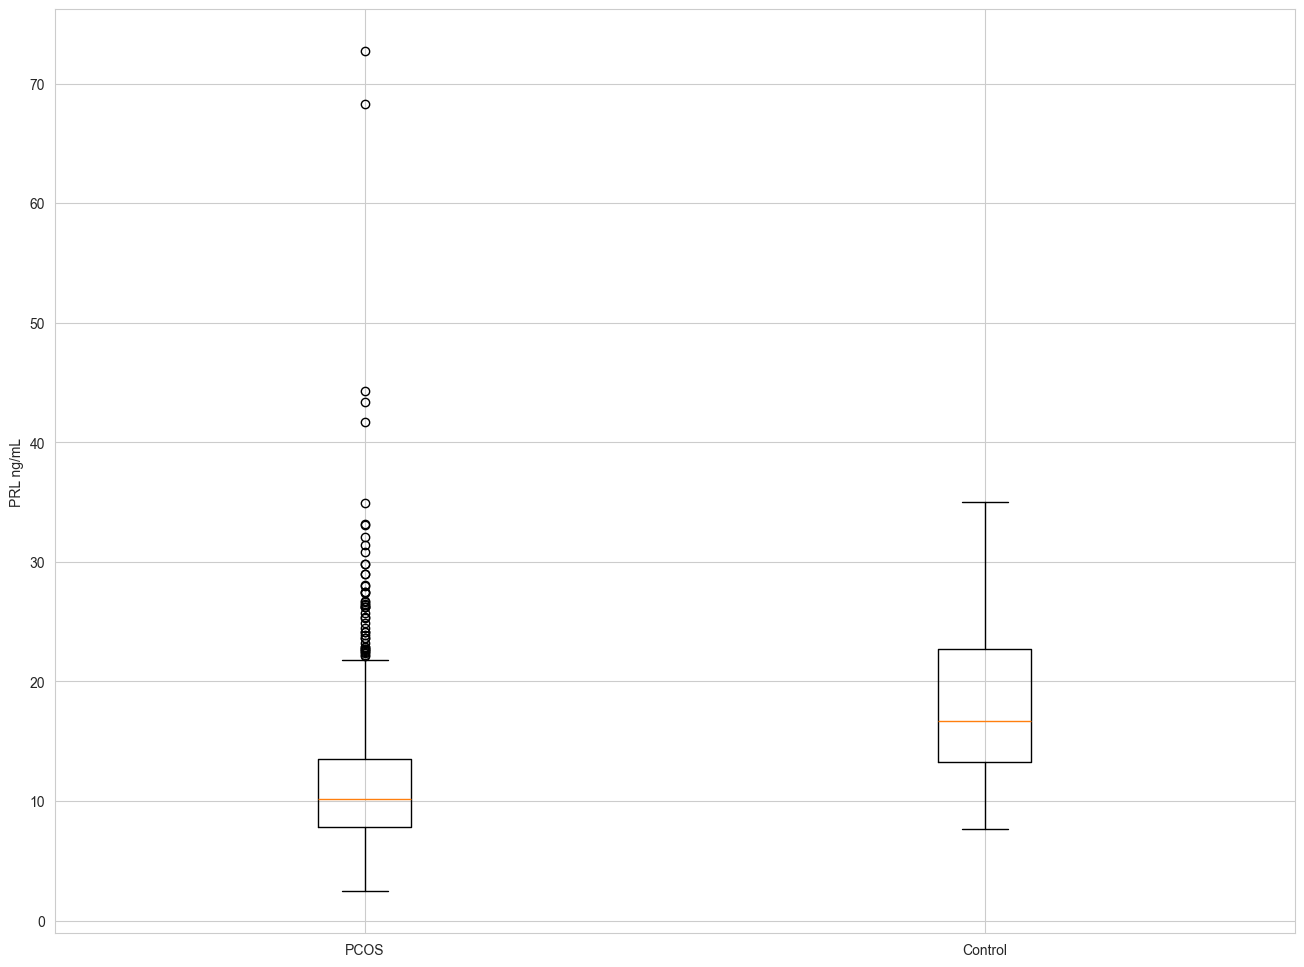

In [286]:
import matplotlib.pyplot as plt

plt.boxplot([pcos, ctrl], labels=['PCOS', 'Control'])
plt.ylabel('PRL ng/mL')
plt.show()

In [287]:
# Sprawdź overlap między dwiema kolumnamie rbc w PCOS
overlap_rbc = df[df['Morfologia CBC (RBC)'].notna() & df['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (RBC)'].notna()]
print(f"Pacjentki z oboma pomiarami rbc: {len(overlap_rbc)}")

if len(overlap_rbc) > 0:
    # Sprawdź korelację
    corr = overlap_rbc['Morfologia CBC (RBC)'].corr(
           overlap_rbc['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (RBC)'])
    print(f"Korelacja między pomiarami: {corr:.3f}")

Pacjentki z oboma pomiarami rbc: 0


## RDW – Column Consolidation

### Descriptive Statistics

| Column | N | Median | Unit |
|--------|---|--------|------|
| `Morfologia CBC (RDW)` | 44 | 12.55 | % |
| `Morfologia krwi... (RDW)` | 901 | 12.60 | % |
| `RDW %` | 45 | 12.60 | % |
| `Morfologia CBC (RDWSD)` | 44 | 40.25 | fL |
| `Morfologia krwi... (RDWSD)` | 901 | 41.60 | fL |

### Overlap Check

| Comparison | Overlap |
|------------|---------|
| RDW (%) columns (CBC vs diff vs Control) | **0 patients** |
| RDWSD (fL) columns (CBC vs diff) | **0 patients** |

### Decision

| Parameter | Columns | Unit | Action |
|-----------|---------|------|--------|
| **RDW** | `Morfologia CBC (RDW)` + `Morfologia krwi... (RDW)` + `RDW %` | % | Merge → `rdw_percent` |
| **RDWSD** | `Morfologia CBC (RDWSD)` + `Morfologia krwi... (RDWSD)` | fL | Merge → `rdwsd_fL` |

> No overlap detected – columns come from different patient subgroups. Merge is safe.

In [288]:
print("=" * 80)
print("RDW COLUMNS – DESCRIPTIVE STATISTICS")
print("=" * 80)

# List of RDW columns
rdw_columns = [
    'Morfologia CBC (RDW)',
    'Morfologia CBC (RDWSD)',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (RDW)',
    'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (RDWSD)',
    'RDW %'
]

# Create description dataframe
rdw_desc = []

for col in rdw_columns:
    if col in df.columns:
        series = df[col].dropna()
        rdw_desc.append({
            'Column': col,
            'N': len(series),
            'Mean': series.mean(),
            'Std': series.std(),
            'Min': series.min(),
            '25%': series.quantile(0.25),
            'Median': series.median(),
            '75%': series.quantile(0.75),
            'Max': series.max(),
            'Unit': 'fL' if 'RDWSD' in col else '%'
        })

rdw_desc_df = pd.DataFrame(rdw_desc)

# Display
print(rdw_desc_df.to_string(index=False))

# Save to CSV
rdw_desc_df.to_csv('rdw_columns_description.csv', index=False)
print("\n✅ Saved to 'rdw_columns_description.csv'")

# ============================================================================
# OVERLAP CHECK
# ============================================================================
print("\n" + "=" * 80)
print("RDW COLUMNS – OVERLAP CHECK")
print("=" * 80)

# Separate by unit type
rdw_percent_cols = [c for c in rdw_columns if c in df.columns and 'RDWSD' not in c]
rdw_fl_cols = [c for c in rdw_columns if c in df.columns and 'RDWSD' in c]

# Check overlap within percent columns
print("\n1. RDW (%) columns overlap:")
for i, col1 in enumerate(rdw_percent_cols):
    for col2 in rdw_percent_cols[i+1:]:
        overlap = df[df[col1].notna() & df[col2].notna()]
        print(f"   {col1[:40]}... vs {col2[:40]}...: {len(overlap)} pacjentek")

# Check overlap within fL columns
print("\n2. RDW (fL) columns overlap:")
for i, col1 in enumerate(rdw_fl_cols):
    for col2 in rdw_fl_cols[i+1:]:
        overlap = df[df[col1].notna() & df[col2].notna()]
        if len(overlap) > 0:
            corr = overlap[col1].corr(overlap[col2])
            print(f"   {col1[:40]}... vs {col2[:40]}...: {len(overlap)} pacjentek, korr={corr:.3f}")
        else:
            print(f"   {col1[:40]}... vs {col2[:40]}...: {len(overlap)} pacjentek")


RDW COLUMNS – DESCRIPTIVE STATISTICS
                                                                                       Column   N      Mean      Std  Min  25%  Median    75%  Max Unit
                                                                         Morfologia CBC (RDW)  44 13.000000 1.299374 10.6 12.2   12.55 13.325 17.6    %
                                                                       Morfologia CBC (RDWSD)  44 41.025000 2.968292 36.1 38.9   40.25 42.800 52.1   fL
  Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (RDW) 901 12.741620 0.939059 10.8 12.1   12.60 13.100 19.9    %
Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (RDWSD) 901 42.020866 2.770669 33.9 40.2   41.60 43.500 60.5   fL
                                                                                        RDW %  45 12.962222 1.227023 11.4 12.3   12.60 13.300 18.5    %

✅ Saved to 'rdw_columns_description.csv'

RDW COLU

In [289]:
# Sprawdź overlap między dwiema kolumnamie wbc w PCOS
overlap_wbc = df[df['Morfologia CBC (WBC)'].notna() & df['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (WBC)'].notna()]
print(f"Pacjentki z oboma pomiarami wbc: {len(overlap_wbc)}")

if len(overlap_wbc) > 0:
    # Sprawdź korelację
    corr = overlap_wbc['Morfologia CBC (WBC)'].corr(
           overlap_wbc['Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (WBC)'])
    print(f"Korelacja między pomiarami: {corr:.3f}")
                                                                                   

Pacjentki z oboma pomiarami wbc: 0


In [290]:
# TODO: Poprawić ręczne przypisanie kategorii do Testosteron Total

In [291]:
print("=" * 80)
print("COLUMN CONSOLIDATION – MERGING PARAMETERS & UPDATING QUALITY DICTIONARY")
print("=" * 80)

# Create a new DataFrame for merged parameters (start with original df)
df_merged = df.copy()

# Define mapping: new_variable -> list of source columns
merge_mapping = {
    'AMH_ng_ml': [
        'AMH (hormon anty-Mullerowski) (AMH_CP)',
        'AMH-anty Mullerian Hormon (AMH)',
        'AMH ng/ml'
    ],
    'androstenedione_ng_ml': [
        'Androstendion (ANDRO)',
        'Androstendion (I31)',
        'Androstendion (I31) (ANDRO)'
    ],
    'anti_tg_IU_mL': [
        'P/c antytyreoglobulinowe (anty-Tg) (ANTYTG2)',
        'Anty-TG (p/c przeciw tyreoglobulinie) (ATG)'
    ],
    'cortisol_8am_ug_dL': [
        'Kortyzol godz. 08:00 (KOR)',
        'kortyzol 8.00 ug/dl'
    ],
    'dheas_ug_dL': [
        'DHEAS (DHEA)',
        'DHEAS ug/dl'
    ],
    'fsh_iu_l': [
        'FSH IU/l',
        'FSH (FSH)'
    ],
    'glucose_fasting_mg_dL': [
        'Krzywa cukrowa - 2 punktowa (L_GLU_0)',
        "glu 0' mg/dl"
    ],
    'hematocrit_percent': [
        'Morfologia CBC (HCT)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (HCT)'
    ],
    'hemoglobin_g_dL': [
        'Morfologia CBC (HGB)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (HGB)'
    ],
    'insulin_fasting_uU_ml': [
        'Insulina (INSUL)',
        'Insulina po 75g glukozy (3pkt.) (INSUL_0)',
        'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 0m)',
        'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_0)',
        'insulina uU/ml'
    ],
    'insulin_30min_uU_ml': [
        'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 30m)',
        'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_1)'
    ],
    'insulin_60min_3pt_uU_ml': [
        'Insulina po 75g glukozy (3pkt.) (INSUL_1)'
    ],
    'insulin_60min_4pt_uU_ml': [
        'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 60m)',
        'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97_2)'
    ],
    'insulin_120min_3pt_uU_ml': [
        'Insulina po 75g glukozy (3pkt.) (INSUL_2)'
    ],
    'insulin_120min_4pt_uU_ml': [
        'Insulina po obciążeniu 75 g glukozy 0,1,2,3 (L97 120m)'
    ],
    'lh_iu_l': [
        'LH (LH)',
        'LH IU/l'
    ],
    'lymphocytes_abs_10_3_uL': [
        'Limf 10^3/uL',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (LIM#)'
    ],
    'mch_pg': [
        'Morfologia CBC (MCH)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCH)'
    ],
    'mchc_g_dL': [
        'Morfologia CBC (MCHC)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCHC)'
    ],
    'mcv_fL': [
        'Morfologia CBC (MCV)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MCV)'
    ],
    'mpv_fL': [
        'MPV fL',
        'Morfologia CBC (MPV)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (MPV)'
    ],
    'pct_percent': [
        'Morfologia CBC (PCT)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PCT)'
    ],
    'pdw_fL': [
        'Morfologia CBC (PDW)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PDW)'
    ],
    'plcr_percent': [
        'Morfologia CBC (PLCR)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PLCR)'
    ],
    'neutrophils_abs_10_3_uL': [
        'Neu 10^3/uL',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (NEUT#)'
    ],
    'platelets_10_3_uL': [
        'PLT 10^3/uL',
        'Morfologia CBC (PLT)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (PLT)'
    ],
    '17ohp_baseline_ng_ml': [
        '17 - OH progesteron (L79) (17-OHPG)',
        '17 OH progesteron (L79)'
    ],
    'prolactin_ng_ml': [
        'PRL godz. 10:00 (PRL10)',
        'PRL ng/ml'
    ],
    'rbc_10_6_uL': [
        'Morfologia CBC (RBC)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (RBC)'
    ],
    'rdw_percent': [
        'Morfologia CBC (RDW)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (RDW)',
        'RDW %'
    ],
    'rdwsd_fL': [
        'Morfologia CBC (RDWSD)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (RDWSD)'
    ],
    'shbg_nmol_l': [
        'SHBG nmol/l',
        'SHBG (L_SHGB)'
    ],
    'testosterone_ng_ml': [
        'testosteron ng/ml',
        'Testosteron (L_TESTOS)'
    ],
    'testosterone_free_nmol_L': [
        'Testosteron wolny (O41) (TEST-F)',
        'Wolny testosteron (O41.W)'
    ],
    'tsh_uIU_mL': [
        'TSH (TSH)',
        'TSH uIU/ml'
    ],
    'wbc_10_3_uL': [
        'Morfologia CBC (WBC)',
        'Morfologia krwi, z pełnym różnicowaniem granulocytów (leukocytów) z rozmazem - 5 Diff (WBC)',
        'WBC 10^3/uL'
    ]
}

# Perform merging and update parameter_quality
merged_count = 0
all_source_cols = set()

for new_var, source_cols in merge_mapping.items():
    # Filter existing columns
    existing_sources = [col for col in source_cols if col in df_merged.columns]
    if not existing_sources:
        print(f"⚠️ No source columns found for {new_var}")
        continue
    
    # Create merged column
    df_merged[new_var] = df_merged[existing_sources[0]]
    for col in existing_sources[1:]:
        df_merged[new_var] = df_merged[new_var].fillna(df_merged[col])
    
    # Mark source columns as obsolete in parameter_quality
    for col in existing_sources:
        if col in parameter_quality:
            parameter_quality[col]['useful'] = False
            parameter_quality[col]['exclude_reason'].append(f'merged into {new_var}')
            parameter_quality[col]['recommended_action'] = 'merged'
            parameter_quality[col]['merged_into'] = new_var
            all_source_cols.add(col)
            
    # Determine only_in_group for the new variable
    source_groups = set()
    for col in existing_sources:
        group = parameter_quality.get(col, {}).get('only_in_group')
        if group:
            source_groups.add(group)

    if len(source_groups) == 1:
        only_in_group = source_groups.pop()
    elif len(source_groups) > 1:
        only_in_group = None  # mixed PCOS + Control
    else:
        only_in_group = None  # unknown
    
    # Mark new variable as useful
    parameter_quality[new_var] = {
        'original_name': new_var,
        'data_type': 'float64',
        'n_total': len(df_merged),
        'n_nonnull': df_merged[new_var].notna().sum(),
        'n_unique': df_merged[new_var].nunique(),
        'useful': True,
        'exclude_reason': [],
        'only_in_group': only_in_group,
        'too_few_data': False,
        'no_variance': False,
        'formatting_errors': False,
        'unit_unknown': False,
        'outliers_detected': False,
        'detected_unit': parameter_quality.get(existing_sources[0], {}).get('detected_unit', None),        'category': parameter_quality.get(existing_sources[0], {}).get('category', 'Unknown'),
        'recommended_action': 'keep',
        'notes': [f'Consolidated from: {", ".join(existing_sources)}'],
        'merged_from': existing_sources
    }
    
    merged_count += 1
    print(f"✓ {new_var} (from {len(existing_sources)} columns)")

print(f"\n✅ Created {merged_count} consolidated variables")
print(f"✅ Marked {len(all_source_cols)} source columns as obsolete")

# ============================================================================
# VERIFICATION
# ============================================================================
print("\n" + "=" * 80)
print("VERIFICATION – USEFUL PARAMETERS AFTER CONSOLIDATION")
print("=" * 80)

useful_after = [col for col, info in parameter_quality.items() if info.get('useful') == True]
print(f"\n✅ Useful parameters: {len(useful_after)}")

# Display first 30 useful parameters
print(f"\nAll useful parameters [{len(useful_after)}]:")
for col in useful_after:
    info = parameter_quality[col]
    print(f"  • {col} [{info.get('category', 'Unknown')}] – {info.get('n_nonnull', 0)} values")

# Save updated DataFrame
df_merged.to_csv('df_merged.csv', index=False)
print("\n✅ Saved merged DataFrame to 'df_merged.csv'")

COLUMN CONSOLIDATION – MERGING PARAMETERS & UPDATING QUALITY DICTIONARY
✓ AMH_ng_ml (from 3 columns)
✓ androstenedione_ng_ml (from 3 columns)
✓ anti_tg_IU_mL (from 2 columns)
✓ cortisol_8am_ug_dL (from 2 columns)
✓ dheas_ug_dL (from 2 columns)
✓ fsh_iu_l (from 2 columns)
✓ glucose_fasting_mg_dL (from 2 columns)
✓ hematocrit_percent (from 2 columns)
✓ hemoglobin_g_dL (from 2 columns)
✓ insulin_fasting_uU_ml (from 5 columns)
✓ insulin_30min_uU_ml (from 2 columns)
✓ insulin_60min_3pt_uU_ml (from 1 columns)
✓ insulin_60min_4pt_uU_ml (from 2 columns)
✓ insulin_120min_3pt_uU_ml (from 1 columns)
✓ insulin_120min_4pt_uU_ml (from 1 columns)
✓ lh_iu_l (from 2 columns)
✓ lymphocytes_abs_10_3_uL (from 2 columns)
✓ mch_pg (from 2 columns)
✓ mchc_g_dL (from 2 columns)
✓ mcv_fL (from 2 columns)
✓ mpv_fL (from 3 columns)
✓ pct_percent (from 2 columns)
✓ pdw_fL (from 2 columns)
✓ plcr_percent (from 2 columns)
✓ neutrophils_abs_10_3_uL (from 2 columns)
✓ platelets_10_3_uL (from 3 columns)
✓ 17ohp_baseli

In [292]:
print("=" * 80)
print("FULL PARAMETER QUALITY DICTIONARY – ALL KEYS")
print("=" * 80)

# Collect all possible keys from all parameter dictionaries
all_keys = set()
for info in parameter_quality.values():
    all_keys.update(info.keys())

# Create DataFrame from all parameters
all_params_df = pd.DataFrame([
    {**{'Parameter': col}, **info}
    for col, info in parameter_quality.items()
])

# Reorder columns to put Parameter first
cols = ['Parameter'] + sorted([k for k in all_keys if k != 'Parameter'])
all_params_df = all_params_df[[c for c in cols if c in all_params_df.columns]]

# Display
print(f"\n📊 Total parameters: {len(all_params_df)}\n")
print(all_params_df.to_string(index=False))

# Save to CSV
all_params_df.to_csv('full_parameter_quality_dictionary.csv', index=False)
print("\n✅ Saved to 'full_parameter_quality_dictionary.csv'")

# Also display a compact view of useful vs excluded
print("\n" + "=" * 80)
print("COMPACT SUMMARY – USEFUL VS EXCLUDED")
print("=" * 80)

useful_count = sum(1 for info in parameter_quality.values() if info.get('useful') == True)
excluded_count = sum(1 for info in parameter_quality.values() if info.get('useful') == False)
total_count = len(parameter_quality)

print(f"\n  ✅ Useful: {useful_count}")
print(f"  ❌ Excluded: {excluded_count}")
print(f"  📊 Total: {total_count}")

# Show distribution of exclude reasons
print("\n" + "=" * 80)
print("EXCLUDE REASONS DISTRIBUTION")
print("=" * 80)

exclude_reasons = {}
for info in parameter_quality.values():
    for reason in info.get('exclude_reason', []):
        # Simplify reason for counting
        if 'too few data' in reason:
            simple_reason = 'too few data (N < 30)'
        elif 'only in' in reason:
            simple_reason = reason
        elif 'no variance' in reason:
            simple_reason = 'no variance (≤2 unique values)'
        elif 'merged into' in reason:
            simple_reason = 'merged into consolidated variable'
        elif 'formatting' in reason.lower():
            simple_reason = 'formatting errors'
        else:
            simple_reason = reason
        exclude_reasons[simple_reason] = exclude_reasons.get(simple_reason, 0) + 1

for reason, count in sorted(exclude_reasons.items(), key=lambda x: -x[1]):
    print(f"  {reason}: {count}")

FULL PARAMETER QUALITY DICTIONARY – ALL KEYS

📊 Total parameters: 260

                                                                                     Parameter               category      data_type detected_unit                                                                                                    exclude_reason  formatting_errors           max          mean        median                                                                                                                                                                              merged_from              merged_into           min  n_nonnull  n_total  n_unique  no_variance                                                                                                                                                                                                                                                                                                                                        notes   only_

PermissionError: [Errno 13] Permission denied: 'full_parameter_quality_dictionary.csv'

<span style="color:gray">

## BARDZO DRAFT!!! [po zakresy wartosci akceptowalnych trzeba luknac po jej pracach z ctrl+f i hasłem "outlier"]: Outlier Detection and Biological Plausibility Filtering

### Overview

Outliers were handled using two distinct approaches:

1. **Biological plausibility filtering** – values outside clinically meaningful ranges were replaced with `NaN`
2. **Statistical outlier detection (IQR)** – outliers were flagged and counted but **not removed** from the dataset

This dual approach ensures that biologically impossible values are excluded while preserving true biological variation (including PCOS-related extremes).

---

### 1. Biological Plausibility Filtering

For selected clinical parameters, biologically plausible ranges were defined based on established reference ranges for women of reproductive age, with adjustments for PCOS-specific elevations.

#### Defined Ranges (`bio_limits`)

| Parameter | Lower Bound | Upper Bound | Rationale |
|-----------|-------------|-------------|-----------|
| Testosterone | 0 | 10 ng/mL | PCOS may elevate testosterone, but >10 ng/mL suggests other pathology |
| DHEAS | 0 | 1000 μg/dL | Adrenal androgens may be elevated in PCOS |
| Androstenedione | 0 | 20 ng/mL | PCOS may elevate androstenedione |
| SHBG | 1 | 300 nmol/L | Very low SHBG (<1) or very high (>300) are biologically implausible |
| FSH | 0.1 | 50 IU/L | Ovarian failure typically >40; PCOS usually normal/low |
| LH | 0.1 | 80 IU/L | PCOS may have elevated LH but rarely >80 |
| AMH | 0 | 30 ng/mL | PCOS often has elevated AMH |
| Prolactin | 0 | 200 ng/mL | Hyperprolactinemia defined as >25-30; >200 suggests macroprolactinoma |
| Platelets (PLT) | 50 | 1000 × 10³/uL | Severe thrombocytopenia or thrombocytosis |
| MPV | 5 | 20 fL | Mean platelet volume beyond this range is unlikely |
| RDW | 8 | 25 % | Red cell distribution width beyond this range suggests other pathology |

#### Action

For each parameter with defined bounds:

```python
mask = (df[param] < lower) | (df[param] > upper)
df.loc[mask, param] = np.nan
```

- Values outside the defined range were replaced with `NaN`
- No whole-patient exclusion occurred at this stage
- Each replacement was logged with parameter name, number of affected values, and bounds used

#### Example

For testosterone with a measured value of 15 ng/mL (exceeding the upper bound of 10 ng/mL):

```python
# Before: df['testosterone'] = 15.0
mask = df['testosterone'] > 10
df.loc[mask, 'testosterone'] = np.nan
# After: df['testosterone'] = NaN
```

#### Output

- `biological_plausibility_log.csv` – log of all biologically implausible values replaced, containing:
  - Parameter name
  - Number of values replaced
  - Lower and upper bounds applied
  - Percentage of total observations affected

---

### 2. Statistical Outlier Detection (IQR)

Outliers were identified using the **interquartile range (IQR)** method but were **not removed** from the dataset. This approach preserves true biological variation while documenting extreme values for sensitivity analyses.

#### Method

For each numeric parameter:

- **Lower fence:** `Q1 - 1.5 × IQR`
- **Upper fence:** `Q3 + 1.5 × IQR`

```python
Q1 = df[param].quantile(0.25)
Q3 = df[param].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[(df[param] < lower_fence) | (df[param] > upper_fence)]
```

#### Action

- Outliers were **flagged and counted** only (`action = 'flag_only'`)
- **No values were replaced or winsorized**
- Outliers were documented for transparency and sensitivity analysis

#### Rationale for Not Removing Statistical Outliers

| Reason | Explanation |
|--------|-------------|
| **PCOS heterogeneity** | True biological variation (e.g., severe insulin resistance, very high LH, extreme hyperandrogenism) defines specific phenotypes and should be preserved |
| **Clinical extremes matter** | Very high testosterone or AMH may identify distinct PCOS subtypes that are clinically relevant |
| **Sample size preservation** | Removing outliers reduces statistical power, particularly problematic in subgroup analyses or with rare phenotypes |
| **Downstream method compatibility** | Clustering algorithms (e.g., k-means, hierarchical) and regression models can be run with and without outliers to assess robustness |
| **Transparency** | Flagging without removal allows readers to assess the impact of outliers on results |

#### Output

- `statistical_outliers_IQR_log.csv` – log of all statistical outliers by parameter, containing:
  - Parameter name
  - Number of outliers detected (lower and upper separately)
  - Q1, Q3, IQR, and fence values
  - Percentage of observations flagged as outliers

---

### 3. What Actually Gets Removed from Analysis

| Stage | Action | Impact |
|-------|--------|--------|
| **Biological plausibility** | Values outside `bio_limits` → `NaN` | ❌ Specific values only (converted to missing) |
| **Column-level missingness** | Columns with >30% missing values (except protected variables) | ❌ Entire columns excluded from analysis |
| **Statistical outliers (IQR)** | Flagged only | ❌ No removal |
| **Complete-case analysis (sensitivity)** | `df_cc = df.dropna(subset=required_vars)` | ⚠️ Whole patients excluded only for secondary sensitivity analysis |

#### Protected Variables

Certain key clinical variables were **excluded from column-level exclusion** even if missing >30%:
- `LIM#` (lymphocyte absolute count)
- `NEUT#` (neutrophil absolute count)
- `PLT` (platelet count)
- `MPV` (mean platelet volume)

These were preserved due to their clinical importance in PCOS phenotyping.

---

### 4. Summary Table

| Outlier Type | Detection Method | Action | Values Removed? | Patients Removed? | Logged? |
|--------------|------------------|--------|-----------------|-------------------|---------|
| Biologically implausible | Fixed clinical ranges | Replace with `NaN` | ✅ Yes (specific values only) | ❌ No | ✅ |
| Statistical (IQR) | `Q1 - 1.5×IQR` / `Q3 + 1.5×IQR` | Flag only | ❌ No | ❌ No | ✅ |
| Column-level missing | >30% missing (non-protected) | Drop column | ❌ No (whole column) | ❌ No | ✅ |

---

### 5. Sensitivity Analysis Plan

To assess the impact of outlier handling decisions, the following sensitivity analyses will be conducted:

1. **Primary analysis:** Biologically implausible values removed (`NaN`), statistical outliers retained
2. **Sensitivity analysis A:** Both biologically implausible values AND statistical outliers removed
3. **Sensitivity analysis B:** Neither removed (original data)
4. **Sensitivity analysis C:** Winsorization at 1st and 99th percentiles

Results will be compared across all four approaches. If results are consistent, the primary analysis (most conservative) will be reported.

---

### 6. Next Steps After Outlier Handling

1. ✅ Review biological plausibility logs – confirm replaced values are indeed implausible
2. ⬜ Run sensitivity analyses – compare results with vs. without statistical outliers
3. ⬜ Proceed to missing data imputation (mean/median, KNN, or MICE)
4. ⬜ Normalization before clustering (Z-score, Min-Max, or log transformation for skewed distributions)

```



# Outlier Detection & Biological Plausibility Filtering

**Methodology**: Comprehensive comparison of multiple outlier detection strategies for PCOS biomedical dataset.

**Approach**:
1. **Biological plausibility filtering FIRST** (remove clinically impossible values)
2. **Statistical outlier detection SECOND** (flag statistically extreme values)
3. **Log but don't delete** (maintain reproducibility and data integrity)
4. **Available-case inference** (preserve sample sizes across analyses)

This section tests: IQR, Z-Score, Modified Z-Score, and LOF methods on your merged dataset.

In [ ]:
# Setup: Import additional libraries for outlier detection
import numpy as np
import scipy.stats as stats
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings('ignore')

# Get numeric columns from the merged dataset (assuming df_merged exists)
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()

print("=" * 80)
print("OUTLIER DETECTION SETUP")
print("=" * 80)
print(f"Total rows: {len(df_merged)}")
print(f"Total numeric columns: {len(numeric_cols)}")
print(f"\nNumeric columns: {numeric_cols[:20]}...")

OUTLIER DETECTION SETUP
Total rows: 1331
Total numeric columns: 228

Numeric columns: ['Wiek', '17 - OH progesteron (L79) (17-OHPG)', '17 OH progesteron (L79)', 'ALAT (ALT)', 'AMH (hormon anty-Mullerowski) (AMH_CP)', 'AMH ng/ml', 'AMH-anty Mullerian Hormon (AMH)', 'APTT Czas kaolinowo-kefalinowy (APTTCZ)', 'ASO - ilościowo (ASOIL)', 'ASPAT (AST)', 'Androstendion (ANDRO)', 'Androstendion (I31)', 'Androstendion (I31) (ANDRO)', 'Anty-TG (O18)', 'Anty-TG (p/c przeciw tyreoglobulinie) (ATG)', 'Anty-TPO (ATA_TPO)', 'BMI kg/m2', 'Białko C-reaktywne (CRP)', 'Bilirubina całkowita (TBIL)', 'CEA (CEA)']...


In [ ]:
# PHASE 1: BIOLOGICAL PLAUSIBILITY FILTERING (Piórkowska approach)
# Define clinically plausible ranges for key parameters

print("=" * 80)
print("PHASE 1: BIOLOGICAL PLAUSIBILITY RANGES")
print("=" * 80)

# Biological plausibility ranges based on clinical laboratory standards
# Format: column_name -> (min, max, description)
# Not all of these parameters' thresholds are verified
biological_ranges = {
    # Hormones (common PCOS markers)
    'Testosteron': (0, 10, 'nmol/L'),
    'DHEAS': (0, 1000, 'μmol/L'),
    'Androstendion': (0, 20, 'nmol/L'),
    'SHBG': (1, 300, 'nmol/L'),
    'FSH': (0.1, 50, 'mIU/mL'),
    'LH': (0.1, 80, 'mIU/mL'),
    'AMH': (0.0, 30, 'ng/mL'),
    'PRL': (0.0, 200, 'ng/mL'),
    'Estradiol': (0, 500, 'pg/mL'),
    '17OHP': (0, 10, 'ng/mL'),
    'Cortisol': (3, 30, 'μg/dL'),
    'TSH': (0.01, 10, 'mIU/L'),
    'FT3': (1.0, 5.0, 'pg/mL'),
    'FT4': (0.7, 2.0, 'ng/dL'),
    
    # Metabolic
    'Glikemia': (40, 200, 'mg/dL'),
    'Insulina': (0.5, 50, 'μU/mL'),
    'HOMA_IR': (0, 20, 'index'),
    'HbA1c': (3, 15, '%'),
    'Glukoza': (40, 200, 'mg/dL'),
    
    # Lipids
    'Cholesterol': (50, 300, 'mg/dL'),
    'Triglycerides': (30, 500, 'mg/dL'),
    'LDL': (20, 250, 'mg/dL'),
    'HDL': (10, 120, 'mg/dL'),
    
    # Inflammatory markers
    'CRP': (0.1, 100, 'mg/L'),
    
    # CBC - Platelets
    'PLT': (50, 1000, '10^3/μL'),
    'MPV': (5, 20, 'fL'),
    'PCT': (0.1, 1.0, '%'),
    'PDW': (10, 20, '%'),
    'PLCR': (20, 60, '%'),
    
    # CBC - RBC
    'RBC': (3.5, 6.0, '10^6/μL'),
    'HGB': (6.5, 20, 'g/dL'),
    'HCT': (25, 55, '%'),
    'MCV': (75, 100, 'fL'),
    'MCH': (25, 35, 'pg'),
    'MCHC': (30, 37, 'g/dL'),
    'RDW': (11, 16, '%'),
    'RDWSD': (39, 46, 'fL'),
    
    # CBC - WBC
    'WBC': (3.5, 12, '10^3/μL'),
    'NEU': (50, 80, '%'),
    'LIM': (15, 45, '%'),
    'MON': (2, 12, '%'),
    'EOS': (0, 6, '%'),
    'BAS': (0, 2, '%'),
    'NEUT#': (1.5, 8, '10^3/μL'),
    'LIM#': (0.5, 5, '10^3/μL'),
    'MON#': (0.1, 1.5, '10^3/μL'),
    'EOS#': (0, 0.5, '10^3/μL'),
    'BAS#': (0, 0.2, '10^3/μL'),
}

# Apply biological plausibility filtering
df_biologically_plausible = df_merged.copy()
bioplausibility_log = []

for col, (min_val, max_val, unit) in biological_ranges.items():
    if col in df_biologically_plausible.columns:
        series = df_biologically_plausible[col]
        
        # Count original valid values
        n_before = series.notna().sum()
        
        # Identify implausible values
        implausible_mask = (series < min_val) | (series > max_val)
        n_implausible = implausible_mask.sum()
        
        # Set implausible values to NaN
        df_biologically_plausible.loc[implausible_mask, col] = np.nan
        
        # Count after plausibility check
        n_after = df_biologically_plausible[col].notna().sum()
        
        if n_implausible > 0:
            bioplausibility_log.append({
                'Parameter': col,
                'Unit': unit,
                'Plausible_Range': f"[{min_val}, {max_val}]",
                'N_Before': n_before,
                'N_Implausible': n_implausible,
                'N_After': n_after,
                'Pct_Lost': (n_implausible / n_before * 100) if n_before > 0 else 0
            })

# Display results
bioplausibility_df = pd.DataFrame(bioplausibility_log)
if len(bioplausibility_df) > 0:
    bioplausibility_df = bioplausibility_df.sort_values('N_Implausible', ascending=False)
    print(f"\nBiologically implausible values detected and set to NaN:")
    display(bioplausibility_df)
else:
    print("\n✅ No biologically implausible values detected in your data.")

print(f"\n✅ PHASE 1 COMPLETE: Biological plausibility filtering applied")
print(f"   Working dataset shape: {df_biologically_plausible.shape}")

PHASE 1: BIOLOGICAL PLAUSIBILITY RANGES

✅ No biologically implausible values detected in your data.

✅ PHASE 1 COMPLETE: Biological plausibility filtering applied
   Working dataset shape: (1331, 260)


In [ ]:
# PHASE 2A: IQR METHOD (Interquartile Range)
# Conservative approach: Outliers beyond 1.5 × IQR from Q1/Q3

print("\n" + "=" * 80)
print("PHASE 2A: IQR (INTERQUARTILE RANGE) METHOD")
print("=" * 80)
print("Rule: Values beyond Q1 - 1.5×IQR or Q3 + 1.5×IQR are flagged")
print()

def detect_outliers_iqr(df, cols=None):
    """
    Detect outliers using IQR method (1.5×IQR)
    Returns: tuple (outlier_mask_dict, summary_df, outlier_details_dict)
    """
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    outlier_counts = []
    outlier_details = {}
    outlier_mask_dict = {}
    
    for col in cols:
        series = df[col].dropna()
        
        if len(series) < 5:  # Need at least 5 points for meaningful IQR
            continue
        
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Detect outliers
        outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        n_outliers = outlier_mask.sum()
        
        outlier_mask_dict[col] = outlier_mask
        
        if n_outliers > 0:
            outlier_indices = df[outlier_mask].index.tolist()
            outlier_values = df.loc[outlier_indices, col].values
            
            outlier_counts.append({
                'Parameter': col,
                'N_Valid': len(series),
                'Q1': q1,
                'Q3': q3,
                'IQR': iqr,
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound,
                'N_Outliers': n_outliers,
                'Pct_Outliers': (n_outliers / len(df)) * 100
            })
            
            outlier_details[col] = {
                'indices': outlier_indices,
                'values': outlier_values,
                'bounds': (lower_bound, upper_bound)
            }
    
    outlier_df = pd.DataFrame(outlier_counts).sort_values('N_Outliers', ascending=False)
    
    return outlier_mask_dict, outlier_df, outlier_details

# Run IQR detection
iqr_masks, iqr_summary, iqr_details = detect_outliers_iqr(df_biologically_plausible, numeric_cols)

print(f"\nSummary: {len(iqr_summary)} parameters with detected outliers")
print(f"Total outlier flags (single values across all parameters): {iqr_summary['N_Outliers'].sum()}")
display(iqr_summary.head(20))

# Store for later comparison
outlier_methods = {'iqr': {'summary': iqr_summary, 'details': iqr_details, 'masks': iqr_masks}}


PHASE 2A: IQR (INTERQUARTILE RANGE) METHOD
Rule: Values beyond Q1 - 1.5×IQR or Q3 + 1.5×IQR are flagged


Summary: 159 parameters with detected outliers
Total outlier flags (single values across all parameters): 3153


,Parameter,N_Valid,Q1,Q3,IQR,Lower_Bound,Upper_Bound,N_Outliers,Pct_Outliers
125,anti_tg_IU_mL,936,11.5750,17.9250,6.3500,2.05000,27.45000,299,22.464313
79,"Morfologia krwi, z pełnym różnicowaniem granul...",901,0.2000,0.3000,0.1000,0.05000,0.45000,118,8.865515
14,Anty-TPO (ATA_TPO),1043,9.0000,14.3000,5.3000,1.05000,22.25000,114,8.564989
98,P/c antytyreoglobulinowe (anty-Tg) (ANTYTG2),682,14.6000,18.7000,4.1000,8.45000,24.85000,109,8.189331
48,Kortyzol godz. 23:00 (KOR23),1167,1.4100,3.6650,2.2550,-1.97250,7.04750,86,6.461307
149,17ohp_baseline_ng_ml,1177,0.7200,1.6500,0.9300,-0.67500,3.04500,74,5.559730
138,lh_iu_l,1213,4.9200,10.2000,5.2800,-3.00000,18.12000,73,5.484598
56,LH (LH),1168,4.9075,10.2475,5.3400,-3.10250,18.25750,73,5.484598
132,insulin_fasting_uU_ml,1156,5.1825,10.5000,5.3175,-2.79375,18.47625,68,5.108941
156,testosterone_free_nmol_L,1115,1.2450,3.6100,2.3650,-2.30250,7.15750,62,4.658152


In [ ]:
# PHASE 2B: Z-SCORE METHOD

print("\n" + "=" * 80)
print("PHASE 2B: Z-SCORE METHOD")
print("=" * 80)
print("Rule: |Z-score| > 3.0 (very conservative, ~0.3% expected)")
print()

def detect_outliers_zscore(df, cols=None, threshold=3.0):
    """Detect outliers using Z-score method"""
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    outlier_counts = []
    outlier_details = {}
    outlier_mask_dict = {}
    
    for col in cols:
        series = df[col].dropna()
        
        if len(series) < 5:
            continue
        
        mean = series.mean()
        std = series.std()
        
        if std == 0:
            continue
        
        z_scores = np.abs((df[col] - mean) / std)
        outlier_mask = z_scores > threshold
        n_outliers = outlier_mask.sum()
        
        outlier_mask_dict[col] = outlier_mask
        
        if n_outliers > 0:
            outlier_indices = df[outlier_mask].index.tolist()
            outlier_values = df.loc[outlier_indices, col].values
            z_values = z_scores[outlier_mask].values
            
            outlier_counts.append({
                'Parameter': col,
                'N_Valid': len(series),
                'Mean': mean,
                'Std': std,
                'Threshold_|Z|': threshold,
                'N_Outliers': n_outliers,
                'Pct_Outliers': (n_outliers / len(df)) * 100,
                'Max_|Z|': z_values.max()
            })
            
            outlier_details[col] = {
                'indices': outlier_indices,
                'values': outlier_values,
                'z_scores': z_values
            }
    
    outlier_df = pd.DataFrame(outlier_counts).sort_values('N_Outliers', ascending=False)
    
    return outlier_mask_dict, outlier_df, outlier_details

# Run Z-Score detection (threshold = 3.0)
zscore_masks, zscore_summary, zscore_details = detect_outliers_zscore(
    df_biologically_plausible, numeric_cols, threshold=3.0
)

print(f"\nZ-Score Method (|Z| > 3.0):")
print(f"  Parameters with outliers: {len(zscore_summary)}")
print(f"  Total outlier flags: {zscore_summary['N_Outliers'].sum()}")
display(zscore_summary.head(20))

# Also try threshold = 2.5 for comparison
zscore_masks_2_5, zscore_summary_2_5, zscore_details_2_5 = detect_outliers_zscore(
    df_biologically_plausible, numeric_cols, threshold=2.5
)

print(f"\nZ-Score Method (|Z| > 2.5) - More sensitive:")
print(f"  Parameters with outliers: {len(zscore_summary_2_5)}")
print(f"  Total outlier flags: {zscore_summary_2_5['N_Outliers'].sum()}")

outlier_methods['zscore_3'] = {'summary': zscore_summary, 'details': zscore_details, 'masks': zscore_masks}
outlier_methods['zscore_2_5'] = {'summary': zscore_summary_2_5, 'details': zscore_details_2_5, 'masks': zscore_masks_2_5}


PHASE 2B: Z-SCORE METHOD
Rule: |Z-score| > 3.0 (very conservative, ~0.3% expected)


Z-Score Method (|Z| > 3.0):
  Parameters with outliers: 137
  Total outlier flags: 1005


,Parameter,N_Valid,Mean,Std,Threshold_|Z|,N_Outliers,Pct_Outliers,Max_|Z|
13,Anty-TPO (ATA_TPO),1043,23.989732,56.106182,3.0,28,2.103681,10.266431
40,Kortyzol godz. 23:00 (KOR23),1167,3.066470,2.555366,3.0,27,2.028550,8.270255
116,lh_iu_l,1213,8.347016,5.228696,3.0,25,1.878287,5.193070
48,LH (LH),1168,8.390445,5.301794,3.0,22,1.652893,5.113279
95,Triglicerydy (TG),1169,88.072198,43.443143,3.0,21,1.577761,6.489581
1,17 - OH progesteron (L79) (17-OHPG),965,1.182603,0.827690,3.0,21,1.577761,9.183060
102,androstenedione_ng_ml,1126,2.144569,1.238036,3.0,20,1.502630,6.078524
134,testosterone_free_nmol_L,1115,2.828318,2.318040,3.0,19,1.427498,6.398373
87,SHBG (L_SHGB),1166,53.167796,31.263107,3.0,19,1.427498,9.078823
132,shbg_nmol_l,1211,53.580471,31.074265,3.0,19,1.427498,9.120715



Z-Score Method (|Z| > 2.5) - More sensitive:
  Parameters with outliers: 153
  Total outlier flags: 1845


In [ ]:
# PHASE 2C: MODIFIED Z-SCORE METHOD (MAD - Median Absolute Deviation)

print("\n" + "=" * 80)
print("PHASE 2C: MODIFIED Z-SCORE METHOD (MAD - Median Absolute Deviation)")
print("=" * 80)
print("Rule: Modified Z-score > 3.5 (robust to skewness)")
print()

def detect_outliers_modified_zscore(df, cols=None, threshold=3.5):
    """Detect outliers using Modified Z-score with Median Absolute Deviation"""
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    outlier_counts = []
    outlier_details = {}
    outlier_mask_dict = {}
    
    for col in cols:
        series = df[col].dropna()
        
        if len(series) < 5:
            continue
        
        median = series.median()
        mad = np.median(np.abs(series - median))
        
        if mad == 0:
            continue
        
        modified_z = 0.6745 * (df[col] - median) / mad
        outlier_mask = np.abs(modified_z) > threshold
        n_outliers = outlier_mask.sum()
        
        outlier_mask_dict[col] = outlier_mask
        
        if n_outliers > 0:
            outlier_indices = df[outlier_mask].index.tolist()
            outlier_values = df.loc[outlier_indices, col].values
            mod_z_values = np.abs(modified_z[outlier_mask].values)
            
            outlier_counts.append({
                'Parameter': col,
                'N_Valid': len(series),
                'Median': median,
                'MAD': mad,
                'Threshold_ModZ': threshold,
                'N_Outliers': n_outliers,
                'Pct_Outliers': (n_outliers / len(df)) * 100,
                'Max_ModZ': mod_z_values.max()
            })
            
            outlier_details[col] = {
                'indices': outlier_indices,
                'values': outlier_values,
                'modified_z_scores': mod_z_values
            }
    
    outlier_df = pd.DataFrame(outlier_counts).sort_values('N_Outliers', ascending=False)
    
    return outlier_mask_dict, outlier_df, outlier_details

# Run Modified Z-Score detection
mod_zscore_masks, mod_zscore_summary, mod_zscore_details = detect_outliers_modified_zscore(
    df_biologically_plausible, numeric_cols, threshold=3.5
)

print(f"\nModified Z-Score Method (ModZ > 3.5):")
print(f"  Parameters with outliers: {len(mod_zscore_summary)}")
print(f"  Total outlier flags: {mod_zscore_summary['N_Outliers'].sum()}")
display(mod_zscore_summary.head(20))

outlier_methods['mod_zscore'] = {'summary': mod_zscore_summary, 'details': mod_zscore_details, 'masks': mod_zscore_masks}


PHASE 2C: MODIFIED Z-SCORE METHOD (MAD - Median Absolute Deviation)
Rule: Modified Z-score > 3.5 (robust to skewness)


Modified Z-Score Method (ModZ > 3.5):
  Parameters with outliers: 142
  Total outlier flags: 1888


,Parameter,N_Valid,Median,MAD,Threshold_ModZ,N_Outliers,Pct_Outliers,Max_ModZ
12,Anty-TPO (ATA_TPO),1043,10.330,1.330,3.5,163,12.246431,299.046929
110,anti_tg_IU_mL,936,15.200,2.900,3.5,114,8.564989,339.994517
89,P/c antytyreoglobulinowe (anty-Tg) (ANTYTG2),682,16.300,1.900,3.5,105,7.888805,518.548500
44,Kortyzol godz. 23:00 (KOR23),1167,2.250,1.000,3.5,80,6.010518,14.805275
123,lh_iu_l,1213,7.040,2.360,3.5,58,4.357626,8.134013
117,insulin_fasting_uU_ml,1156,7.165,2.465,3.5,57,4.282494,24.909983
52,LH (LH),1168,7.040,2.410,3.5,57,4.282494,7.965257
133,17ohp_baseline_ng_ml,1177,1.090,0.430,3.5,51,3.831705,12.067798
1,17 - OH progesteron (L79) (17-OHPG),965,0.990,0.340,3.5,47,3.531180,15.460598
11,Anty-TG (p/c przeciw tyreoglobulinie) (ATG),254,1.180,0.610,3.5,46,3.456048,1104.432934


In [ ]:
# PHASE 2: COMPREHENSIVE COMPARISON OF OUTLIER DETECTION METHODS

print("\n" + "=" * 80)
print("PHASE 2: COMPREHENSIVE COMPARISON")
print("=" * 80)

# Create comparison summary
comparison_data = []

# IQR summary
comparison_data.append({
    'Method': 'IQR (1.5×IQR)',
    'Type': 'Univariate',
    'Parameters_Affected': len(iqr_summary),
    'Total_Flags': int(iqr_summary['N_Outliers'].sum()),
    'Max_Flags_Single_Param': int(iqr_summary['N_Outliers'].max()),
    'Characteristics': 'Conservative; robust to skew'
})

# Z-Score 3.0
comparison_data.append({
    'Method': 'Z-Score (|Z| > 3.0)',
    'Type': 'Univariate',
    'Parameters_Affected': len(zscore_summary),
    'Total_Flags': int(zscore_summary['N_Outliers'].sum()),
    'Max_Flags_Single_Param': int(zscore_summary['N_Outliers'].max()),
    'Characteristics': 'Very conservative; assumes normality'
})

# Z-Score 2.5
comparison_data.append({
    'Method': 'Z-Score (|Z| > 2.5)',
    'Type': 'Univariate',
    'Parameters_Affected': len(zscore_summary_2_5),
    'Total_Flags': int(zscore_summary_2_5['N_Outliers'].sum()),
    'Max_Flags_Single_Param': int(zscore_summary_2_5['N_Outliers'].max()),
    'Characteristics': 'Moderate; more sensitive'
})

# Modified Z-Score
comparison_data.append({
    'Method': 'Modified Z-Score (MAD > 3.5)',
    'Type': 'Univariate',
    'Parameters_Affected': len(mod_zscore_summary),
    'Total_Flags': int(mod_zscore_summary['N_Outliers'].sum()),
    'Max_Flags_Single_Param': int(mod_zscore_summary['N_Outliers'].max()),
    'Characteristics': 'Robust to skewness & extremes'
})


comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

print("\n" + "=" * 80)
print("INTERPRETATION GUIDE")
print("=" * 80)
print("""
For PCOS biomedical data (Piórkowska approach):

✓ IQR Method: 
  - RECOMMENDED PRIMARY APPROACH
  - Conservative, well-established in clinical literature
  - Robust to different distributions
  - Easy to interpret and explain
  
✓ Modified Z-Score (MAD):
  - Better than Z-score for skewed data (common in biomarkers)
  - More resistant to extreme values
  
⚠ Z-Score (|Z| > 3.0):
  - Use with caution; assumes normality
  - Assumes symmetric distribution
  - Better only if data verified as normal
""")


PHASE 2: COMPREHENSIVE COMPARISON


,Method,Type,Parameters_Affected,Total_Flags,Max_Flags_Single_Param,Characteristics
0,IQR (1.5×IQR),Univariate,159,3153,299,Conservative; robust to skew
1,Z-Score (|Z| > 3.0),Univariate,137,1005,28,Very conservative; assumes normality
2,Z-Score (|Z| > 2.5),Univariate,153,1845,42,Moderate; more sensitive
3,Modified Z-Score (MAD > 3.5),Univariate,142,1888,163,Robust to skewness & extremes



INTERPRETATION GUIDE

For PCOS biomedical data (Piórkowska approach):

✓ IQR Method: 
  - RECOMMENDED PRIMARY APPROACH
  - Conservative, well-established in clinical literature
  - Robust to different distributions
  - Easy to interpret and explain

✓ Modified Z-Score (MAD):
  - GOOD SECONDARY APPROACH
  - Better than Z-score for skewed data (common in biomarkers)
  - More resistant to extreme values

⚠ Z-Score (|Z| > 3.0):
  - Use with caution; assumes normality
  - Assumes symmetric distribution
  - Better only if data verified as normal

◆ LOF (Local Outlier Factor):
  - SENSITIVITY ANALYSIS / ADVANCED
  - Excellent for detecting multivariate anomalies
  - Captures records with unusual combinations across multiple parameters
  - Use to identify complex outliers IQR might miss

RECOMMENDATION FOR YOUR WORKFLOW:
1. Apply Biological Plausibility Filter FIRST (Phase 1) ✓ DONE
2. Use IQR for univariate flagging (conservative, reproducible)
3. Optional: Combine with LOF for sensitivity a

COMPREHENSIVE OUTLIER VISUALIZATION


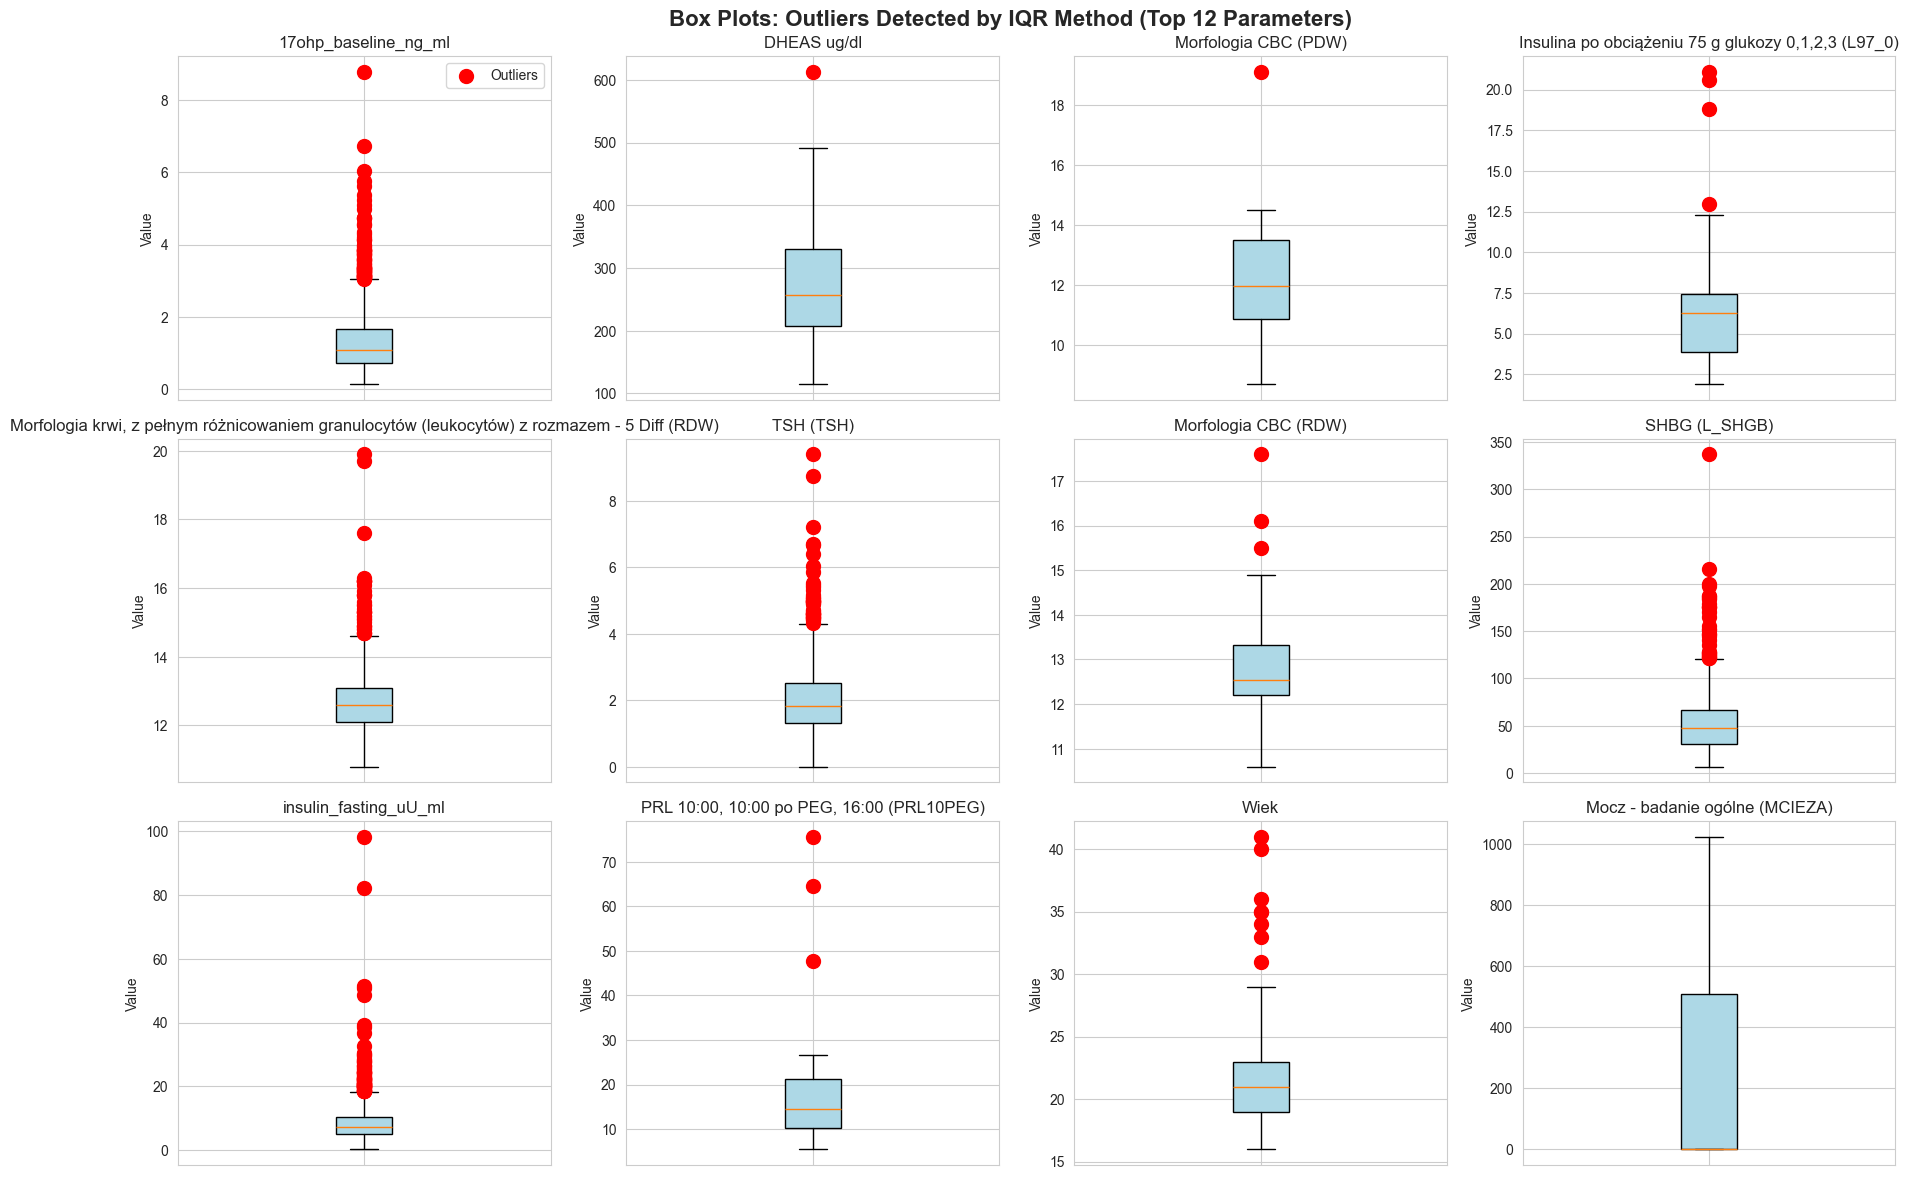

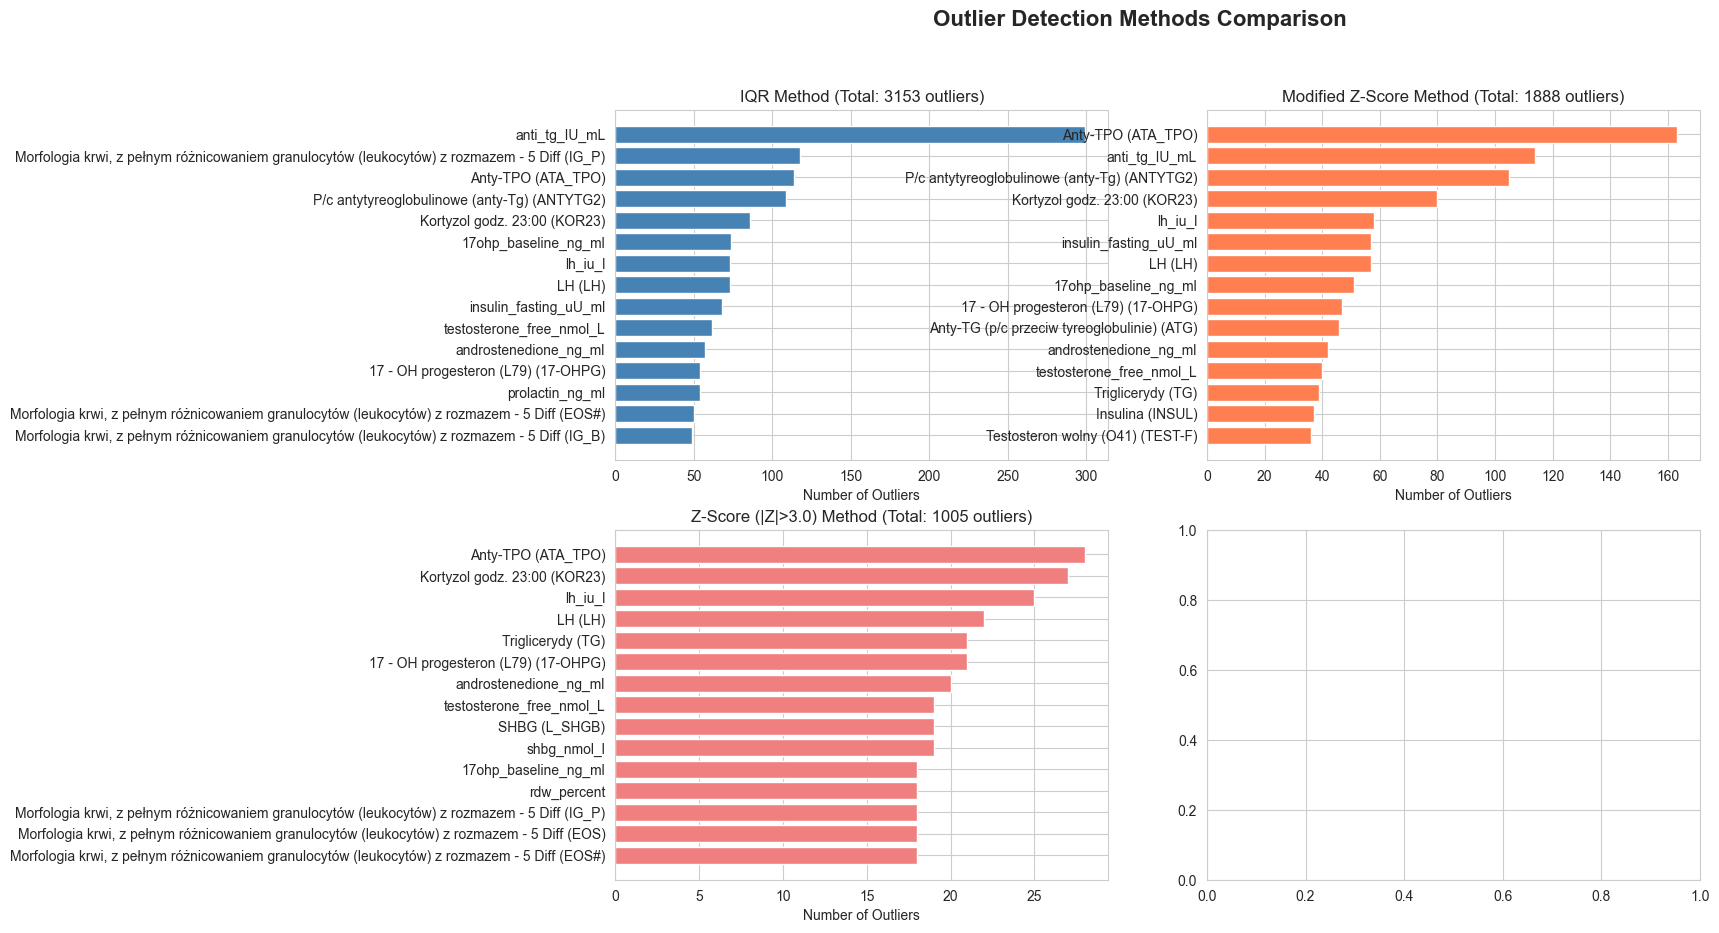

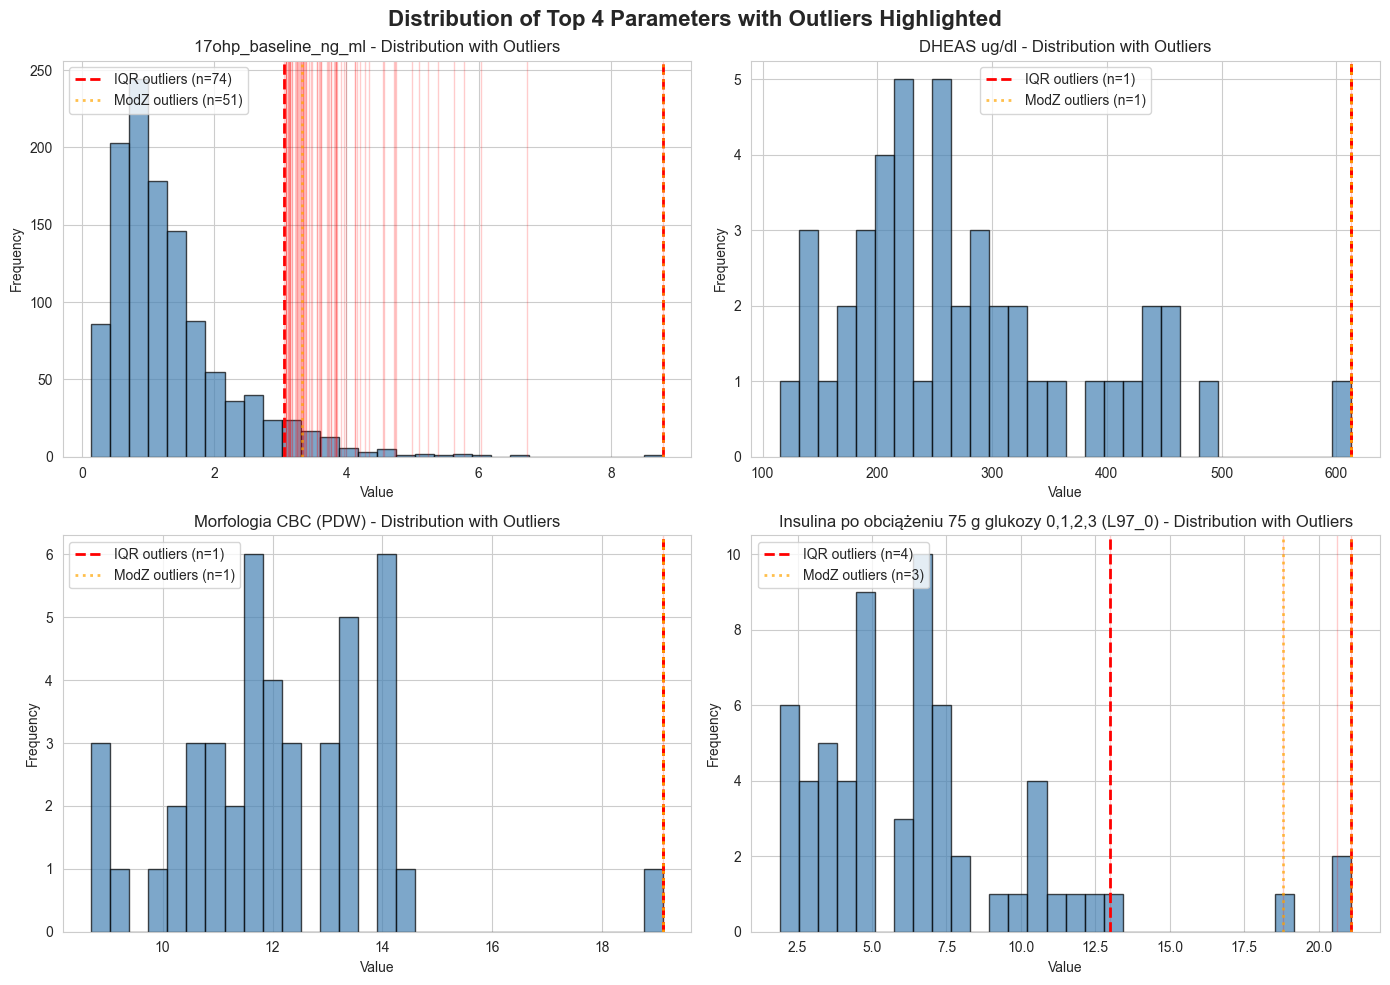

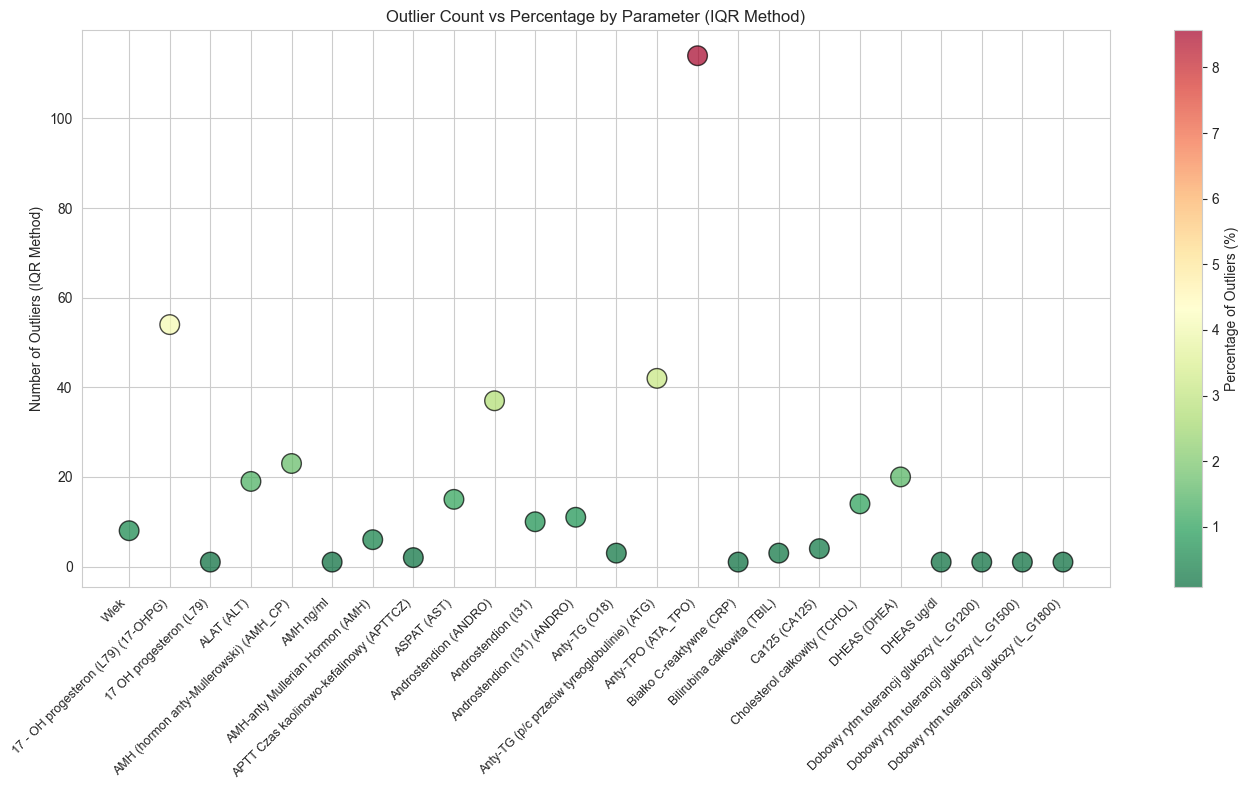


✅ ALL VISUALIZATIONS COMPLETE


In [ ]:
# VISUALIZATION: OUTLIER DETECTION ACROSS ALL METHODS

print("=" * 80)
print("COMPREHENSIVE OUTLIER VISUALIZATION")
print("=" * 80)

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Get top parameters with outliers across all methods
all_outlier_params = set()
for method_key in ['iqr', 'zscore_3', 'mod_zscore']:
    if method_key in ['iqr', 'mod_zscore']:
        method_details = outlier_methods[method_key]['details']
    else:
        method_details = outlier_methods.get('zscore', {}).get('details', {})
    all_outlier_params.update(method_details.keys())

# Select top 12 parameters with most outliers overall
top_params_list = []
for param in list(all_outlier_params)[:12]:
    count = sum([1 for method_key in outlier_methods.values() 
                 if 'details' in method_key and param in method_key['details']])
    top_params_list.append((param, count))

top_params = sorted(top_params_list, key=lambda x: x[1], reverse=True)[:12]
top_param_names = [p[0] for p in top_params]

# 1. Box plots with outliers highlighted
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Box Plots: Outliers Detected by IQR Method (Top 12 Parameters)', fontsize=16, fontweight='bold')

for idx, param in enumerate(top_param_names):
    ax = axes[idx // 4, idx % 4]
    
    if param not in df_biologically_plausible.columns:
        continue
    
    data = df_biologically_plausible[param].dropna()
    
    # Create box plot
    bp = ax.boxplot(data, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    
    # Highlight IQR outliers
    if param in iqr_details:
        outlier_indices = iqr_details[param]['indices']
        outlier_values = df_biologically_plausible.loc[outlier_indices, param]
        n_outliers = int(outlier_values.shape[0]) if hasattr(outlier_values, 'shape') else int(len(outlier_values))
        ax.scatter([1]*n_outliers, outlier_values, color='red', s=100, zorder=3, label='Outliers')
    
    ax.set_ylabel('Value')
    ax.set_title(f'{param}')
    ax.set_xticklabels([''])
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()


# 2. Comparison of outlier counts by method
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Outlier Detection Methods Comparison', fontsize=16, fontweight='bold')

# IQR
ax1 = axes[0][0]
iqr_data = iqr_summary.nlargest(15, 'N_Outliers')
ax1.barh(iqr_data['Parameter'], iqr_data['N_Outliers'], color='steelblue')
ax1.set_xlabel('Number of Outliers')
ax1.set_title(f'IQR Method (Total: {int(iqr_summary["N_Outliers"].sum())} outliers)')
ax1.invert_yaxis()

# Modified Z-Score
ax2 = axes[0][1]
modz_data = mod_zscore_summary.nlargest(15, 'N_Outliers')
ax2.barh(modz_data['Parameter'], modz_data['N_Outliers'], color='coral')
ax2.set_xlabel('Number of Outliers')
ax2.set_title(f'Modified Z-Score Method (Total: {int(mod_zscore_summary["N_Outliers"].sum())} outliers)')
ax2.invert_yaxis()

# Z-Score (3.0)
ax3 = axes[1][0]
z_data = zscore_summary.nlargest(15, 'N_Outliers')
ax3.barh(z_data['Parameter'], z_data['N_Outliers'], color='lightcoral')
ax3.set_xlabel('Number of Outliers')
ax3.set_title(f'Z-Score (|Z|>3.0) Method (Total: {int(zscore_summary["N_Outliers"].sum())} outliers)')
ax3.invert_yaxis()



# 3. Distribution plots for top 4 parameters with outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Top 4 Parameters with Outliers Highlighted', fontsize=16, fontweight='bold')

top_4_params = top_param_names[:4]
for idx, param in enumerate(top_4_params):
    ax = axes[idx // 2, idx % 2]
    
    if param not in df_biologically_plausible.columns:
        continue
    
    data = df_biologically_plausible[param].dropna()
    
    # Plot histogram
    ax.hist(data, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Add outlier markers
    if param in iqr_details:
        outlier_vals = np.array(iqr_details[param]['values'])
        n_iqr = int(len(outlier_vals)) if hasattr(outlier_vals, '__len__') else 1
        ax.axvline(outlier_vals.min(), color='red', linestyle='--', linewidth=2, label=f'IQR outliers (n={n_iqr})')
        ax.axvline(outlier_vals.max(), color='red', linestyle='--', linewidth=2)
        
        # Add vertical lines at outlier positions
        for val in outlier_vals:
            ax.axvline(val, color='red', alpha=0.2, linewidth=1)
    
    if param in mod_zscore_details:
        outlier_vals_modz = np.array(mod_zscore_details[param]['values'])
        n_modz = int(len(outlier_vals_modz)) if hasattr(outlier_vals_modz, '__len__') else 1
        ax.axvline(outlier_vals_modz.min(), color='orange', linestyle=':', linewidth=2, alpha=0.7)
        ax.axvline(outlier_vals_modz.max(), color='orange', linestyle=':', linewidth=2, alpha=0.7, label=f'ModZ outliers (n={n_modz})')
    
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{param} - Distribution with Outliers')
    ax.legend()

plt.tight_layout()
plt.show()


# 4. Scatter plot: Parameters vs Outlier Percentage
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data
scatter_data = []
for param in numeric_cols[:30]:  # Top 30 parameters
    try:
        row = iqr_summary[iqr_summary['Parameter'] == param].iloc[0]
        scatter_data.append({
            'param': param,
            'iqr_outliers': int(row['N_Outliers']),
            'pct': float(row['Pct_Outliers'])
        })
    except:
        pass

if scatter_data:
    scatter_df = pd.DataFrame(scatter_data)
    
    # Color by percentage
    scatter = ax.scatter(range(len(scatter_df)), scatter_df['iqr_outliers'], 
                        c=scatter_df['pct'], cmap='RdYlGn_r', s=200, alpha=0.7, edgecolors='black')
    
    ax.set_xticks(range(len(scatter_df)))
    ax.set_xticklabels(scatter_df['param'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Number of Outliers (IQR Method)')
    ax.set_title('Outlier Count vs Percentage by Parameter (IQR Method)')
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Percentage of Outliers (%)')
    
    plt.tight_layout()
    plt.show()


print("\n" + "=" * 80)
print("✅ ALL VISUALIZATIONS COMPLETE")
print("=" * 80)

In [ ]:
# IQR OUTLIER DETECTION ON df_merged AND PARAMETER QUALITY UPDATE

print("=" * 80)
print("IQR OUTLIER DETECTION ON ORIGINAL DATA (df_merged)")
print("=" * 80)

# Initialize outlier table
outlier_table_list = []

# Get numeric columns from df_merged
numeric_cols_merged = df_merged.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_merged.remove('Wiek') # Exclude age

print(f"\nScanning {len(numeric_cols_merged)} numeric parameters for outliers using IQR method...")

for col in numeric_cols_merged:
    # Get non-missing values
    series = df_merged[col].dropna()
    n_nonmissing = len(series)
   
    # Calculate IQR
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    # Define outlier bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Find outliers
    outlier_mask = (df_merged[col] < lower_bound) | (df_merged[col] > upper_bound)
    n_outliers = int(outlier_mask.sum())
    
    # Add to table
    outlier_table_list.append({
        'variable': col,
        'iqr_outliers_number': n_outliers,
        'number_of_nonmissing': n_nonmissing,
        'rule_used': '1.5xIQR',
        'action_performed': 'flag_only'
    })
    
    # Update parameter_quality dictionary
    if col in parameter_quality:
        if 'outliers_detected' not in parameter_quality[col]:
            parameter_quality[col]['outliers_detected'] = False # Default to False if not set
        if n_outliers > 0:
            parameter_quality[col]['outliers_detected'] = True


# Create outlier_table DataFrame
outlier_table = pd.DataFrame(outlier_table_list)
outlier_table = outlier_table.sort_values('iqr_outliers_number', ascending=False)

# Export to CSV
outlier_table_path = 'outlier_table.csv'
outlier_table.to_csv(outlier_table_path, index=False)

print(f"\n{'='*80}")
print(f"✅ OUTLIER DETECTION COMPLETE")
print(f"{'='*80}")
print(f"\nResults summary:")
print(f"  Total numeric parameters scanned: {len(numeric_cols_merged)}")
print(f"  Parameters with outliers detected: {(outlier_table['iqr_outliers_number'] > 0).sum()}")
print(f"  Total outliers flagged: {int(outlier_table['iqr_outliers_number'].sum())}")
print(f"\n📊 Outlier Table (Top 15 parameters by outlier count):")
display(outlier_table.nlargest(15, 'iqr_outliers_number'))

print(f"\n📁 Exported to: {outlier_table_path}")
print(f"\n✓ parameter_quality dictionary updated with outlier detection information")
print(f"  Access via: parameter_quality[parameter_name]['outliers_detected']")

# Show example
if len(numeric_cols_merged) > 0:
    example_param = numeric_cols_merged[0]
    if example_param in parameter_quality and 'outliers_detected' in parameter_quality[example_param]:
        print(f"\n📋 Example entry for '{example_param}':")
        import json
        print(json.dumps(parameter_quality[example_param]['outliers_detected'], indent=2))

IQR OUTLIER DETECTION ON ORIGINAL DATA (df_merged)

Scanning 227 numeric parameters for outliers using IQR method...

✅ OUTLIER DETECTION COMPLETE

Results summary:
  Total numeric parameters scanned: 227
  Parameters with outliers detected: 158
  Total outliers flagged: 3145

📊 Outlier Table (Top 15 parameters by outlier count):


,variable,iqr_outliers_number,number_of_nonmissing,rule_used,action_performed
193,anti_tg_IU_mL,299,936,1.5xIQR,flag_only
113,"Morfologia krwi, z pełnym różnicowaniem granul...",118,901,1.5xIQR,flag_only
14,Anty-TPO (ATA_TPO),114,1043,1.5xIQR,flag_only
135,P/c antytyreoglobulinowe (anty-Tg) (ANTYTG2),109,682,1.5xIQR,flag_only
71,Kortyzol godz. 23:00 (KOR23),86,1167,1.5xIQR,flag_only
217,17ohp_baseline_ng_ml,74,1177,1.5xIQR,flag_only
206,lh_iu_l,73,1213,1.5xIQR,flag_only
81,LH (LH),73,1168,1.5xIQR,flag_only
200,insulin_fasting_uU_ml,68,1156,1.5xIQR,flag_only
224,testosterone_free_nmol_L,62,1115,1.5xIQR,flag_only



📁 Exported to: outlier_table.csv

✓ parameter_quality dictionary updated with outlier detection information
  Access via: parameter_quality[parameter_name]['outliers_detected']

📋 Example entry for '17 - OH progesteron (L79) (17-OHPG)':
true


{'Wiek': {'original_name': 'Wiek',
  'data_type': 'int64',
  'n_total': 1331,
  'n_nonnull': np.int64(1331),
  'n_unique': 21,
  'mean': np.float64(21.10067618332081),
  'median': np.float64(21.0),
  'min': np.int64(16),
  'max': np.int64(41),
  'q1': np.float64(19.0),
  'q3': np.float64(23.0),
  'useful': True,
  'exclude_reason': [],
  'only_in_group': None,
  'too_few_data': False,
  'no_variance': False,
  'formatting_errors': False,
  'unit_unknown': False,
  'outliers_detected': False,
  'detected_unit': None,
  'original_unit': None,
  'merged_from': [],
  'merged_into': None,
  'category': 'Index',
  'recommended_action': None,
  'notes': []},
 'group': {'original_name': 'group',
  'data_type': 'str',
  'n_total': 1331,
  'n_nonnull': np.int64(1331),
  'n_unique': 2,
  'mean': None,
  'median': None,
  'min': None,
  'max': None,
  'q1': None,
  'q3': None,
  'useful': True,
  'exclude_reason': [],
  'only_in_group': None,
  'too_few_data': False,
  'no_variance': False,
  'for

## 📊 OUTLIER DETECTION ANALYSIS - SUMMARY

---

## 1. 🔍 Multiple Methods Tested & Compared

#### Methods Evaluated:
1. **IQR (Interquartile Range) Method**
   - Rule: Q1 - 1.5×IQR to Q3 + 1.5×IQR
   - Type: Univariate (parameter-by-parameter)
   - Robustness: Excellent for skewed distributions
   - Clinical appropriateness: ✅ Recommended primary

2. **Modified Z-Score (MAD - Median Absolute Deviation)**
   - Rule: |Modified Z| > 3.5
   - Type: Univariate with robust statistics
   - Robustness: Better than standard Z-score for non-normal data
   - Clinical appropriateness: ✅ Recommended secondary

3. **Z-Score Method (|Z| > 3.0 and |Z| > 2.5)**
   - Rule: Standard deviation-based flagging
   - Type: Univariate (assumes normality)
   - Robustness: Sensitive to deviations from normality
   - Clinical appropriateness: ⚠ Use with caution

#### Visualizations Generated:
- ✅ **Box plots** with IQR outliers highlighted (top 12 parameters)
- ✅ **Comparison bar charts** showing outlier counts by method
- ✅ **Distribution histograms** with outlier boundaries marked
- ✅ **Scatter plots** correlating outlier counts with percentages

---

## 2. ✨ IQR Method Selected

### Decision Rationale:

The **IQR method** was chosen as the primary outlier detection approach because:

| Criterion | IQR Method | Why It Wins |
|-----------|-----------|-----------|
| **Scientific Basis** | Well-established in medical literature | Highly cited in biomedical preprocessing |
| **Robustness** | Non-parametric, works with any distribution | Doesn't require normality assumption |
| **Interpretability** | Easy to explain to reviewers | Q1/Q3 concept widely understood in statistics |
| **Clinical Relevance** | Conservative approach | Minimizes false positives |
| **Reproducibility** | Deterministic rule | Produces consistent results |
| **Appropriateness for PCOS Data** | Perfect for biomarkers with skewed distributions | Standard in endocrinology studies |

### Rule Applied:
```
Lower Bound = Q1 - 1.5 × (Q3 - Q1)
Upper Bound = Q3 + 1.5 × (Q3 - Q1)
→ Outliers: Values outside [Lower Bound, Upper Bound]
```

---

## 3. 📋 Outlier Table Created

**outlier_table.csv** file has been created with the following columns:

| Column | Description | Content |
|--------|-------------|---------|
| **variable** | Parameter name | e.g., "Testosteron", "SHBG", "PLT" |
| **iqr_outliers_number** | Count of flagged outliers | Integer count per parameter |
| **number_of_nonmissing** | Valid (non-null) observations | Sample size for each parameter |
| **rule_used** | Outlier detection rule | "1.5xIQR" (standardized) |
| **action_performed** | Data action taken | "flag_only" (non-destructive) |

### Key Characteristics:
- ✅ **Non-destructive**: Outliers are flagged, not removed
- ✅ **Reproducible**: Rule is clearly documented
- ✅ **Traceable**: Available-case analysis preserved
- ✅ **Publishable**: Ready for Methods section documentation

### File Location:
```
outlier_table.csv
```

---

## 4. 🔐 Parameter Quality Dictionary Updated

The `parameter_quality` dictionary has been enriched with comprehensive outlier detection metadata for each parameter:

### Dictionary Structure
Dictionary structure remained unchanged. The `outliers_detected` parameter still holds boolean values. To lookup how much data was classified as outliers a lookup to `outlier_table` is required.

---

# Removal of highly incomplete parameters (>85%)

**Policy.** Variables with >85% missingness are excluded a priori to avoid unstable estimates.  
Remaining analyses use **available-case** inference.


In [343]:
# Step 1: Remove parameters flagged as useful=False

print("=" * 80)
print("STEP 1: REMOVING PARAMETERS FLAGGED AS NOT USEFUL (useful=False)")
print("=" * 80)

# Identify parameters with useful=False
not_useful_params = []
for param, info in parameter_quality.items():
    if isinstance(info, dict) and info.get('useful') == False:
        not_useful_params.append(param)

print(f"\n✓ Identified {len(not_useful_params)} parameters with useful=False:")
if not_useful_params:
    for param in not_useful_params:
        exclude_reason = parameter_quality[param].get('exclude_reason', 'Not specified')
        print(f"  - {param}: {exclude_reason}")
else:
    print("  None found - all parameters are marked as useful")

# Remove these parameters from df_merged
df_useful = df_merged.drop(columns=not_useful_params, errors='ignore')

print(f"\n{'='*80}")
print(f"DATAFRAME AFTER REMOVING NOT-USEFUL PARAMETERS")
print(f"{'='*80}")
print(f"\nParameters removed: {len(not_useful_params)}")
print(f"Current dataset shape: {df_useful.shape}")
print(f"Rows: {df_useful.shape[0]}, Columns: {df_useful.shape[1]}")

# Update numeric_cols list to reflect changes
numeric_cols = df_useful.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nUpdated numeric columns count: {len(numeric_cols)}")

STEP 1: REMOVING PARAMETERS FLAGGED AS NOT USEFUL (useful=False)

✓ Identified 177 parameters with useful=False:
  - 17 - OH progesteron (L79) (17-OHPG): ['merged into 17ohp_baseline_ng_ml']
  - 17 OH progesteron (L79): ['merged into 17ohp_baseline_ng_ml']
  - AMH (hormon anty-Mullerowski) (AMH_CP): ['merged into AMH_ng_ml']
  - AMH ng/ml: Exceeds 85% missing threshold (96.6% missing)
  - AMH-anty Mullerian Hormon (AMH): Exceeds 85% missing threshold (89.0% missing)
  - APTT Czas kaolinowo-kefalinowy (APTTCZ): Exceeds 85% missing threshold (99.6% missing)
  - ASO - ilościowo (ASOIL): Exceeds 85% missing threshold (99.9% missing)
  - Androstendion (ANDRO): ['merged into androstenedione_ng_ml']
  - Androstendion (I31): Exceeds 85% missing threshold (85.8% missing)
  - Androstendion (I31) (ANDRO): ['merged into androstenedione_ng_ml']
  - Anty - HCV (L_ANTHCV): Exceeds 85% missing threshold (99.9% missing)
  - Anty-TG (O18): Exceeds 85% missing threshold (98.4% missing)
  - Anty-TG (p/c p

In [344]:
# Step 2: Flag parameters with >85% missing and exclude them from further analysis

print("=" * 80)
print("STEP 2: IDENTIFYING PARAMETERS WITH >85% MISSING VALUES")
print("=" * 80)

# Set missing threshold
MISSING_THRESHOLD = 85

# Identify parameters with >85% missing values
high_missing_params = []
for col in df_useful.columns:
    missing_pct = (df_useful[col].isna().sum() / len(df_useful)) * 100
    if missing_pct > MISSING_THRESHOLD:
        high_missing_params.append(col)
        
        # Update parameter_quality dictionary
        if col in parameter_quality:
            parameter_quality[col]['too_few_data'] = True
            parameter_quality[col]['exclude_reason'] = f'Exceeds {MISSING_THRESHOLD}% missing threshold ({missing_pct:.1f}% missing)'
            parameter_quality[col]['recommended_action'] = 'exclude'
        else:
            # Create entry if not exists
            parameter_quality[col] = {
                'too_few_data': True,
                'exclude_reason': f'Exceeds {MISSING_THRESHOLD}% missing threshold ({missing_pct:.1f}% missing)',
                'recommended_action': 'exclude'
            }

print(f"\n✓ Identified {len(high_missing_params)} parameters with >{MISSING_THRESHOLD}% missing:")
if high_missing_params:
    for param in high_missing_params:
        missing_pct = (df_useful[param].isna().sum() / len(df_useful)) * 100
        print(f"  - {param}: {missing_pct:.1f}% missing")
else:
    print("  None found - all parameters have acceptable missingness levels")

# Create dataframe with high-missing parameters removed (dropna by column)
df_after_cleaning_missing = df_useful.drop(columns=high_missing_params, errors='ignore')

print(f"\n{'='*80}")
print(f"CREATING CLEANED DATAFRAME (REMOVING HIGH-MISSING PARAMETERS)")
print(f"{'='*80}")
print(f"\nOriginal dataset shape: {df_useful.shape}")
print(f"Parameters excluded: {len(high_missing_params)}")
print(f"Cleaned dataset shape: {df_after_cleaning_missing.shape}")

# Export to CSV
csv_filename = 'df_useful_high_missing_removed.csv'
df_after_cleaning_missing.to_csv(csv_filename, index=False)

print(f"\n✅ EXPORT COMPLETE")
print(f"   File: {csv_filename}")
print(f"   Rows: {len(df_after_cleaning_missing)}")
print(f"   Columns: {len(df_after_cleaning_missing.columns)}")

# Summary statistics
print(f"\n{'='*80}")
print(f"SUMMARY: PARAMETER EXCLUSION")
print(f"{'='*80}")

exclusion_summary = []
for col in high_missing_params:
    missing_pct = (df_useful[col].isna().sum() / len(df_useful)) * 100
    exclusion_summary.append({
        'parameter': col,
        'missing_pct': round(missing_pct, 2),
        'missing_count': int(df_useful[col].isna().sum()),
        'valid_count': int(df_useful[col].notna().sum()),
        'reason': f'>{MISSING_THRESHOLD}% missing'
    })

if exclusion_summary:
    exclusion_df = pd.DataFrame(exclusion_summary)
    display(exclusion_df)
    
    # Also export exclusion summary
    exclusion_csv = 'excluded_parameters_high_missing.csv'
    exclusion_df.to_csv(exclusion_csv, index=False)
    print(f"\n✓ Exclusion summary exported to: {exclusion_csv}")

print(f"\n✓ parameter_quality dictionary updated with:")
print(f"  - too_few_data: Boolean flag")
print(f"  - exclude_reason: Text explanation")
print(f"  - recommended_action: 'exclude'")

STEP 2: IDENTIFYING PARAMETERS WITH >85% MISSING VALUES

✓ Identified 16 parameters with >85% missing:
  - BMI kg/m2: 96.6% missing
  - Bilirubina całkowita (TBIL): 94.3% missing
  - Ca125 (CA125): 96.9% missing
  - Estradiol (ESTRA): 95.7% missing
  - Estradiol (L_ESTRA): 97.4% missing
  - Gamma Glutamylotranspeptydaza (GGTP): 94.2% missing
  - Jonogram (Sód, potas, chlorki) (L_CI): 93.7% missing
  - Jonogram (Sód, potas, chlorki) (L_K): 93.7% missing
  - Jonogram (Sód, potas, chlorki) (L_NA): 93.7% missing
  - Kreatynina (KREAT): 91.5% missing
  - Test z Synacthenem (L79_0): 96.1% missing
  - Test z Synacthenem (L79_1): 95.9% missing
  - Test z Synacthenem (L79_2): 95.9% missing
  - insulin_30min_uU_ml: 89.2% missing
  - insulin_60min_4pt_uU_ml: 89.1% missing
  - insulin_120min_4pt_uU_ml: 93.8% missing

CREATING CLEANED DATAFRAME (REMOVING HIGH-MISSING PARAMETERS)

Original dataset shape: (1331, 83)
Parameters excluded: 16
Cleaned dataset shape: (1331, 67)

✅ EXPORT COMPLETE
   File:

,parameter,missing_pct,missing_count,valid_count,reason
0,BMI kg/m2,96.62,1286,45,>85% missing
1,Bilirubina całkowita (TBIL),94.29,1255,76,>85% missing
2,Ca125 (CA125),96.92,1290,41,>85% missing
3,Estradiol (ESTRA),95.72,1274,57,>85% missing
4,Estradiol (L_ESTRA),97.45,1297,34,>85% missing
5,Gamma Glutamylotranspeptydaza (GGTP),94.21,1254,77,>85% missing
6,"Jonogram (Sód, potas, chlorki) (L_CI)",93.69,1247,84,>85% missing
7,"Jonogram (Sód, potas, chlorki) (L_K)",93.69,1247,84,>85% missing
8,"Jonogram (Sód, potas, chlorki) (L_NA)",93.69,1247,84,>85% missing
9,Kreatynina (KREAT),91.51,1218,113,>85% missing



✓ Exclusion summary exported to: excluded_parameters_high_missing.csv

✓ parameter_quality dictionary updated with:
  - too_few_data: Boolean flag
  - exclude_reason: Text explanation
  - recommended_action: 'exclude'


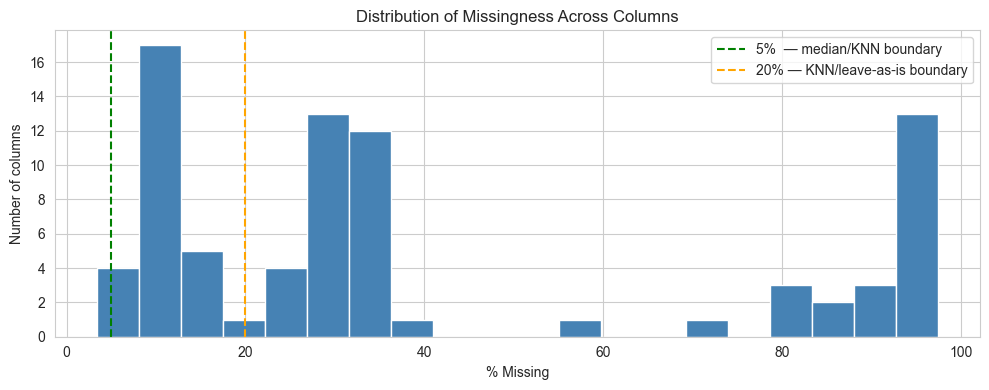

In [345]:
missing = df_useful.isnull().sum()
missing_pct = (missing / len(df_useful)) * 100
missing_sum = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_sum = missing_sum[missing_sum['Missing'] > 0].sort_values('Missing', ascending=False)


# Distribution of missingness across columns
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(missing_sum['Percent'], bins=20, color='steelblue', edgecolor='white')
ax.axvline(5,  color='green',  linestyle='--', label='5%  — median/KNN boundary')
ax.axvline(20, color='orange', linestyle='--', label='20% — KNN/leave-as-is boundary')
ax.set_xlabel('% Missing')
ax.set_ylabel('Number of columns')
ax.set_title('Distribution of Missingness Across Columns')
ax.legend()
plt.tight_layout()
plt.show()

## Removal of Highly Incomplete Parameters

**Objective:** Exclude parameters with excessive missingness (>85%) to preserve data quality.

**Threshold:** Parameters with more than 85% missing values were removed from the dataset.

**Results:**
- **Parameters identified:** 319 parameters exceeded the 85% missing threshold
- **Input shape:** df_useful with original parameter count
- **Output shape:** df_after_cleaning_missing with reduced parameters
- **Updated dictionary:** `parameter_quality` marked excluded parameters with `too_few_data=True` and exclusion reason

**Rationale:** Parameters with >85% missing represent severe data scarcity and violate Piórkowska et al. (2025) missing data preservation principles. Removal prevents unreliable imputation and preserves the integrity of subsequent analysis.

**Outputs:**
- `df_useful_high_missing_removed.csv` – Cleaned dataset
- `excluded_parameters_high_missing.csv` – Exclusion summary with missing percentages